# Lección 14.3 · Metagenómica shotgun (Kraken2)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-14-metagenomica/14.3_metagenomica_shotgun.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 14 — Metagenómica y microbioma** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3.5 horas | Intermedio–avanzado | Lecciones 8.1 ($k$-mers y espectros), 6.3 (cobertura), 14.1 (16S y ASVs) y 14.2 (diversidad alfa y beta) |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Explicar** qué gana y qué pierde la metagenómica *shotgun* frente al amplicón 16S y **calcular** con
   $c = R\,\ell\,\alpha / G$ si un organismo raro tendrá cobertura suficiente para ensamblarse o sólo para detectarse.
2. **Justificar** la longitud de los $k$-mers de Kraken con el número esperado de coincidencias espurias $B\cdot 4^{-k}$.
3. **Asignar** cada $k$-mer al **ancestro común más bajo** (LCA) de los genomas que lo contienen y **clasificar** una
   lectura con la regla del camino raíz-hoja, $\mathrm{RTL}(h) = \sum_{t \in \mathrm{camino}(h)} w_t$.
4. **Aplicar** el umbral de confianza de Kraken 2 y **explicar** por qué almacena minimizadores en lugar de $k$-mers.
5. **Construir desde cero** una base de $k$-mers con LCA a partir de 10 genomas reales de RefSeq y **clasificar**
   lecturas reales de la comunidad simulada **ZymoBIOMICS** (ERR2984773), comparando con la composición esperada.
6. **Corregir** las abundancias con **Bracken** ($P(S_i\mid G)$ por la regla de Bayes), primero con el ejemplo del
   libro y después con nuestras lecturas reales.
7. **Describir** por qué el ensamblaje metagenómico es difícil, **agrupar contigs** (*binning*) por composición
   (GC, tetranucleótidos) y cobertura, y **evaluar** un MAG con completitud, contaminación y las categorías **MIMAG**.
8. **Explicar** la idea del perfilado funcional y del **resistoma**.

## 🗺️ Mapa de la clase

1. La biblioteca triturada: un diagnóstico que no puede esperar
2. Del amplicón al metagenoma: cobertura de los organismos raros (🔍 interactivo)
3. Clasificar lecturas por $k$-mers exactos: ¿qué longitud de $k$?
4. El ancestro común más bajo y la regla raíz-hoja (🎬 animación)
5. Kraken 2: minimizadores y umbral de confianza
6. 🧪 Caso real: nuestra propia «mini-Kraken» contra la comunidad ZymoBIOMICS (🔍 interactivo)
7. De lecturas clasificadas a abundancias: Bracken (🔍 interactivo)
8. Perfilado con genes marcadores: MetaPhlAn
9. Ensamblaje metagenómico
10. *Binning*: agrupar contigs en genomas (🔍 interactivo, 🎬 animación)
11. ¿Es bueno un MAG? CheckM y MIMAG (🔍 interactivo)
12. Más allá de «quién está»: perfilado funcional y resistoma
13. Ejercicios, resumen y lecturas

> 📖 Esta lección acompaña la sección «Metagenómica *shotgun*» del capítulo 14 del libro del curso. Usamos su misma
> notación ($c$, $R$, $\ell$, $\alpha$, $G$, $\kappa$, $\tau(\kappa)$, $w_t$, $\mathrm{RTL}$, $P(S_i\mid G)$, $K_i$, $n_G$,
> $\hat n_i$, $\mathcal{M}$, $c_g$) y sus mismos ejemplos numéricos («Leer el árbol de la figura LCA», «Bracken en
> números», «Clasificar un MAG») y reproducimos exactamente su simulación de *binning*. Cuando citemos una ecuación
> del libro la escribiremos también aquí: el cuaderno se puede leer solo.

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import io, gzip, json, math, time, shutil, subprocess, zlib
import xml.etree.ElementTree as ET
from collections import Counter, defaultdict
import matplotlib as mpl
from matplotlib.patches import FancyBboxPatch, Rectangle, Circle
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_bytes(name, live_url=None, timeout=90):
    """Lee un archivo del curso: 1) copia local ../data; 2) servicio original; 3) copia de respaldo en GitHub."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return open(local, "rb").read()
    for url in [live_url, f"{RAW}/data/{name}"]:
        if url is None:
            continue
        try:
            with urllib.request.urlopen(url, timeout=timeout) as r:
                return r.read()
        except Exception as err:
            print(f"⚠️ No se pudo descargar {url[:75]}… ({err}); pruebo la siguiente fuente")
    raise RuntimeError(f"No se encontró {name}")

# --- Codificación de k-mers en 2 bits (la misma idea de la Lección 8.1) ----------------------------
LUT = np.full(256, 4, dtype=np.uint8)            # tabla ASCII → 0..3 (4 = N u otro símbolo)
for code_, base_ in enumerate(b"ACGT"):
    LUT[base_] = code_
    LUT[base_ + 32] = code_                       # también minúsculas

def encode(seq):
    """Convierte una secuencia (str o bytes) en un arreglo de enteros 0..3 (4 para N)."""
    return LUT[np.frombuffer(seq.encode() if isinstance(seq, str) else seq, dtype=np.uint8)]

def kmer_codes(x, k=31):
    """Códigos enteros (64 bits) de la forma canónica de todos los k-mers de x sin N.
    Cada base ocupa 2 bits; la forma canónica es el menor entre el k-mer y su reverso complementario."""
    n = len(x) - k + 1
    if n <= 0:
        return np.zeros(0, np.uint64)
    bad = np.zeros(len(x) + 1, np.int64)
    bad[1:] = np.cumsum(x == 4)
    ok = (bad[k:] - bad[:-k]) == 0                  # ventanas sin ninguna N
    xx = np.where(x == 4, 0, x).astype(np.uint64)
    fwd = np.zeros(n, np.uint64)
    rev = np.zeros(n, np.uint64)
    for j in range(k):
        fwd |= xx[j:j + n] << np.uint64(2 * (k - 1 - j))
        rev |= (np.uint64(3) - xx[j:j + n]) << np.uint64(2 * j)
    return np.minimum(fwd, rev)[ok]

rng = np.random.default_rng(143)        # semilla fija para los ejemplos pequeños de la clase
print("Utilidades listas · Lección 14.3")

Entorno listo ✔  |  Colab: False
Utilidades listas · Lección 14.3


## 1. La biblioteca triturada: un diagnóstico que no puede esperar

### 1.1 La intuición

Suponga que alguien pasa por una trituradora de papel **todos los libros de una biblioteca de barrio** (novelas,
recetarios, manuales de fontanería y algunos volúmenes únicos que no existen en ninguna otra parte) y le entrega a
usted una bolsa con millones de tiras de papel. Hay dos cosas que puede hacer:

* Si tiene acceso al **catálogo de una gran biblioteca nacional**, puede tomar cada tira, buscar sus palabras en el
  catálogo y anotar de qué libro proviene. Las tiras de los libros que el catálogo no conoce quedarán **sin
  identificar**.
* O bien puede **ignorar el catálogo** y empezar a pegar tiras que se solapan hasta reconstruir páginas, y luego
  agrupar las páginas por el **tipo de letra** y el **color del papel** hasta recomponer libros enteros, incluidos los
  que nadie había catalogado.

La metagenómica *shotgun* hace ambas cosas. La primera es la **clasificación de lecturas** (secciones 3–8); la segunda,
el **ensamblaje y el *binning*** (secciones 9–11). En esta clase las construiremos las dos, desde cero y en pequeño.

### 1.2 Por qué importa hoy: un líquido cefalorraquídeo sin cultivo positivo

Una paciente de 68 años, en tratamiento inmunosupresor, llega a urgencias con fiebre y rigidez de nuca. El cultivo del
líquido cefalorraquídeo (LCR) sale negativo a las 48 horas, quizá porque ya había recibido antibióticos. El servicio de
microbiología decide secuenciar **todo el ADN** del LCR. La pregunta clínica es concreta: ¿hay ***Listeria
monocytogenes***, que obliga a cambiar a ampicilina, o es otra cosa?

La respuesta llegará de un clasificador de lecturas como **Kraken 2**. Pero antes de confiar en él para una paciente,
el laboratorio tiene que **validarlo**: ¿qué fracción de lecturas deja sin clasificar? ¿Confunde *L. monocytogenes*
con su pariente inocuo ***Listeria innocua***? ¿Las abundancias que reporta son fieles? Para eso se usa una
**comunidad simulada** (*mock community*) de composición conocida. Nosotros usaremos lecturas reales de la
**ZymoBIOMICS Microbial Community Standard**: 8 bacterias (entre ellas *L. monocytogenes*, *Escherichia coli*,
*Salmonella enterica* y *Staphylococcus aureus*) y 2 levaduras, mezcladas de forma que cada bacteria aporta el **12 %**
del ADN y cada levadura el **2 %**. Las lecturas son de la corrida Illumina MiSeq **ERR2984773** (Nicholls *et al.*,
2019), de la que tomaremos 15 000.

> 🤔 **Antes de seguir, prediga.** Si nuestro clasificador sólo conoce los genomas de las 8 bacterias (y de dos
> parientes cercanos), ¿qué fracción mínima de las lecturas debería quedar **sin clasificar**? ¿Sería más o menos que
> esa cifra en la práctica? Anote su respuesta; la comprobaremos en la sección 6.

## 2. Del amplicón al metagenoma

### 2.1 Qué ganamos y qué perdemos

En la metagenómica *shotgun* se extrae **todo el ADN** de la muestra, se fragmenta al azar y se secuencia sin ninguna
amplificación dirigida. Frente al 16S de las Lecciones 14.1 y 14.2:

| | Amplicón 16S | *Shotgun* |
|---|---|---|
| Sesgos de cebadores y de número de copias de *rrn* | sí | no |
| Dominios observados | bacterias y arqueas | todos: bacterias, arqueas, hongos, protistas, virus |
| Resolución típica | género | especie y, a menudo, cepa |
| ¿Qué genes hay? (funciones, resistencias) | no | sí |
| Profundidad necesaria | ~$10^4$ lecturas | $10^6$–$10^7$ lecturas |
| ADN del hospedador | no se amplifica | puede ser la mayoría (hay que retirarlo) |

La última fila es crucial en clínica: en un LCR o un hisopo, más del 99 % de las lecturas pueden ser humanas y se
retiran mapeándolas contra el genoma humano **antes** de cualquier análisis.

### 2.2 La cobertura impone un límite duro a los organismos raros

Piense en regar un jardín con un aspersor que lanza gotas al azar: las plantas de una esquina grande reciben mucha
agua; una maceta diminuta en un rincón puede quedar seca aunque el aspersor funcione perfectamente. Con la teoría de
cobertura del capítulo 6 (Lander–Waterman), si secuenciamos $R$ lecturas de longitud $\ell$ y un genoma de tamaño $G$
representa una fracción $\alpha$ del ADN, su cobertura esperada y la probabilidad de que una base quede sin ninguna
lectura son

$$
\boxed{\,c = \frac{R\,\ell\,\alpha}{G}, \qquad \Pr(\text{base no cubierta}) \approx e^{-c}\,}
\qquad \text{(ecuación 14-cov del libro)}
$$

| Símbolo | Significado | Unidades |
|---|---|---|
| $c$ | cobertura media esperada del genoma del organismo | veces (×) |
| $R$ | número de lecturas | lecturas |
| $\ell$ | longitud de cada lectura | pb |
| $\alpha$ | fracción del ADN secuenciado que proviene de ese organismo (abundancia relativa en ADN) | sin unidades |
| $G$ | tamaño del genoma | pb |

**Ejemplo del libro, a mano.** Con $2\times10^7$ pares de lecturas de 150 bases ($R = 4\times10^7$ lecturas) y un
genoma bacteriano de 4 Mb:

* un organismo con el **1 %** del ADN: $c = \dfrac{4\times10^7 \cdot 150 \cdot 0{,}01}{4\times10^6} = 15$, y
  $e^{-15} \approx 3\times10^{-7}$: prácticamente todo su genoma queda cubierto;
* uno con el **0,1 %**: $c = 1{,}5$, y $e^{-1{,}5} = 0{,}22$: **el 22 % de sus bases no recibe ninguna lectura** y su
  ensamblaje será imposible.

Su **presencia**, en cambio, sí puede detectarse clasificando lecturas: el organismo del 0,1 % aporta
$R\,\alpha = 40\,000$ lecturas, y para detectarlo bastan unas pocas docenas.

In [2]:
def coverage(R, ell, alpha, G):
    """Cobertura esperada c = R·ℓ·α / G (ecuación 14-cov del libro)."""
    return R * ell * alpha / G

R_book, ell_book, G_book = 4e7, 150, 4e6
for alpha in (0.01, 0.001):
    c = coverage(R_book, ell_book, alpha, G_book)
    print(f"α = {alpha:>6.3%} → c = {c:5.1f}×   fracción no cubierta e^-c = {math.exp(-c):.2e}   "
          f"lecturas del organismo R·α = {R_book * alpha:,.0f}")

α = 1.000% → c =  15.0×   fracción no cubierta e^-c = 3.06e-07   lecturas del organismo R·α = 400,000
α = 0.100% → c =   1.5×   fracción no cubierta e^-c = 2.23e-01   lecturas del organismo R·α = 40,000


> 🔎 **Qué observamos.** Un factor 10 en abundancia separa «genoma completo» (15×, $3\times10^{-7}$ sin cubrir) de
> «genoma en jirones» (1,5×, 22 % sin cubrir). Pero incluso el organismo del 0,1 % deja **40 000 lecturas**. Detectar
> es mucho más barato que ensamblar: ésa es la razón de ser de la rama de **perfilado** de la metagenómica.

La figura interactiva recorre todo el rango de abundancias. Pase el cursor por las curvas: el cuadro muestra la
cobertura, la fracción del genoma sin cubrir y cuántas lecturas aporta el organismo. Las líneas verticales punteadas
marcan los dos ejemplos del libro.

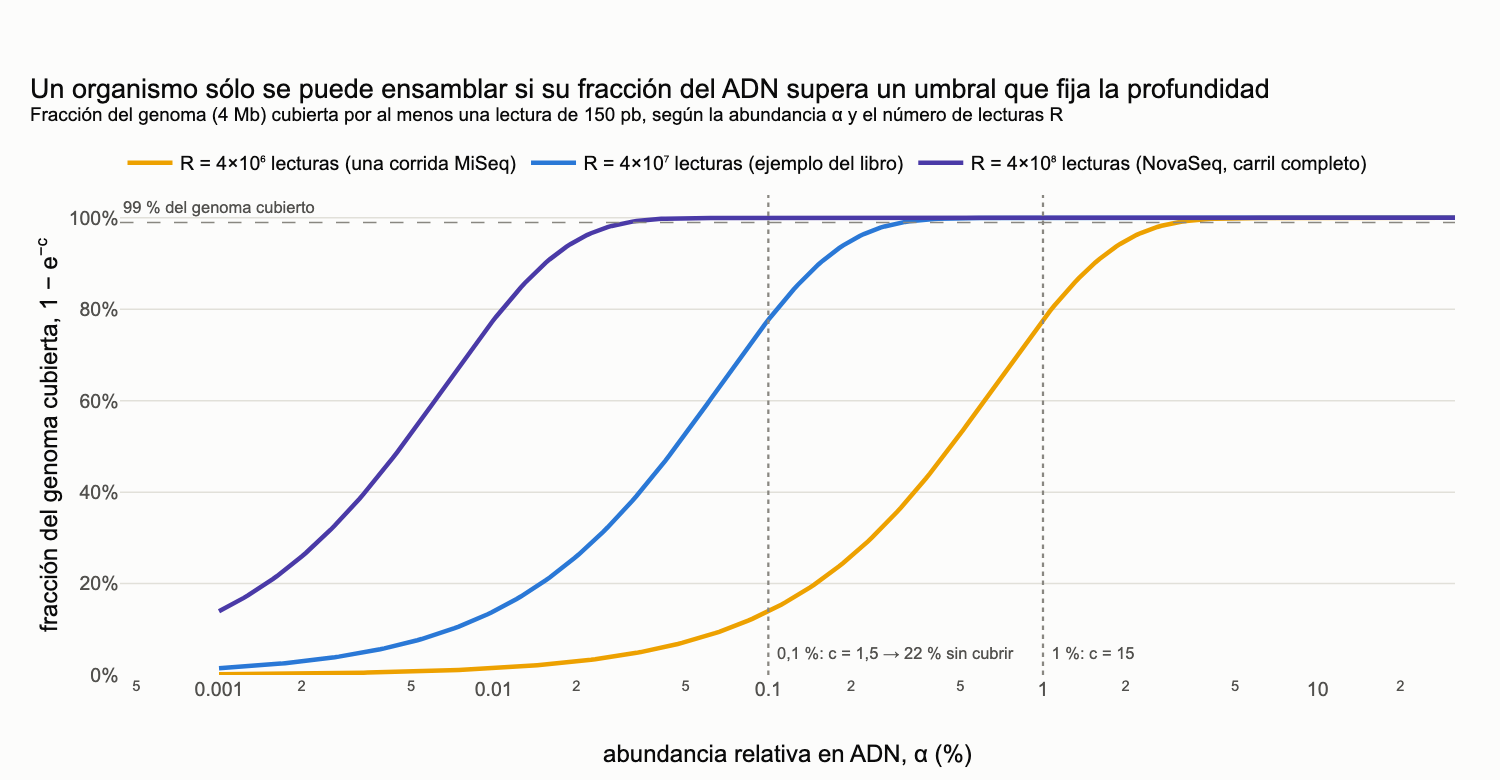

In [3]:
alphas = np.logspace(-5, -0.5, 300)
fig = go.Figure()
for R_, col, lab in [(4e6, ec.CATEGORICAL[3], "R = 4×10⁶ lecturas (una corrida MiSeq)"),
                     (4e7, ec.BLUE, "R = 4×10⁷ lecturas (ejemplo del libro)"),
                     (4e8, ec.CATEGORICAL[6], "R = 4×10⁸ lecturas (NovaSeq, carril completo)")]:
    c = coverage(R_, 150, alphas, 4e6)
    fig.add_trace(go.Scatter(
        x=alphas * 100, y=1 - np.exp(-c), mode="lines", name=lab, line=dict(color=col, width=3),
        customdata=np.c_[c, np.exp(-c) * 100, R_ * alphas],
        hovertemplate=("<b>α = %{x:.3g} % del ADN</b><br>cobertura c = R·ℓ·α/G = %{customdata[0]:.2f}×"
                       "<br>genoma cubierto 1 − e<sup>−c</sup> = %{y:.1%}"
                       "<br>sin cubrir e<sup>−c</sup> = %{customdata[1]:.2g} %"
                       "<br>lecturas del organismo R·α = %{customdata[2]:,.0f}<extra>" + lab.split(" (")[0] + "</extra>")))
for a_, t_ in [(1, "1 %: c = 15"), (0.1, "0,1 %: c = 1,5 → 22 % sin cubrir")]:
    fig.add_vline(x=a_, line=dict(color=ec.MUTED, dash="dot", width=1.5))
    fig.add_annotation(x=math.log10(a_), y=0.05, text=t_, showarrow=False, xanchor="left", xshift=4,
                       font=dict(size=11, color=ec.INK_2))
fig.add_hline(y=0.99, line=dict(color=ec.MUTED, dash="dash", width=1))
fig.add_annotation(x=math.log10(0.001), y=0.99, text="99 % del genoma cubierto", showarrow=False, yshift=10,
                   font=dict(size=11, color=ec.INK_2))
fig.update_layout(
    title="Un organismo sólo se puede ensamblar si su fracción del ADN supera un umbral que fija la profundidad"
          "<br><sup>Fracción del genoma (4 Mb) cubierta por al menos una lectura de 150 pb, según la abundancia α y el número de lecturas R</sup>",
    xaxis=dict(type="log", title="abundancia relativa en ADN, α (%)"),
    yaxis=dict(title="fracción del genoma cubierta, 1 − e<sup>−c</sup>", tickformat=".0%", range=[0, 1.05]),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), height=520, margin=dict(t=130, l=80, r=30, b=70))
fig.show()

> ✅ **Compruebe su comprensión.** En el LCR de nuestra paciente, el 99,5 % de las lecturas es humano y secuenciamos
> $R = 10^7$ lecturas de 150 pb. Si *L. monocytogenes* (2,9 Mb) es el 50 % del ADN **no humano**, ¿qué cobertura
> alcanza? *(Respuesta: $\alpha = 0{,}005 \times 0{,}5 = 0{,}0025$; $c = 10^7 \cdot 150 \cdot 0{,}0025 / 2{,}9\times10^6
> \approx 1{,}3$×. No basta para ensamblar su genoma, pero sus $\approx 25\,000$ lecturas sobran para detectarla.)*

## 3. Clasificar lecturas por $k$-mers exactos

### 3.1 Del alineamiento a la tabla *hash*

La forma más directa de identificar una lectura es **alinearla** contra todos los genomas conocidos con BLAST
(capítulo 3). Con decenas de millones de lecturas y cientos de gigabases de referencia eso es inviable: sería como
buscar cada tira de papel leyendo, uno por uno, todos los libros de la biblioteca nacional.

Wood y Salzberg (2014) propusieron en **Kraken** sustituir el alineamiento por la búsqueda de **$k$-mers exactos**
(capítulo 8) en una base de datos precalculada: cada palabra de $k$ letras de la lectura se busca en una **tabla
*hash***, que responde en tiempo constante «¿dónde aparece esta palabra?». Clasificar una lectura se convierte en una
sucesión de consultas, órdenes de magnitud más rápida que alinear. Es lo que hace un índice alfabético al final de un
libro: no lee el libro, salta directamente a la página.

### 3.2 ¿Qué longitud de $k$? Coincidencias espurias

**Intuición.** Una palabra corta («de») aparece en todos los libros y no dice nada; una frase larga («la biblioteca de
barrio triturada») aparece en uno solo. Con el ADN pasa lo mismo, pero sólo hay 4 letras, así que las palabras tienen
que ser largas.

Si las bases fueran independientes y equiprobables, un $k$-mer concreto aparecería **por azar** en una posición dada
con probabilidad $4^{-k}$, y en una base de referencia de $B$ bases el número esperado de apariciones espurias sería

$$
\mathbb{E}[\text{coincidencias espurias}] \approx B\cdot 4^{-k} \qquad \text{(ecuación 14-kespurio del libro)}
$$

| Símbolo | Significado |
|---|---|
| $B$ | número de bases de la base de datos de referencia (todas las posiciones donde podría aparecer el $k$-mer) |
| $k$ | longitud del $k$-mer |
| $4^{-k}$ | probabilidad de que una posición al azar coincida con un $k$-mer dado |

**A mano**, con $B = 10^{11}$ (una base del tamaño de RefSeq bacteriano): un **15-mer** aparece por azar
$10^{11}/4^{15} = 10^{11}/1{,}07\times10^{9} \approx 93$ veces; un **21-mer**, $0{,}02$ veces; un **31-mer**,
$2\times10^{-8}$ veces. Un 31-mer compartido entre una lectura y un genoma es, casi con seguridad, **evidencia de
ascendencia común**, no casualidad.

### 3.3 El precio de los $k$-mers largos

Pero los $k$-mers largos tienen un precio: **un solo error** de secuenciación, o una sola diferencia entre la cepa de la
muestra y la de referencia, **destruye los $k$ $k$-mers que la contienen**. Si cada base difiere con probabilidad $d$
(error más divergencia de cepa), la fracción de $k$-mers intactos de una lectura es $(1-d)^k$. Kraken usó $k=31$;
Kraken 2 usa por defecto $k=35$.

In [4]:
B_ref = 1e11
for k in (15, 21, 31, 35):
    print(f"k = {k}: 4^-k = {4.0 ** -k:.2e}   coincidencias espurias esperadas en B = 10^11: {B_ref * 4.0 ** -k:.2e}")

# Un solo cambio en la mitad de una lectura destruye k de sus k-mers
read_demo = "".join(rng.choice(list("ACGT"), 150))
mut = read_demo[:75] + ("A" if read_demo[75] != "A" else "C") + read_demo[76:]
a_, b_ = kmer_codes(encode(read_demo)), kmer_codes(encode(mut))
print(f"\nLectura de 150 pb: {len(a_)} 31-mers. Tras UNA sustitución en la posición 75: "
      f"{np.sum(a_ != b_)} 31-mers distintos (los que contienen esa posición).")

k = 15: 4^-k = 9.31e-10   coincidencias espurias esperadas en B = 10^11: 9.31e+01
k = 21: 4^-k = 2.27e-13   coincidencias espurias esperadas en B = 10^11: 2.27e-02
k = 31: 4^-k = 2.17e-19   coincidencias espurias esperadas en B = 10^11: 2.17e-08
k = 35: 4^-k = 8.47e-22   coincidencias espurias esperadas en B = 10^11: 8.47e-11

Lectura de 150 pb: 120 31-mers. Tras UNA sustitución en la posición 75: 31 31-mers distintos (los que contienen esa posición).


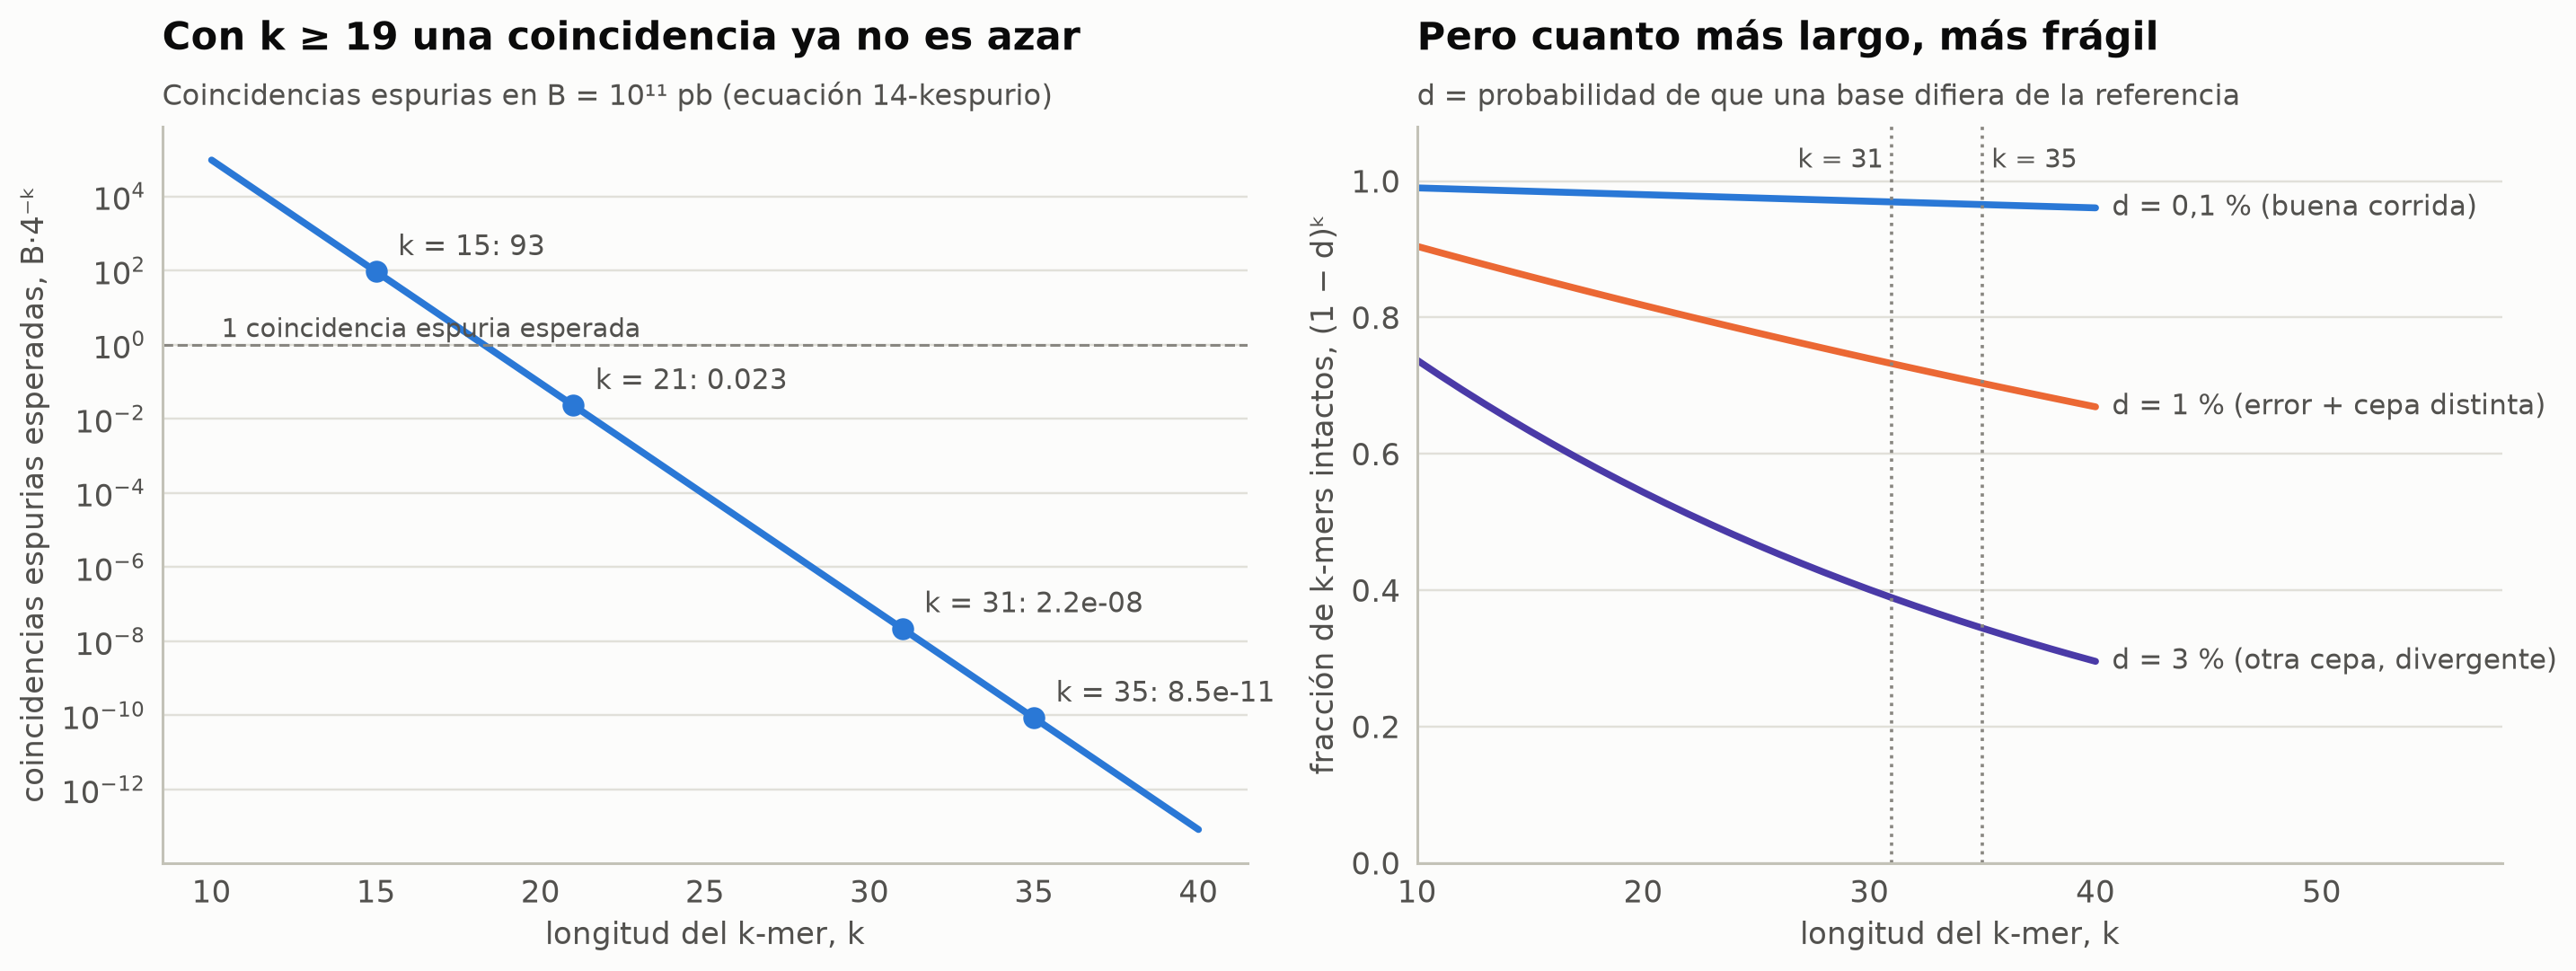

In [5]:
ks = np.arange(10, 41)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))
ax1.semilogy(ks, B_ref * 4.0 ** -ks, color=ec.BLUE, lw=2.5)
for k in (15, 21, 31, 35):
    v = B_ref * 4.0 ** -k
    ax1.plot(k, v, "o", color=ec.BLUE, ms=7)
    ax1.annotate(f"k = {k}: {v:.2g}", (k, v), xytext=(8, 6), textcoords="offset points", fontsize=10, color=ec.INK_2)
ax1.axhline(1, color=ec.MUTED, ls="--", lw=1)
ax1.text(10.3, 1.6, "1 coincidencia espuria esperada", color=ec.INK_2, fontsize=9.5)
ax1.set_xlabel("longitud del k-mer, k"); ax1.set_ylabel("coincidencias espurias esperadas, B·4⁻ᵏ")
ec.title(ax1, "Con k ≥ 19 una coincidencia ya no es azar",
         "Coincidencias espurias en B = 10¹¹ pb (ecuación 14-kespurio)")
for d, col, lab in [(0.001, ec.BLUE, "d = 0,1 % (buena corrida)"), (0.01, ec.ORANGE, "d = 1 % (error + cepa distinta)"),
                    (0.03, ec.CATEGORICAL[6], "d = 3 % (otra cepa, divergente)")]:
    ax2.plot(ks, (1 - d) ** ks, color=col, lw=2.5)
    ec.label_end(ax2, ks[-1], (1 - d) ** ks[-1], lab)
for k in (31, 35):
    ax2.axvline(k, color=ec.MUTED, ls=":", lw=1.2)
    ax2.text(k + (-0.4 if k == 31 else 0.4), 1.02, f"k = {k}", ha="right" if k == 31 else "left", fontsize=9.5,
             color=ec.INK_2)
ax2.set_xlim(10, 55); ax2.set_ylim(0, 1.08)
ax2.set_xlabel("longitud del k-mer, k"); ax2.set_ylabel("fracción de k-mers intactos, (1 − d)ᵏ")
ax2.set_xlim(10, 58)
ec.title(ax2, "Pero cuanto más largo, más frágil",
         "d = probabilidad de que una base difiera de la referencia")
plt.show()

> 🔎 **Qué observamos.** A la izquierda, cada letra adicional divide por 4 el número de coincidencias por azar: entre
> $k=15$ (93 espurias) y $k=31$ ($2\times10^{-8}$) hay 16 órdenes de magnitud. A la derecha, el precio: con una cepa que
> difiere un 3 % de la de referencia, sólo el $0{,}97^{31} \approx 39\,\%$ de los 31-mers sobrevive. Kraken elige $k$
> donde la especificidad ya es total y la sensibilidad aún es aceptable. Veremos este precio en los datos reales: las
> cepas de la comunidad Zymo **no son** las cepas de RefSeq.

> ✅ **Compruebe su comprensión.** ¿Por qué el número de $k$-mers destruidos por una sola sustitución es exactamente
> $k$ si ocurre lejos de los extremos? *(Porque la posición alterada está contenida en las ventanas que empiezan en las
> $k$ posiciones anteriores, incluida ella misma; cerca de un extremo, son menos.)*

## 4. El ancestro común más bajo

### 4.1 Muchos $k$-mers no son exclusivos de un genoma

Un 31-mer de un gen ribosómico puede estar en todos los miembros de una familia. ¿A quién se lo atribuimos? Kraken
resuelve la ambigüedad **al construir la base**, no al consultarla: a cada $k$-mer le pega la etiqueta más específica
que se puede justificar. Es como el sello de un libro de una biblioteca con varias sedes: si el mismo libro está en
las sedes norte y sur, el catálogo no dice «sede norte», dice «red de bibliotecas de la ciudad».

> **Definición (ancestro común más bajo, LCA).** Dado un conjunto de taxones $T$ en un árbol taxonómico, su ancestro
> común más bajo, $\mathrm{LCA}(T)$, es el nodo más profundo del árbol del que descienden todos los elementos de $T$.
> En la base de Kraken, cada $k$-mer $\kappa$ se asocia a
> $$\tau(\kappa) = \mathrm{LCA}\{\text{taxones cuyos genomas contienen } \kappa\}.$$

* Un $k$-mer presente sólo en *Escherichia coli* apunta a la **especie**.
* Uno presente en *E. coli* y en *Shigella flexneri* apunta a la **familia** *Enterobacteriaceae* (son géneros
  distintos de la misma familia).
* Uno presente en toda bacteria apunta al **dominio**.

### 4.2 La regla de clasificación: el camino raíz-hoja

Para clasificar una lectura, Kraken consulta todos sus $k$-mers y construye el **árbol de clasificación**: el subárbol
formado por los taxones $\tau(\kappa)$ encontrados y sus ancestros, con un **peso** $w_t$ igual al número de $k$-mers
de la lectura asignados a cada nodo $t$.

> **Regla de clasificación de Kraken (teorema 14-rtl del libro).** Para cada hoja $h$ del árbol de clasificación, sea
> $\mathrm{camino}(h)$ el conjunto de nodos desde la raíz hasta $h$, y
> $$\mathrm{RTL}(h) = \sum_{t\,\in\,\mathrm{camino}(h)} w_t .$$
> La lectura se asigna a la hoja de máxima puntuación $\mathrm{RTL}$; si varias empatan, se asigna al LCA de las hojas
> empatadas. Si ningún $k$-mer se encuentra en la base, la lectura queda sin clasificar.

| Símbolo | Significado |
|---|---|
| $\kappa$ | un $k$-mer de la lectura |
| $\tau(\kappa)$ | taxón asociado a $\kappa$ en la base: el LCA de los genomas que lo contienen |
| $w_t$ | número de $k$-mers de la lectura cuyo LCA en la base es el taxón $t$ |
| $\mathrm{camino}(h)$ | nodos de la raíz a la hoja $h$, ambos incluidos |
| $\mathrm{RTL}(h)$ | puntuación del camino de la raíz a la hoja (*root-to-leaf*): todos los $k$-mers compatibles con que la lectura provenga de $h$ |

La lógica es la de una votación: un $k$-mer asignado a la familia es compatible con cualquier especie de la familia,
así que **vota por todos los caminos que pasan por ella**; un $k$-mer asignado a una especie sólo vota por esa
especie. **El camino ganador es el que explica más $k$-mers de la lectura.**

### 4.3 Ejemplo del libro: «Leer el árbol de la figura LCA»

Una lectura de 150 pb tiene $150 - 35 + 1 = 116$ $k$-mers ($k = 35$). De ellos, **36 no aparecen** en la base (quizá la
cepa de la muestra difiere de las de referencia) y **80 sí**, repartidos así en el árbol:

| nodo | raíz | Bacteria | *Enterobacteriaceae* | *Escherichia* | *Shigella* | *Salmonella* | *E. coli* | *E. albertii* | *S. flexneri* | *S. enterica* |
|---|---|---|---|---|---|---|---|---|---|---|
| $w_t$ | 2 | 3 | 10 | 12 | 1 | 0 | 40 | 4 | 6 | 2 |

Las puntuaciones de los cuatro caminos son

$$
\begin{aligned}
\mathrm{RTL}(\textit{E. coli}) &= 2+3+10+12+40 = \mathbf{67}, &\quad
\mathrm{RTL}(\textit{E. albertii}) &= 2+3+10+12+4 = 31,\\
\mathrm{RTL}(\textit{S. flexneri}) &= 2+3+10+1+6 = 22, &\quad
\mathrm{RTL}(\textit{S. enterica}) &= 2+3+10+0+2 = 17.
\end{aligned}
$$

La lectura se asigna a ***E. coli***. Observe que los 6 $k$-mers exclusivos de *S. flexneri* **no bastan** para cambiar
la decisión: en bacterias con mucha transferencia horizontal, que una lectura contenga algunos $k$-mers de otra
especie es lo esperable. Programemos la regla y comprobemos las cuatro cifras.

In [6]:
# Árbol del ejemplo del libro: hijo → padre
book_parent = {"raíz": None, "Bacteria": "raíz", "Enterobacteriaceae": "Bacteria",
               "Escherichia": "Enterobacteriaceae", "Shigella": "Enterobacteriaceae", "Salmonella": "Enterobacteriaceae",
               "E. coli": "Escherichia", "E. albertii": "Escherichia", "S. flexneri": "Shigella", "S. enterica": "Salmonella"}
book_w = {"raíz": 2, "Bacteria": 3, "Enterobacteriaceae": 10, "Escherichia": 12, "Shigella": 1, "Salmonella": 0,
          "E. coli": 40, "E. albertii": 4, "S. flexneri": 6, "S. enterica": 2}
N_KMERS_BOOK = 150 - 35 + 1

def lineage(t, parent):
    """camino(t): lista de nodos de la raíz a t."""
    out = [t]
    while parent[out[-1]] is not None:
        out.append(parent[out[-1]])
    return out[::-1]

def lca_of(taxa, parent):
    """Ancestro común más bajo de un conjunto de taxones."""
    paths = [lineage(t, parent) for t in taxa]
    best = paths[0][0]
    for level in zip(*paths):
        if len(set(level)) > 1:
            break
        best = level[0]
    return best

def rtl_classify(w, parent):
    """Regla de Kraken: hoja de máxima RTL; empate → LCA de las hojas empatadas. Devuelve (asignación, RTL)."""
    nodes = [t for t, v in w.items() if v > 0] or list(w)
    if not nodes:
        return None, {}
    anc = {a for t in nodes for a in lineage(t, parent)[:-1]}
    leaves = [t for t in nodes if t not in anc]            # hojas del árbol de clasificación
    scores = {h: sum(w.get(t, 0) for t in lineage(h, parent)) for h in leaves}
    best = max(scores.values())
    return lca_of([h for h in leaves if scores[h] == best], parent), scores

# Las cuatro especies son las hojas del árbol del libro (S. enterica tiene w = 2 > 0)
call, scores = rtl_classify(book_w, book_parent)
print(f"k-mers: {N_KMERS_BOOK} · con coincidencia: {sum(book_w.values())} · sin coincidencia: {N_KMERS_BOOK - sum(book_w.values())}")
for h, s in sorted(scores.items(), key=lambda x: -x[1]):
    print(f"RTL({h:12s}) = {' + '.join(str(book_w[t]) for t in lineage(h, book_parent))} = {s}")
print("→ lectura asignada a:", call)

k-mers: 116 · con coincidencia: 80 · sin coincidencia: 36
RTL(E. coli     ) = 2 + 3 + 10 + 12 + 40 = 67
RTL(E. albertii ) = 2 + 3 + 10 + 12 + 4 = 31
RTL(S. flexneri ) = 2 + 3 + 10 + 1 + 6 = 22
RTL(S. enterica ) = 2 + 3 + 10 + 0 + 2 = 17
→ lectura asignada a: E. coli


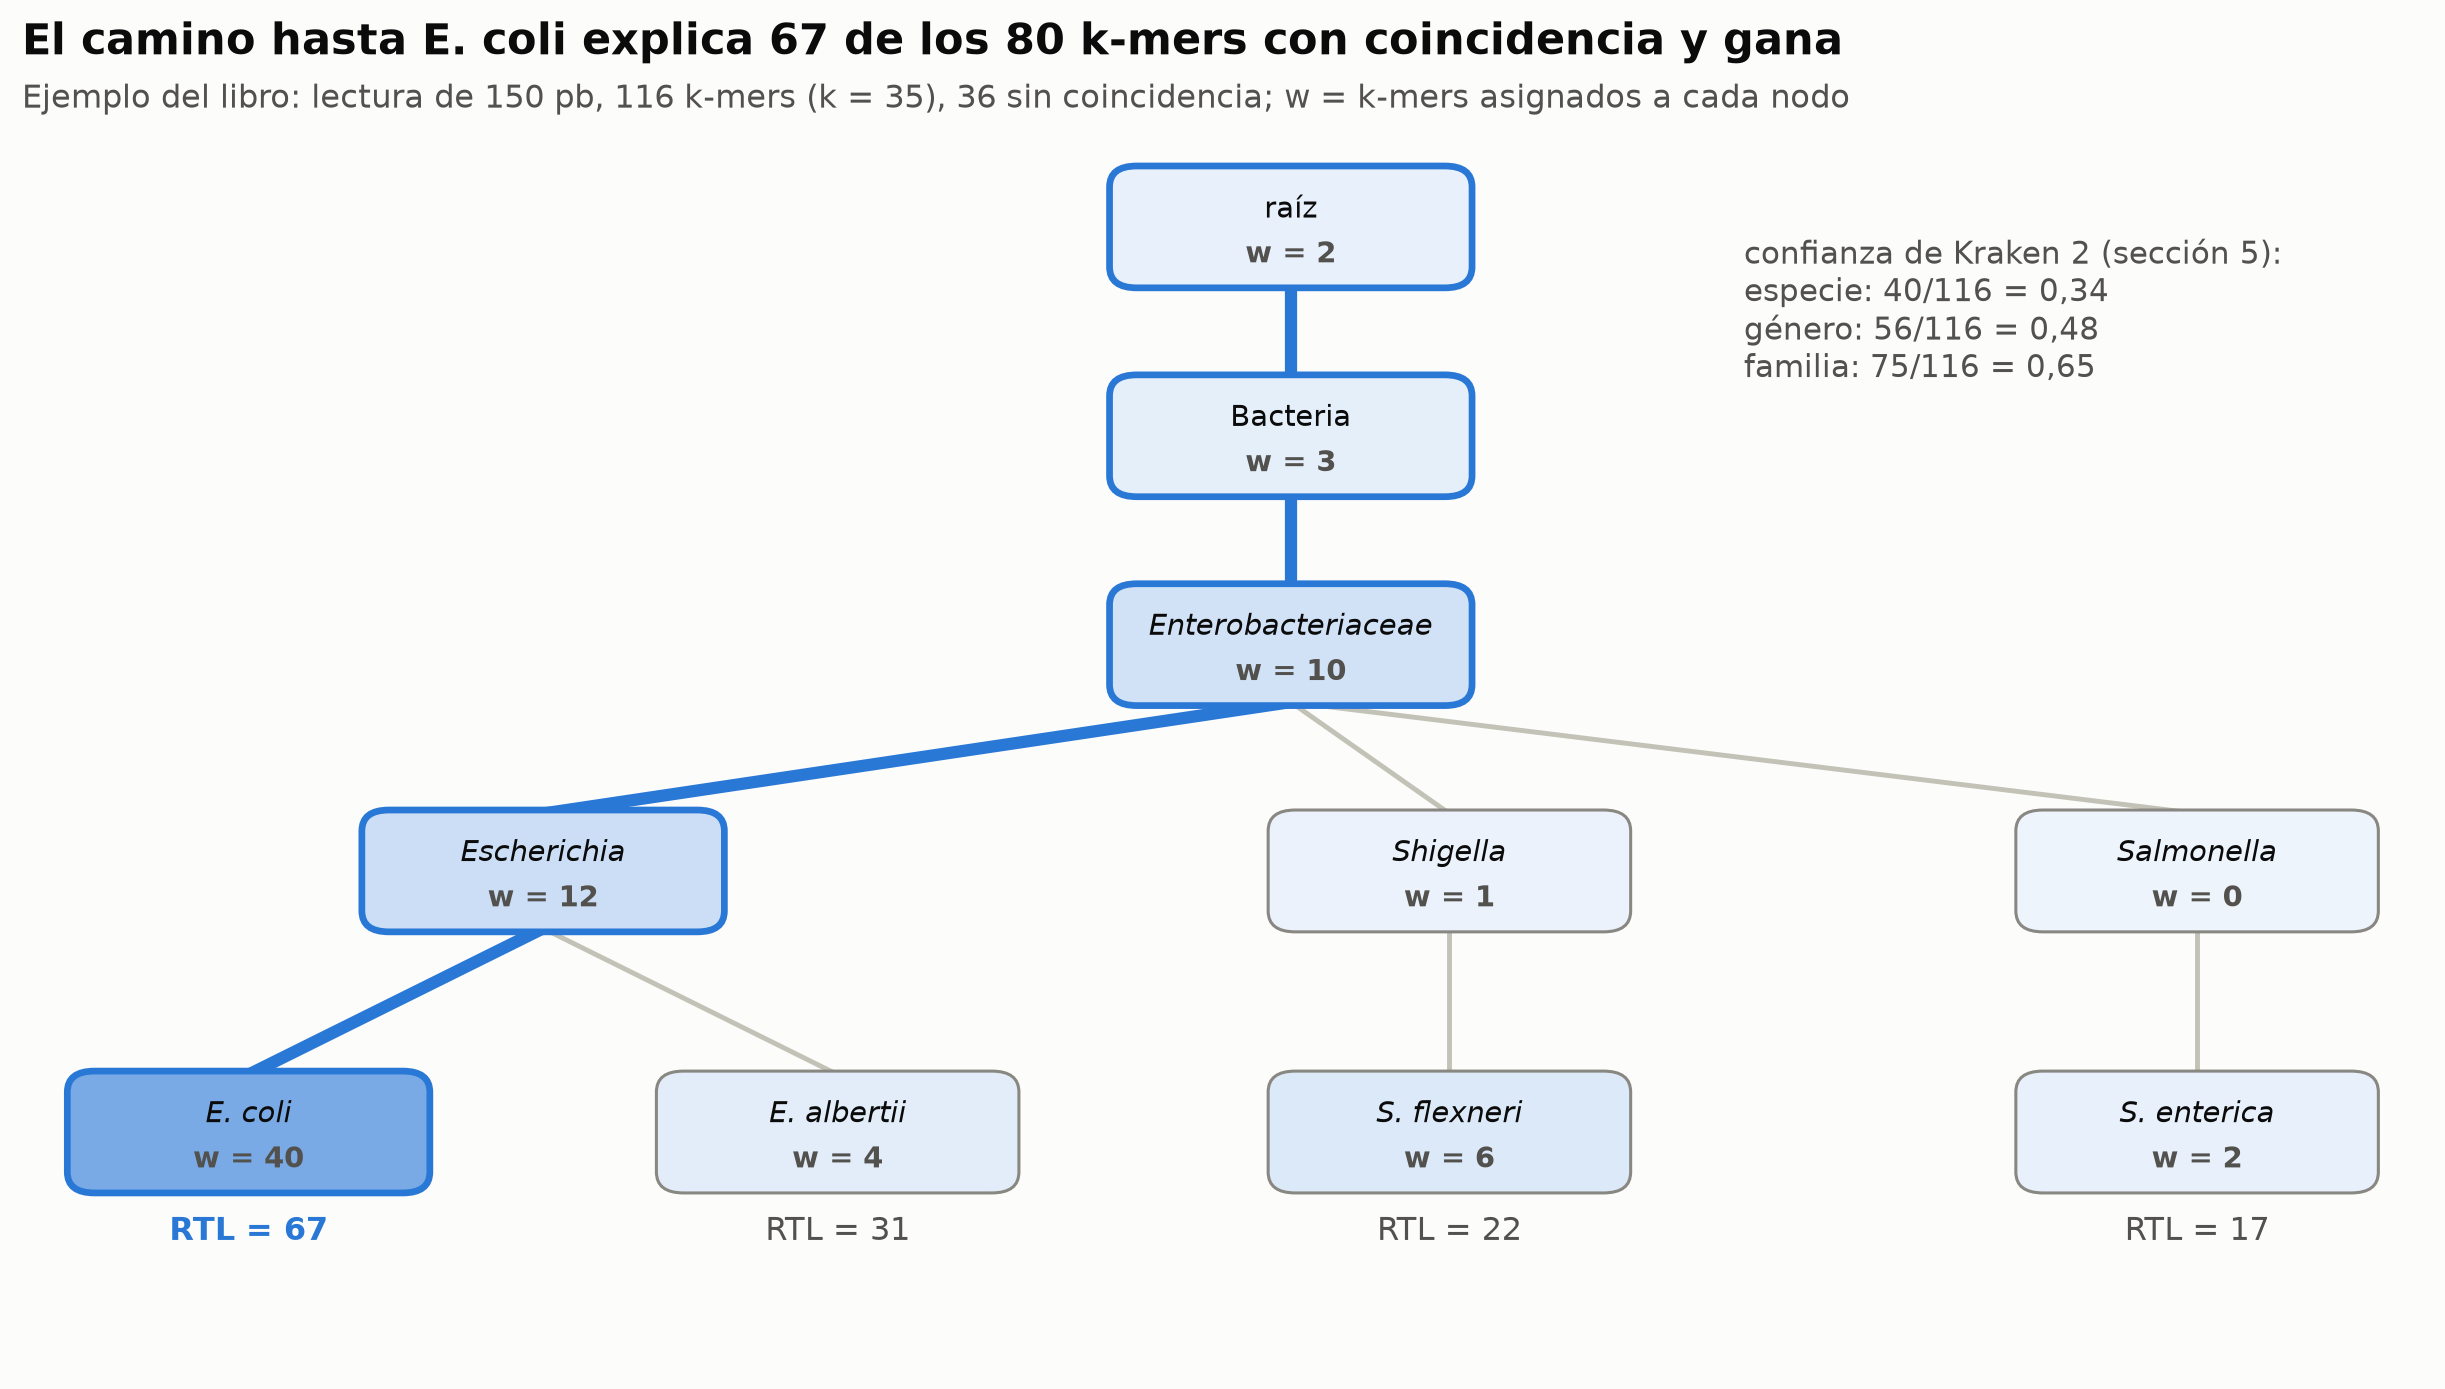

In [7]:
# Figura del árbol del libro con los pesos y las puntuaciones RTL
pos = {"raíz": (5.2, 5.6), "Bacteria": (5.2, 4.4), "Enterobacteriaceae": (5.2, 3.2),
       "Escherichia": (1.9, 1.9), "Shigella": (5.9, 1.9), "Salmonella": (9.2, 1.9),
       "E. coli": (0.6, 0.4), "E. albertii": (3.2, 0.4), "S. flexneri": (5.9, 0.4), "S. enterica": (9.2, 0.4)}
ITALIC = {"Enterobacteriaceae", "Escherichia", "Shigella", "Salmonella", "E. coli", "E. albertii", "S. flexneri", "S. enterica"}
win_path = set(lineage("E. coli", book_parent))

def draw_tree(ax, w, highlight=(), rtl=None, maxw=40):
    """Dibuja el árbol del libro: nodos con su peso w_t y (opcional) la RTL bajo cada hoja."""
    for ch, pa in book_parent.items():
        if pa is None:
            continue
        on = ch in highlight and pa in highlight
        (x0, y0), (x1, y1) = pos[pa], pos[ch]
        ax.plot([x0, x1], [y0 - 0.33, y1 + 0.33], color=ec.BLUE if on else ec.BASELINE, lw=4 if on else 1.6, zorder=1,
                solid_capstyle="round")
    for t, (x, y) in pos.items():
        v = w.get(t, 0)
        a_ = 0.08 + 0.55 * min(v, maxw) / maxw                     # color opaco: mezcla de azul y blanco
        face = tuple(a_ * np.array(mpl.colors.to_rgb(ec.BLUE)) + (1 - a_) * np.ones(3))
        ax.add_patch(FancyBboxPatch((x - 0.78, y - 0.33), 1.56, 0.66, boxstyle="round,pad=0.02,rounding_size=0.12",
                                    fc=face, ec=ec.BLUE if t in highlight else ec.MUTED,
                                    lw=2.2 if t in highlight else 1, zorder=2))
        ax.text(x, y + 0.1, t, ha="center", va="center", fontsize=9.5, zorder=3,
                style="italic" if t in ITALIC else "normal", color=ec.INK)
        ax.text(x, y - 0.16, f"w = {v}", ha="center", va="center", fontsize=9.5, zorder=3, color=ec.INK_2,
                fontweight="bold")
    if rtl:
        for h, s in rtl.items():
            x, y = pos[h]
            best = s == max(rtl.values())
            ax.text(x, y - 0.62, f"RTL = {s}", ha="center", fontsize=10.5, fontweight="bold" if best else "normal",
                    color=ec.BLUE if best else ec.INK_2)
    ax.set_xlim(-0.4, 10.2); ax.set_ylim(-0.95, 6.1); ax.axis("off")

fig, ax = plt.subplots(figsize=(11, 6.2))
draw_tree(ax, book_w, highlight=win_path, rtl=scores)
ax.text(7.2, 5.55, "confianza de Kraken 2 (sección 5):\nespecie: 40/116 = 0,34\ngénero: 56/116 = 0,48\nfamilia: 75/116 = 0,65",
        fontsize=10, color=ec.INK_2, va="top",
        bbox=dict(boxstyle="round,pad=0.4", fc=ec.SURFACE, ec=ec.GRID))
ec.title(ax, "El camino hasta E. coli explica 67 de los 80 k-mers con coincidencia y gana",
         "Ejemplo del libro: lectura de 150 pb, 116 k-mers (k = 35), 36 sin coincidencia; w = k-mers asignados a cada nodo")
plt.show()

> 🔎 **Qué observamos.** El sombreado de cada caja es proporcional a $w_t$. El camino ganador (azul) no sólo suma los
> 40 votos de la especie: también recoge los 27 votos «genéricos» de la raíz, Bacteria, la familia y el género, que son
> compatibles con *E. coli* y con cualquier otra hoja por debajo de ellos. Por eso la diferencia entre caminos la
> deciden sólo los nodos **por debajo** del punto donde se separan: $12+40 = 52$ frente a $12+4 = 16$ dentro de
> *Escherichia*.

La animación siguiente reconstruye el mismo cálculo como lo haría Kraken: los 116 $k$-mers de la lectura se consultan
de izquierda a derecha; cada uno que tiene coincidencia **vota** por su nodo $\tau(\kappa)$ (sube $w_t$) y las cuatro
puntuaciones RTL se actualizan en vivo.

![Los 116 k-mers de una lectura se consultan uno a uno: los grises no están en la base y los coloreados votan por su LCA; las puntuaciones RTL crecen hasta 67 (E. coli), 31, 22 y 17](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-14-metagenomica/14.3_kmers_votan.gif)

*Los 116 k-mers de una lectura se consultan uno a uno: los grises no están en la base y los coloreados votan por su LCA; las puntuaciones RTL crecen hasta 67 (E. coli), 31, 22 y 17*

In [8]:
# Orden de los 116 k-mers: 36 sin coincidencia y 80 repartidos según los pesos del libro (orden fijo al azar)
labels = ["—"] * (N_KMERS_BOOK - sum(book_w.values())) + [t for t, v in book_w.items() for _ in range(v)]
rng_anim = np.random.default_rng(1435)
labels = list(rng_anim.permutation(labels))
node_col = {t: ec.BLUE if t in win_path else ec.ORANGE for t in book_parent}
leaves_book = ["E. coli", "E. albertii", "S. flexneri", "S. enterica"]
leaf_col = dict(zip(leaves_book, [ec.BLUE, ec.CATEGORICAL[2], ec.ORANGE, ec.CATEGORICAL[4]]))
PER = 3                                               # k-mers consultados por cuadro
n_steps = math.ceil(N_KMERS_BOOK / PER)

fig = plt.figure(figsize=(13, 6.6))
axT = fig.add_axes([0.01, 0.02, 0.62, 0.78])
axK = fig.add_axes([0.03, 0.86, 0.94, 0.07])
axR = fig.add_axes([0.71, 0.10, 0.26, 0.62])

def update(f):
    for a in (axT, axK, axR):
        a.clear()
    n = min((f + 1) * PER, N_KMERS_BOOK)
    w_now = Counter(l for l in labels[:n] if l != "—")
    for i, l in enumerate(labels):
        col = ec.GRID if i >= n else (ec.MUTED if l == "—" else node_col[l])
        alpha = 0.35 if (i < n and l == "—") else 1
        axK.add_patch(Rectangle((i, 0), 0.85, 1, fc=col, alpha=alpha, lw=0))
    if n < N_KMERS_BOOK:
        axK.add_patch(Rectangle((n - PER, -0.25), PER, 1.5, fill=False, ec=ec.INK, lw=1.8))
    axK.set_xlim(0, N_KMERS_BOOK); axK.set_ylim(-0.3, 1.3); axK.axis("off")
    axK.text(0, 1.55, f"k-mers consultados: {n} de {N_KMERS_BOOK}   ·   con coincidencia: {sum(w_now.values())}   ·   "
             f"sin coincidencia (gris): {n - sum(w_now.values())}", fontsize=11, color=ec.INK)
    sc = {h: sum(w_now.get(t, 0) for t in lineage(h, book_parent)) for h in leaves_book}
    done = n >= N_KMERS_BOOK
    draw_tree(axT, w_now, highlight=win_path if done else (), rtl=sc)
    y = np.arange(len(leaves_book))[::-1]
    axR.barh(y, [sc[h] for h in leaves_book], color=[leaf_col[h] for h in leaves_book], height=0.6)
    for yy, h in zip(y, leaves_book):
        axR.text(sc[h] + 1, yy, str(sc[h]), va="center", fontsize=11, fontweight="bold" if (done and h == "E. coli") else "normal")
    axR.set_yticks(y, leaves_book, fontstyle="italic"); axR.set_xlim(0, 80)
    axR.set_xlabel("RTL(h) = Σ w_t en el camino")
    axR.set_title("Puntuación de cada camino" + ("\n→ gana E. coli" if done else ""), loc="left", fontsize=12)
    return []

ec.animate(fig, update, frames=n_steps + 6, interval=280, name="14.3_kmers_votan")

/Users/juvenalyosa/bioinformatics/modulo-14-metagenomica/../utils/estilo_curso.py:228: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  anim.save(os.path.join(assets, f"{name}.gif"),
/Users/juvenalyosa/bioinformatics/modulo-14-metagenomica/../utils/estilo_curso.py:228: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  anim.save(os.path.join(assets, f"{name}.gif"),


/Users/juvenalyosa/bioinformatics/modulo-14-metagenomica/../utils/estilo_curso.py:228: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  anim.save(os.path.join(assets, f"{name}.gif"),
/Users/juvenalyosa/bioinformatics/modulo-14-metagenomica/../utils/estilo_curso.py:228: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  anim.save(os.path.join(assets, f"{name}.gif"),


/Users/juvenalyosa/bioinformatics/modulo-14-metagenomica/../utils/estilo_curso.py:228: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  anim.save(os.path.join(assets, f"{name}.gif"),
/Users/juvenalyosa/bioinformatics/modulo-14-metagenomica/../utils/estilo_curso.py:228: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  anim.save(os.path.join(assets, f"{name}.gif"),


/Users/juvenalyosa/bioinformatics/modulo-14-metagenomica/../utils/estilo_curso.py:228: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  anim.save(os.path.join(assets, f"{name}.gif"),


/Users/juvenalyosa/bioinformatics/modulo-14-metagenomica/../utils/estilo_curso.py:228: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  anim.save(os.path.join(assets, f"{name}.gif"),
/Users/juvenalyosa/bioinformatics/modulo-14-metagenomica/../utils/estilo_curso.py:228: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  anim.save(os.path.join(assets, f"{name}.gif"),


...

/Users/juvenalyosa/bioinformatics/modulo-14-metagenomica/../utils/estilo_curso.py:231: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  html = HTML(anim.to_jshtml(default_mode="once"))


/Users/juvenalyosa/bioinformatics/modulo-14-metagenomica/../utils/estilo_curso.py:231: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  html = HTML(anim.to_jshtml(default_mode="once"))
/Users/juvenalyosa/bioinformatics/modulo-14-metagenomica/../utils/estilo_curso.py:231: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  html = HTML(anim.to_jshtml(default_mode="once"))


/Users/juvenalyosa/bioinformatics/modulo-14-metagenomica/../utils/estilo_curso.py:231: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  html = HTML(anim.to_jshtml(default_mode="once"))
/Users/juvenalyosa/bioinformatics/modulo-14-metagenomica/../utils/estilo_curso.py:231: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  html = HTML(anim.to_jshtml(default_mode="once"))


/Users/juvenalyosa/bioinformatics/modulo-14-metagenomica/../utils/estilo_curso.py:231: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  html = HTML(anim.to_jshtml(default_mode="once"))


▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Al principio, cuando sólo se han consultado unos pocos $k$-mers, los caminos van casi
> empatados: todos comparten los votos de la raíz, Bacteria y la familia. A medida que llegan los votos exclusivos de
> *E. coli*, su barra se despega. Los 36 $k$-mers grises no votan por nadie: no restan, simplemente no aportan.

> ✅ **Compruebe su comprensión.** ¿Qué pasaría si los 40 $k$-mers de *E. coli* fueran en realidad 4, y los de
> *E. albertii* 40? *(Se intercambian las puntuaciones: RTL(E. albertii) = 67 y la lectura iría a E. albertii. La regla
> es simétrica: sólo cuentan los votos, no el nombre del nodo.)* ¿Y si ambos tuvieran 22? *(Empate a 49: la lectura
> se asigna al LCA de las dos hojas, el género* Escherichia*.)*

## 5. Kraken 2: minimizadores y confianza

### 5.1 Minimizadores: guardar menos sin perder casi nada

La base original de Kraken almacenaba **todos** los 31-mers con su LCA, lo que con las bases actuales exigía cientos
de gigabytes de memoria. Wood, Lu y Langmead (2019) rediseñaron el sistema en Kraken 2 con dos ideas:

1. **Minimizadores.** De cada $k$-mer se guarda sólo su subcadena de longitud $\ell < k$ ($\ell = 31$ por defecto;
   *aquí $\ell$ no es la longitud de la lectura*) de **menor valor** según un orden pseudoaleatorio (un *hash*). Como
   $k$-mers consecutivos comparten casi todas sus subcadenas, suelen compartir minimizador, y el número de entradas cae
   drásticamente. Es como resumir cada párrafo de un libro por su palabra «más rara»: párrafos vecinos que se solapan
   suelen tener la misma.
2. Una **tabla *hash* compacta y probabilística** que guarda sólo unos bits del *hash* junto con el LCA: a cambio de
   una pequeña tasa de falsas coincidencias, la memoria se reduce a una fracción y la velocidad aumenta.

Veámoslo con 200 kb reales del genoma de *E. coli* K-12 (NC_000913.3), con $k = 35$ y $\ell = 31$: cada 35-mer contiene
$k-\ell+1 = 5$ subcadenas de 31 letras y se representa por la de menor *hash*.

In [9]:
ecoli_raw = gzip.decompress(course_bytes("NC_000913.3.fasta.gz",
    "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&id=NC_000913.3&rettype=fasta&retmode=text"))
if ecoli_raw[:2] == b"\x1f\x8b":
    ecoli_raw = gzip.decompress(ecoli_raw)
ecoli_seq = encode(ecoli_raw.split(b"\n", 1)[1].replace(b"\n", b""))
seg = ecoli_seq[1_000_000:1_200_000]

k_big, ell_min = 35, 31
lmers = kmer_codes(seg, ell_min)                                      # 31-mers canónicos
h = (lmers * np.uint64(0x9E3779B97F4A7C15)) ^ np.uint64(0xE37E28C4271B5A2D)   # orden pseudoaleatorio (hash)
wdw = k_big - ell_min + 1
minpos = np.lib.stride_tricks.sliding_window_view(h, wdw).argmin(axis=1) + np.arange(len(h) - wdw + 1)
minimizers = lmers[minpos]                                            # minimizador de cada 35-mer
n_k35 = len(np.unique(kmer_codes(seg, k_big)))
n_min = len(np.unique(minimizers))
print(f"35-mers distintos en 200 kb: {n_k35:,}")
print(f"minimizadores distintos (ℓ = 31): {n_min:,}  → se guardan {n_min / n_k35:.1%} de las entradas "
      f"(densidad teórica 2/(k−ℓ+2) = {2 / (k_big - ell_min + 2):.1%})")
changes = np.flatnonzero(np.diff(minpos) != 0)
print(f"35-mers consecutivos que comparten minimizador: {1 - len(changes) / (len(minpos) - 1):.1%}")

35-mers distintos en 200 kb: 199,599
minimizadores distintos (ℓ = 31): 66,466  → se guardan 33.3% de las entradas (densidad teórica 2/(k−ℓ+2) = 33.3%)
35-mers consecutivos que comparten minimizador: 66.7%


> 🔎 **Qué observamos.** Con una ventana de sólo 5 subcadenas, la base guarda alrededor de un tercio de las entradas
> (la densidad esperada de minimizadores al azar es $2/(w+1)$ con $w = k-\ell+1$). Con los valores reales de Kraken 2
> la reducción se combina con la tabla compacta, y el conjunto rebaja la memoria a una fracción de la de Kraken 1. El
> clasificador no pierde casi nada: dos 35-mers consecutivos de la lectura tienen el mismo minimizador en más de la mitad
> de los casos, así que consultar minimizadores equivale casi a consultar $k$-mers.

### 5.2 El umbral de confianza

Kraken 2 añade un **umbral de confianza**. Para un nodo candidato $t$, la puntuación de confianza es la fracción de los
$k$-mers de la lectura que caen en el **subárbol** de $t$ (el propio $t$ y todos sus descendientes):

$$
\mathrm{conf}(t) = \frac{\#\{\kappa \text{ de la lectura}: \tau(\kappa) \in \mathrm{subárbol}(t)\}}
{\#\{\kappa \text{ de la lectura sin bases ambiguas}\}} \qquad \text{(ecuación 14-conf del libro)}
$$

| Símbolo | Significado |
|---|---|
| $\mathrm{subárbol}(t)$ | el nodo $t$ y todos sus descendientes |
| numerador | $k$-mers cuya etiqueta $\tau(\kappa)$ es $t$ o un descendiente de $t$ (votos «a favor» de $t$ o más específicos) |
| denominador | todos los $k$-mers de la lectura sin N, **incluidos los que no tienen coincidencia** |

Si la confianza del nodo asignado no alcanza el umbral elegido, la asignación **sube por el árbol** hasta el primer
ancestro que sí lo alcanza. **A mano**, en el ejemplo del libro:

* especie *E. coli*: $40/116 = 0{,}34$;
* género *Escherichia*, que acumula sus $k$-mers y los de sus especies: $(12+40+4)/116 = 56/116 = 0{,}48$;
* familia: $(10 + 56 + 1 + 6 + 0 + 2)/116 = 75/116 = 0{,}65$.

El umbral por defecto es 0, que maximiza la sensibilidad a costa de falsos positivos; en aplicaciones clínicas, donde
un único falso positivo puede significar un diagnóstico erróneo, se usan umbrales más altos.

In [10]:
def subtree_count(t, w, parent):
    """k-mers cuyo LCA está en el subárbol de t."""
    return sum(v for u, v in w.items() if t in lineage(u, parent))

def confident_call(call, w, n_kmers, parent, threshold):
    """Sube desde la asignación RTL hasta el primer ancestro con conf ≥ umbral (None = sin clasificar)."""
    for t in lineage(call, parent)[::-1]:
        if subtree_count(t, w, parent) / n_kmers >= threshold:
            return t
    return None

for t in lineage("E. coli", book_parent)[::-1]:
    c = subtree_count(t, book_w, book_parent)
    print(f"conf({t:18s}) = {c:3d}/{N_KMERS_BOOK} = {c / N_KMERS_BOOK:.3f}")
for thr in (0.0, 0.1, 0.4, 0.5, 0.66, 0.7):
    print(f"umbral {thr:.2f} → {confident_call('E. coli', book_w, N_KMERS_BOOK, book_parent, thr)}")

conf(E. coli           ) =  40/116 = 0.345
conf(Escherichia       ) =  56/116 = 0.483
conf(Enterobacteriaceae) =  75/116 = 0.647
conf(Bacteria          ) =  78/116 = 0.672
conf(raíz              ) =  80/116 = 0.690
umbral 0.00 → E. coli
umbral 0.10 → E. coli
umbral 0.40 → Escherichia
umbral 0.50 → Enterobacteriaceae
umbral 0.66 → Bacteria
umbral 0.70 → None


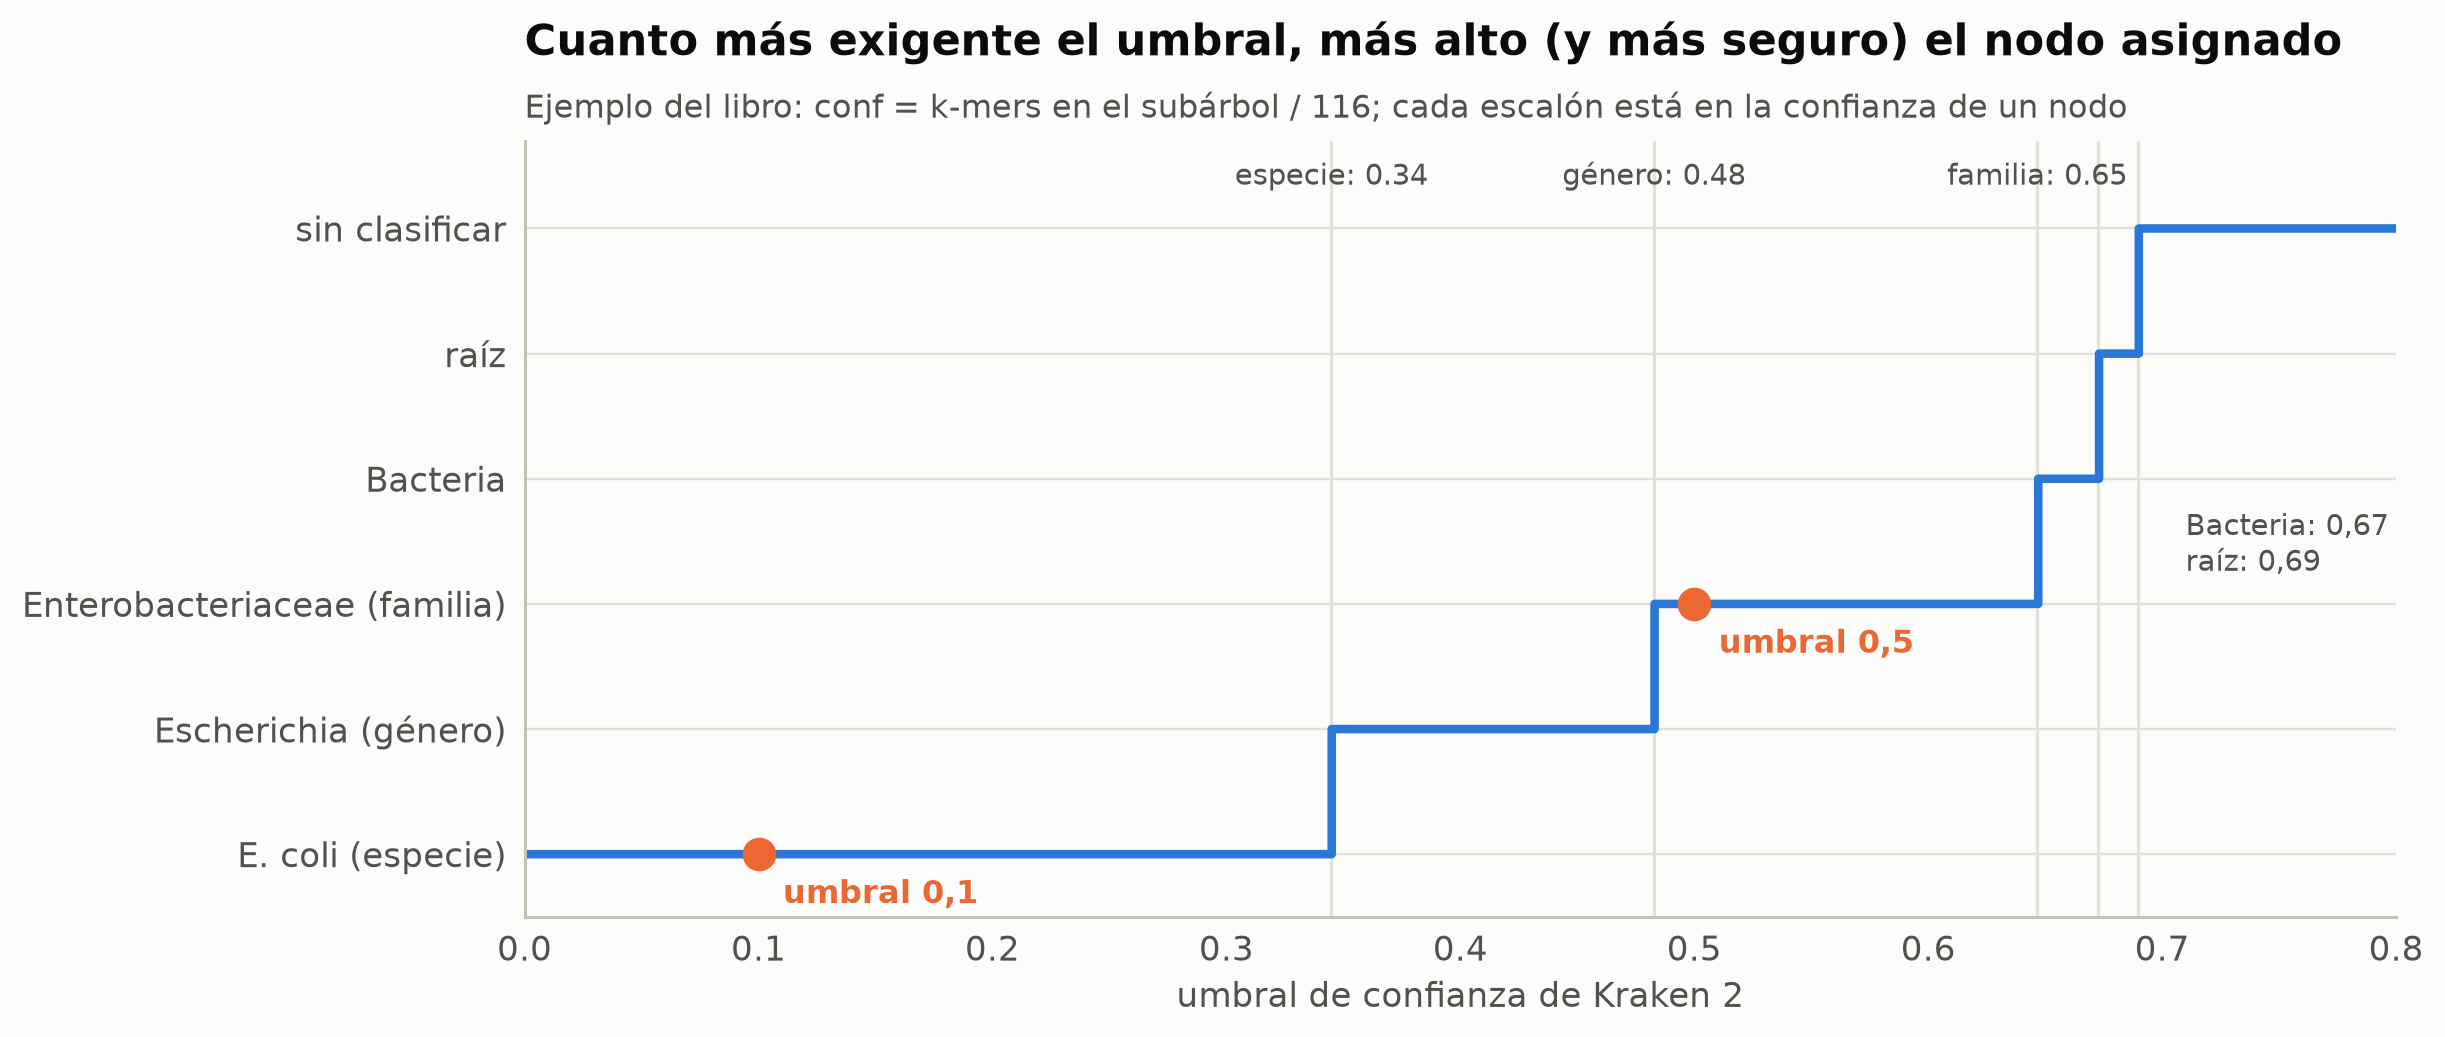

In [11]:
thr_grid = np.linspace(0, 0.8, 801)
levels = lineage("E. coli", book_parent)[::-1] + [None]          # de la especie a la raíz, y sin clasificar
calls = [confident_call("E. coli", book_w, N_KMERS_BOOK, book_parent, t) for t in thr_grid]
yv = [levels.index(c) for c in calls]
fig, ax = plt.subplots(figsize=(11, 4.6))
ax.step(thr_grid, yv, where="post", color=ec.BLUE, lw=2.8)
for t, lab in zip(lineage("E. coli", book_parent)[::-1], ["especie", "género", "familia", "Bacteria", "raíz"]):
    c = subtree_count(t, book_w, book_parent) / N_KMERS_BOOK
    ax.axvline(c, color=ec.GRID, lw=1, zorder=0)
    if lab in ("especie", "género", "familia"):
        ax.text(c, 5.35, f"{lab}: {c:.2f}", ha="center", fontsize=9.5, color=ec.INK_2)
ax.text(0.71, 2.75, "Bacteria: 0,67\nraíz: 0,69", ha="left", va="top", fontsize=9.5, color=ec.INK_2)
for thr, lab in [(0.1, "umbral 0,1"), (0.5, "umbral 0,5")]:
    ax.plot(thr, levels.index(confident_call("E. coli", book_w, N_KMERS_BOOK, book_parent, thr)), "o",
            color=ec.ORANGE, ms=10, zorder=5)
    ax.annotate(lab, (thr, levels.index(confident_call("E. coli", book_w, N_KMERS_BOOK, book_parent, thr))),
                xytext=(8, -16), textcoords="offset points", color=ec.ORANGE, fontsize=10.5, fontweight="bold")
ax.set_yticks(range(len(levels)), ["E. coli (especie)", "Escherichia (género)", "Enterobacteriaceae (familia)",
                                     "Bacteria", "raíz", "sin clasificar"])
ax.set_ylim(-0.5, 5.7); ax.set_xlim(0, 0.8)
ax.set_xlabel("umbral de confianza de Kraken 2")
ec.title(ax, "Cuanto más exigente el umbral, más alto (y más seguro) el nodo asignado",
         "Ejemplo del libro: conf = k-mers en el subárbol / 116; cada escalón está en la confianza de un nodo")
plt.show()

> 🔎 **Qué observamos.** La asignación es una escalera: con umbral 0,1 se mantiene en *E. coli*; entre 0,345 y 0,483
> sube al género; con 0,5 sube hasta *Enterobacteriaceae*; por encima de $80/116 = 0{,}69$ ni la raíz alcanza el umbral
> y la lectura queda sin clasificar (los 36 $k$-mers sin coincidencia cuentan en el denominador). El umbral **no cambia
> el camino**, sólo la altura a la que nos detenemos en él.

> ⚠️ **La base de datos es el experimento.** Un clasificador de $k$-mers sólo reconoce lo que su base contiene: las
> lecturas de una especie ausente se asignan al pariente más cercano o quedan sin clasificar, y una base contaminada
> produce detecciones fantasma. Informe la **versión exacta de la base** y el **porcentaje de lecturas sin
> clasificar**, y desconfíe de especies detectadas con pocas lecturas en muestras de baja biomasa, donde dominan los
> contaminantes de los reactivos. En la sección siguiente lo veremos en carne propia.

## 6. 🧪 Caso real: una «mini-Kraken» contra la comunidad ZymoBIOMICS

Ahora construiremos nuestro propio clasificador, con exactamente las reglas de las secciones 4 y 5, y lo pondremos a
prueba como lo haría el laboratorio de microbiología antes de usarlo con la paciente.

### 6.1 La base de referencia: 10 genomas de RefSeq y su taxonomía

Incluimos un genoma de referencia de RefSeq para cada una de las 8 bacterias de la comunidad Zymo y, a propósito,
**dos parientes cercanos que no están en la muestra**: *Shigella flexneri* (que comparte buena parte de su genoma con
*E. coli*) y ***Listeria innocua***, la especie no patógena que un laboratorio clínico debe distinguir de *L.
monocytogenes*. Las dos levaduras de la comunidad (*Saccharomyces cerevisiae* y *Cryptococcus neoformans*) **no** están
en la base: sus lecturas deberían quedar sin clasificar.

| especie | genoma de referencia (RefSeq) | ¿en la comunidad Zymo? |
|---|---|---|
| *Pseudomonas aeruginosa* | PAO1, NC_002516.2 | sí (12 % del ADN) |
| *Escherichia coli* | K-12 MG1655, NC_000913.3 | sí (12 %) |
| *Salmonella enterica* | Typhimurium LT2, NC_003197.2 | sí (12 %) |
| *Shigella flexneri* | 2a str. 301, NC_004337.2 | **no** (pariente de *E. coli*) |
| *Limosilactobacillus fermentum* | IFO 3956, NC_010610.1 | sí (12 %) |
| *Enterococcus faecalis* | V583, NC_004668.1 | sí (12 %) |
| *Staphylococcus aureus* | NCTC 8325, NC_007795.1 | sí (12 %) |
| *Listeria monocytogenes* | EGD-e, NC_003210.1 | sí (12 %) |
| *Listeria innocua* | Clip11262, NC_003212.1 | **no** (pariente de *L. monocytogenes*) |
| *Bacillus subtilis* | 168, NC_000964.3 | sí (12 %) |

La taxonomía (dominio → filo → clase → orden → familia → género → especie) la pedimos a la base **Taxonomy del NCBI**
con E-utilities, igual que en la Lección 1.2, y la guardamos en caché. Si le sorprende ver *Staphylococcus*,
*Listeria* y *Bacillus* bajo el orden «Caryophanales» y no «Bacillales»: es la clasificación vigente en el NCBI tras
una reorganización reciente; la taxonomía del RDP que usamos en la Lección 14.1 aún emplea «Bacillales».

In [12]:
EUTILS = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi"
GENOMES = [  # (accesión, taxid de la cepa, especie, ¿en la comunidad Zymo?)
    ("NC_002516.2", 208964, "Pseudomonas aeruginosa", True),
    ("NC_000913.3", 511145, "Escherichia coli", True),
    ("NC_003197.2", 99287, "Salmonella enterica", True),
    ("NC_004337.2", 198214, "Shigella flexneri", False),
    ("NC_010610.1", 334390, "Limosilactobacillus fermentum", True),
    ("NC_004668.1", 226185, "Enterococcus faecalis", True),
    ("NC_007795.1", 93061, "Staphylococcus aureus", True),
    ("NC_003210.1", 169963, "Listeria monocytogenes", True),
    ("NC_003212.1", 272626, "Listeria innocua", False),
    ("NC_000964.3", 224308, "Bacillus subtilis", True)]

# --- Taxonomía del NCBI (efetch db=taxonomy, XML) -----------------------------------------------
RANKS = ["domain", "superkingdom", "phylum", "class", "order", "family", "genus", "species"]
RANK_ES = {"root": "raíz", "domain": "dominio", "superkingdom": "dominio", "phylum": "filo", "class": "clase",
           "order": "orden", "family": "familia", "genus": "género", "species": "especie"}
tax_url = f"{EUTILS}?db=taxonomy&id={','.join(str(g[1]) for g in GENOMES)}&retmode=xml"
tax_xml = ET.fromstring(course_bytes("api_cache/143_ncbi_taxonomy_efetch.xml", tax_url))
tax_parent, tax_name, tax_rank = {1: None}, {1: "raíz"}, {1: "root"}
strain2species = {}
for t in tax_xml.findall("Taxon"):
    prev = 1
    for l in t.find("LineageEx"):
        if l.findtext("Rank") in RANKS:
            tid = int(l.findtext("TaxId"))
            tax_parent[tid], tax_name[tid], tax_rank[tid] = prev, l.findtext("ScientificName"), l.findtext("Rank")
            prev = tid
    strain2species[int(t.findtext("TaxId"))] = prev              # la especie es el último rango de la lista
SPECIES = [strain2species[g[1]] for g in GENOMES]                # taxid de especie de cada genoma
IN_MOCK = {sp: g[3] for sp, g in zip(SPECIES, GENOMES)}
for sp, g in zip(SPECIES, GENOMES):
    print(f"{g[0]}  {' › '.join(tax_name[t] for t in lineage(sp, tax_parent)[1:])}")

NC_002516.2  Bacteria › Pseudomonadota › Gammaproteobacteria › Pseudomonadales › Pseudomonadaceae › Pseudomonas › Pseudomonas aeruginosa
NC_000913.3  Bacteria › Pseudomonadota › Gammaproteobacteria › Enterobacterales › Enterobacteriaceae › Escherichia › Escherichia coli
NC_003197.2  Bacteria › Pseudomonadota › Gammaproteobacteria › Enterobacterales › Enterobacteriaceae › Salmonella › Salmonella enterica
NC_004337.2  Bacteria › Pseudomonadota › Gammaproteobacteria › Enterobacterales › Enterobacteriaceae › Shigella › Shigella flexneri
NC_010610.1  Bacteria › Bacillota › Bacilli › Lactobacillales › Lactobacillaceae › Limosilactobacillus › Limosilactobacillus fermentum
NC_004668.1  Bacteria › Bacillota › Bacilli › Lactobacillales › Enterococcaceae › Enterococcus › Enterococcus faecalis
NC_007795.1  Bacteria › Bacillota › Bacilli › Caryophanales › Staphylococcaceae › Staphylococcus › Staphylococcus aureus
NC_003210.1  Bacteria › Bacillota › Bacilli › Caryophanales › Listeriaceae › Listeria 

In [13]:
def fetch_genome(acc):
    """Genoma de RefSeq codificado en 0..3: copia local → NCBI (efetch) → respaldo en GitHub."""
    name = "NC_000913.3.fasta.gz" if acc == "NC_000913.3" else f"143_{acc}.fasta.gz"
    raw = course_bytes(name, f"{EUTILS}?db=nuccore&id={acc}&rettype=fasta&retmode=text")
    if raw[:2] == b"\x1f\x8b":
        raw = gzip.decompress(raw)
    return encode(raw.split(b"\n", 1)[1].replace(b"\n", b""))

t0 = time.time()
genomes = {sp: fetch_genome(g[0]) for sp, g in zip(SPECIES, GENOMES)}
print(f"10 genomas, {sum(len(x) for x in genomes.values()) / 1e6:.1f} Mb en total ({time.time() - t0:.0f} s)")
for sp, x in genomes.items():
    print(f"  {tax_name[sp]:32s} {len(x) / 1e6:5.2f} Mb   GC = {np.isin(x, (1, 2)).mean():.1%}")

10 genomas, 38.7 Mb en total (0 s)


  Pseudomonas aeruginosa            6.26 Mb   GC = 66.6%
  Escherichia coli                  4.64 Mb   GC = 50.8%


  Salmonella enterica               4.86 Mb   GC = 52.2%
  Shigella flexneri                 4.61 Mb   GC = 50.9%


  Limosilactobacillus fermentum     2.10 Mb   GC = 51.5%
  Enterococcus faecalis             3.22 Mb   GC = 37.5%
  Staphylococcus aureus             2.82 Mb   GC = 32.9%


  Listeria monocytogenes            2.94 Mb   GC = 38.0%
  Listeria innocua                  3.01 Mb   GC = 37.4%


  Bacillus subtilis                 4.22 Mb   GC = 43.5%


### 6.2 Construir la base: cada 31-mer con su LCA

El algoritmo es exactamente la definición de $\tau(\kappa)$, escrita con operaciones vectorizadas:

1. Para cada genoma $i$, obtener sus 31-mers **canónicos** distintos (codificados en 64 bits, como en la Lección 8.1).
2. Juntar los de los 10 genomas y **ordenarlos**; los $k$-mers repetidos quedan contiguos.
3. Para cada $k$-mer distinto, calcular con un **OR de bits** qué genomas lo contienen (una máscara de 10 bits: el bit
   $i$ vale 1 si el genoma $i$ tiene ese $k$-mer).
4. Traducir cada máscara a su LCA en la taxonomía: $\tau(\kappa) = \mathrm{LCA}\{\text{especies con bit } 1\}$.

Hay a lo sumo $2^{10}$ máscaras posibles, pero en la práctica aparecen sólo unas pocas decenas, así que el paso 4 se
hace una vez por máscara, no por $k$-mer. Tardará unos segundos: son unos 35 millones de $k$-mers.

In [14]:
K = 31
t0 = time.time()
parts, owners = [], []
for i, sp in enumerate(SPECIES):
    u = np.unique(kmer_codes(genomes[sp], K))                       # 31-mers canónicos distintos del genoma i
    parts.append(u)
    owners.append(np.full(len(u), i, np.uint8))
n_per_genome = {sp: len(p) for sp, p in zip(SPECIES, parts)}
allk = np.concatenate(parts); own = np.concatenate(owners); del parts, owners
order = np.argsort(allk, kind="stable")
allk = allk[order]
bits = np.left_shift(np.uint16(1), own[order].astype(np.uint16)); del order, own
starts = np.flatnonzero(np.r_[True, allk[1:] != allk[:-1]])
db_kmers = allk[starts]                                              # k-mers distintos, ordenados
db_mask = np.bitwise_or.reduceat(bits, starts); del allk, bits, starts

# paso 4: de la máscara de genomas al LCA
mask_values, mask_inv = np.unique(db_mask, return_inverse=True)
mask2lca = {int(m): lca_of([SPECIES[i] for i in range(10) if (int(m) >> i) & 1], tax_parent) for m in mask_values}
db_tax = np.array([mask2lca[int(m)] for m in mask_values], dtype=np.int64)[mask_inv.ravel()]
print(f"Base construida en {time.time() - t0:.0f} s: {len(db_kmers):,} 31-mers distintos · "
      f"{len(mask_values)} combinaciones de genomas · {db_kmers.nbytes / 1e6:.0f} MB de k-mers")
tx_, nn_ = np.unique(db_tax, return_counts=True)
by_rank = pd.Series(nn_, index=[RANK_ES[tax_rank[t]] for t in tx_]).groupby(level=0).sum().sort_values(ascending=False)
print("nivel del LCA de los k-mers de la base:\n" + (by_rank / by_rank.sum()).map("{:.3%}".format).to_string())

Base construida en 26 s: 34,730,305 31-mers distintos · 89 combinaciones de genomas · 278 MB de k-mers


nivel del LCA de los k-mers de la base:
especie    91.590%
familia     7.531%
género      0.861%
clase       0.011%
orden       0.004%
dominio     0.004%


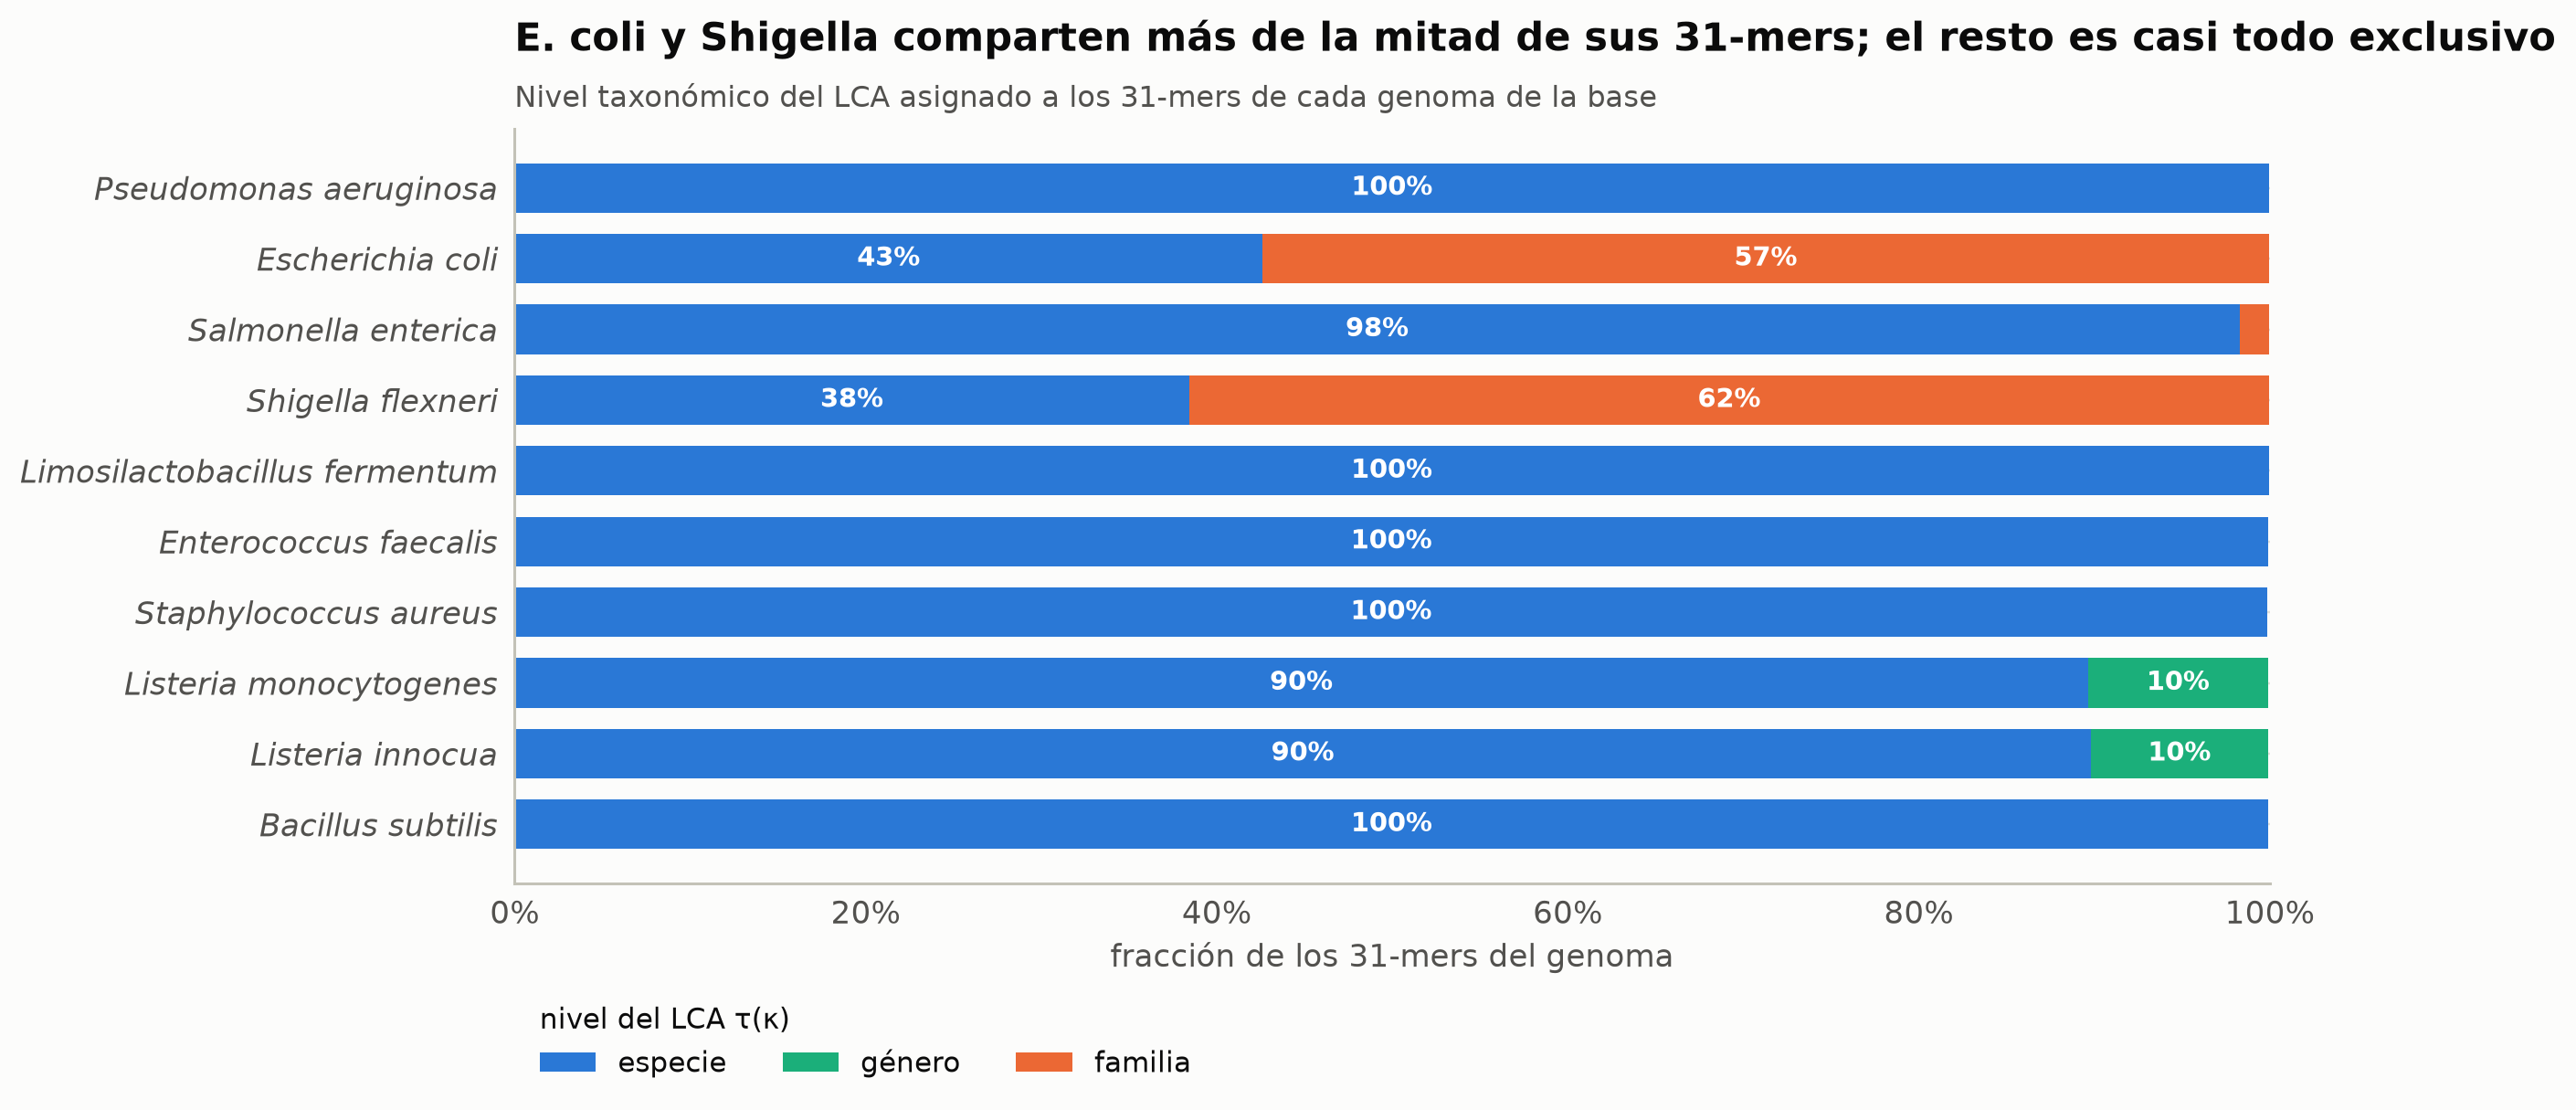

In [15]:
# ¿Qué fracción de los k-mers de cada genoma es exclusiva (τ = especie) y cuál se comparte?
rows = []
for i, sp in enumerate(SPECIES):
    sel = ((db_mask >> np.uint16(i)) & np.uint16(1)) == 1
    tx, nn = np.unique(db_tax[sel], return_counts=True)            # pocos taxones distintos: rápido
    vc = pd.Series(nn, index=[RANK_ES[tax_rank[t]] for t in tx]).groupby(level=0).sum() / nn.sum()
    rows.append(vc.rename(tax_name[sp]))
share = pd.DataFrame(rows).fillna(0)
cols_order = [c for c in ["especie", "género", "familia", "orden", "clase", "filo", "dominio", "raíz"]
              if c in share and share[c].max() > 0.002]
share = share[cols_order]
fig, ax = plt.subplots(figsize=(11.5, 5.4))
left = np.zeros(len(share))
palette = {"especie": ec.BLUE, "género": ec.CATEGORICAL[2], "familia": ec.ORANGE, "orden": ec.CATEGORICAL[3],
           "clase": ec.CATEGORICAL[4], "filo": ec.CATEGORICAL[6], "dominio": ec.MUTED, "raíz": ec.INK_2}
y = np.arange(len(share))[::-1]
for c in cols_order:
    ax.barh(y, share[c], left=left, color=palette[c], height=0.7, label=c)
    for yy, l, v in zip(y, left, share[c]):
        if v > 0.06:
            ax.text(l + v / 2, yy, f"{v:.0%}", ha="center", va="center", color="white", fontsize=9.5, fontweight="bold")
    left += share[c].values
ax.set_yticks(y, share.index, fontstyle="italic")
ax.set_xlim(0, 1); ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1))
ax.legend(ncol=len(cols_order), loc="upper left", bbox_to_anchor=(0, -0.13), frameon=False, fontsize=10,
          title="nivel del LCA τ(κ)", title_fontsize=10, alignment="left")
ax.set_xlabel("fracción de los 31-mers del genoma")
ec.title(ax, "E. coli y Shigella comparten más de la mitad de sus 31-mers; el resto es casi todo exclusivo",
         "Nivel taxonómico del LCA asignado a los 31-mers de cada genoma de la base")
plt.show()

> 🔎 **Qué observamos.** Para 8 de los 10 genomas, prácticamente todos los 31-mers son **exclusivos** de su especie:
> géneros distintos, aunque sean de la misma familia, rara vez comparten 31 bases idénticas seguidas fuera de los
> operones ribosómicos. Las dos excepciones son las que elegimos a propósito: *E. coli* y *S. flexneri* comparten
> alrededor del 50 % de sus $k$-mers (taxonómicamente son géneros distintos, pero genómicamente *Shigella* es un linaje
> de *E. coli*), y las dos *Listeria* comparten una fracción pequeña pero no nula. Las lecturas que caigan en esas
> zonas compartidas quedarán asignadas a la familia o al género, no a la especie.

### 6.3 Las lecturas: 15 000 lecturas reales de la comunidad Zymo

Descargar la corrida completa (8,8 millones de pares, casi 2 GB) no tiene sentido para una clase. Como los archivos de
ENA son FASTQ comprimidos con gzip, podemos **leer sólo el principio** con una petición HTTP de rango y descomprimirlo
en *streaming*. Descartamos las primeras 20 000 lecturas (vienen del borde de la celda de flujo, de peor calidad) y
tomamos una de cada 14 hasta reunir 15 000 lecturas R1. Si ya existe la copia del curso, se usa esa.

In [16]:
READS_NAME = "143_zymo_even_ERR2984773_15k_R1.fastq.gz"
ENA_R1 = "http://ftp.sra.ebi.ac.uk/vol1/fastq/ERR298/003/ERR2984773/ERR2984773_1.fastq.gz"

def stream_ena_subsample(url, nbytes=25_000_000, skip=20_000, every=14, n=15_000):
    """Lee los primeros nbytes de un FASTQ.gz de ENA (petición de rango) y submuestrea n lecturas."""
    req = urllib.request.Request(url, headers={"Range": f"bytes=0-{nbytes}"})
    with urllib.request.urlopen(req, timeout=120) as r:
        chunk = r.read()
    text = zlib.decompressobj(31).decompress(chunk)                 # descompresión parcial (streaming)
    lines = text.split(b"\n")
    recs = [lines[4 * i:4 * i + 4] for i in range(len(lines) // 4 - 1)]
    sel = recs[skip:skip + n * every:every]
    return gzip.compress(b"".join(b"\n".join(r) + b"\n" for r in sel))

local_reads = os.path.join("..", "data", READS_NAME)
if os.path.exists(local_reads):
    fq_gz = open(local_reads, "rb").read()
else:
    try:
        fq_gz = stream_ena_subsample(ENA_R1)
        print("Lecturas leídas en streaming desde ENA")
    except Exception as err:
        print(f"⚠️ ENA no respondió ({err}); uso la copia del curso")
        fq_gz = course_bytes(READS_NAME)
fq_lines = gzip.decompress(fq_gz).split(b"\n")
reads = [s for s in fq_lines[1::4] if s]
quals = [q for q in fq_lines[3::4] if q]
assert len(reads) == 15_000
lens = np.array([len(s) for s in reads])
meanq = np.array([np.frombuffer(q, np.uint8).mean() - 33 for q in quals])
print(f"{len(reads):,} lecturas · longitud {lens.min()}–{lens.max()} pb · Phred medio {meanq.mean():.1f} · "
      f"{lens.sum() / 1e6:.2f} Mb")

15,000 lecturas · longitud 151–151 pb · Phred medio 37.2 · 2.27 Mb


### 6.4 Clasificar: consultar, votar, elegir el camino

Para cada lectura: (1) calculamos sus 31-mers canónicos; (2) los buscamos en la base ordenada con **búsqueda binaria**
(`np.searchsorted`, que hace el papel de la tabla *hash*); (3) contamos los votos $w_t$ por taxón; (4) aplicamos la
regla RTL. Guardamos, además, los pesos de cada lectura, para poder aplicar después cualquier umbral de confianza sin
volver a consultar la base.

> 🤔 **Antes de ejecutar, prediga.** ¿Cuántas lecturas asignará el clasificador a *Shigella flexneri* y a *Listeria
> innocua*, que **no están** en la muestra? ¿Cero? ¿Decenas? ¿Cientos?

In [17]:
def kmer_votes(seq):
    """Pesos w_t de una lectura: cuántos de sus 31-mers tienen τ(κ) = t. Devuelve (Counter, nº de k-mers sin N)."""
    codes = kmer_codes(encode(seq), K)
    if len(codes) == 0:
        return Counter(), 0
    idx = np.searchsorted(db_kmers, codes)
    idx[idx >= len(db_kmers)] = 0
    hit = db_kmers[idx] == codes
    return Counter(db_tax[idx[hit]].tolist()), len(codes)

t0 = time.time()
votes, nk, calls = [], [], []
for s in reads:
    w, n = kmer_votes(s)
    c = rtl_classify(w, tax_parent)[0] if w else None
    votes.append(w); nk.append(n); calls.append(c)
nk = np.array(nk)
print(f"{len(reads):,} lecturas clasificadas en {time.time() - t0:.1f} s")
n_uncl = sum(c is None for c in calls)
print(f"sin clasificar: {n_uncl:,} ({n_uncl / len(reads):.1%})")

15,000 lecturas clasificadas en 2.6 s
sin clasificar: 2,329 (15.5%)


El formato de salida más usado es el **informe de Kraken** (`--report`): una fila por taxón con el porcentaje de
lecturas del clado, las lecturas del **clado** (el nodo y sus descendientes), las asignadas **directamente** al nodo, el
rango y el nombre sangrado según la profundidad. Construyámoslo.

In [18]:
def kraken_report(calls, parent, name, rank):
    """Informe estilo Kraken: % del total, lecturas del clado, lecturas directas, rango, taxid y nombre sangrado."""
    direct = Counter(c for c in calls if c is not None)
    clade = Counter()
    for t, v in direct.items():
        for a in lineage(t, parent):
            clade[a] += v
    children = defaultdict(list)
    for t in clade:
        if parent[t] is not None:
            children[parent[t]].append(t)
    rows = [(100 * sum(c is None for c in calls) / len(calls), sum(c is None for c in calls),
             sum(c is None for c in calls), "U", 0, "sin clasificar")]
    def visit(t, depth):
        rows.append((100 * clade[t] / len(calls), clade[t], direct.get(t, 0),
                     RANK_ES[rank[t]], t, "  " * depth + name[t]))
        for ch in sorted(children[t], key=lambda u: -clade[u]):
            visit(ch, depth + 1)
    visit(1, 0)
    return pd.DataFrame(rows, columns=["%", "clado", "directas", "rango", "taxid", "nombre"])

report = kraken_report(calls, tax_parent, tax_name, tax_rank)
with pd.option_context("display.max_rows", 60, "display.colheader_justify", "left"):
    display(report.style.format({"%": "{:.2f}"}).hide(axis="index")
            .set_properties(subset=["nombre"], **{"white-space": "pre", "font-family": "monospace", "text-align": "left"}))

%,clado,directas,rango,taxid,nombre
15.53,2329,2329,U,0,sin clasificar
84.47,12671,0,raíz,1,raíz
84.47,12671,1,dominio,2,Bacteria
46.08,6912,0,filo,1239,Bacillota
46.08,6912,1,clase,91061,Bacilli
26.19,3928,1,orden,1385,Caryophanales
9.42,1413,0,familia,186820,Listeriaceae
9.42,1413,45,género,1637,Listeria
7.51,1126,1126,especie,1639,Listeria monocytogenes
1.61,242,242,especie,1642,Listeria innocua


La misma información, como un **gráfico solar interactivo**: el anillo central es la raíz, y cada anillo hacia afuera es
un rango más fino. El ángulo de cada sector es proporcional a las lecturas del clado. Haga clic en un sector para
ampliarlo (por ejemplo, en *Enterobacteriaceae* o en *Listeria*) y pase el cursor para ver cuántas lecturas quedaron
asignadas directamente a ese nodo y cuántas bajaron a sus descendientes.

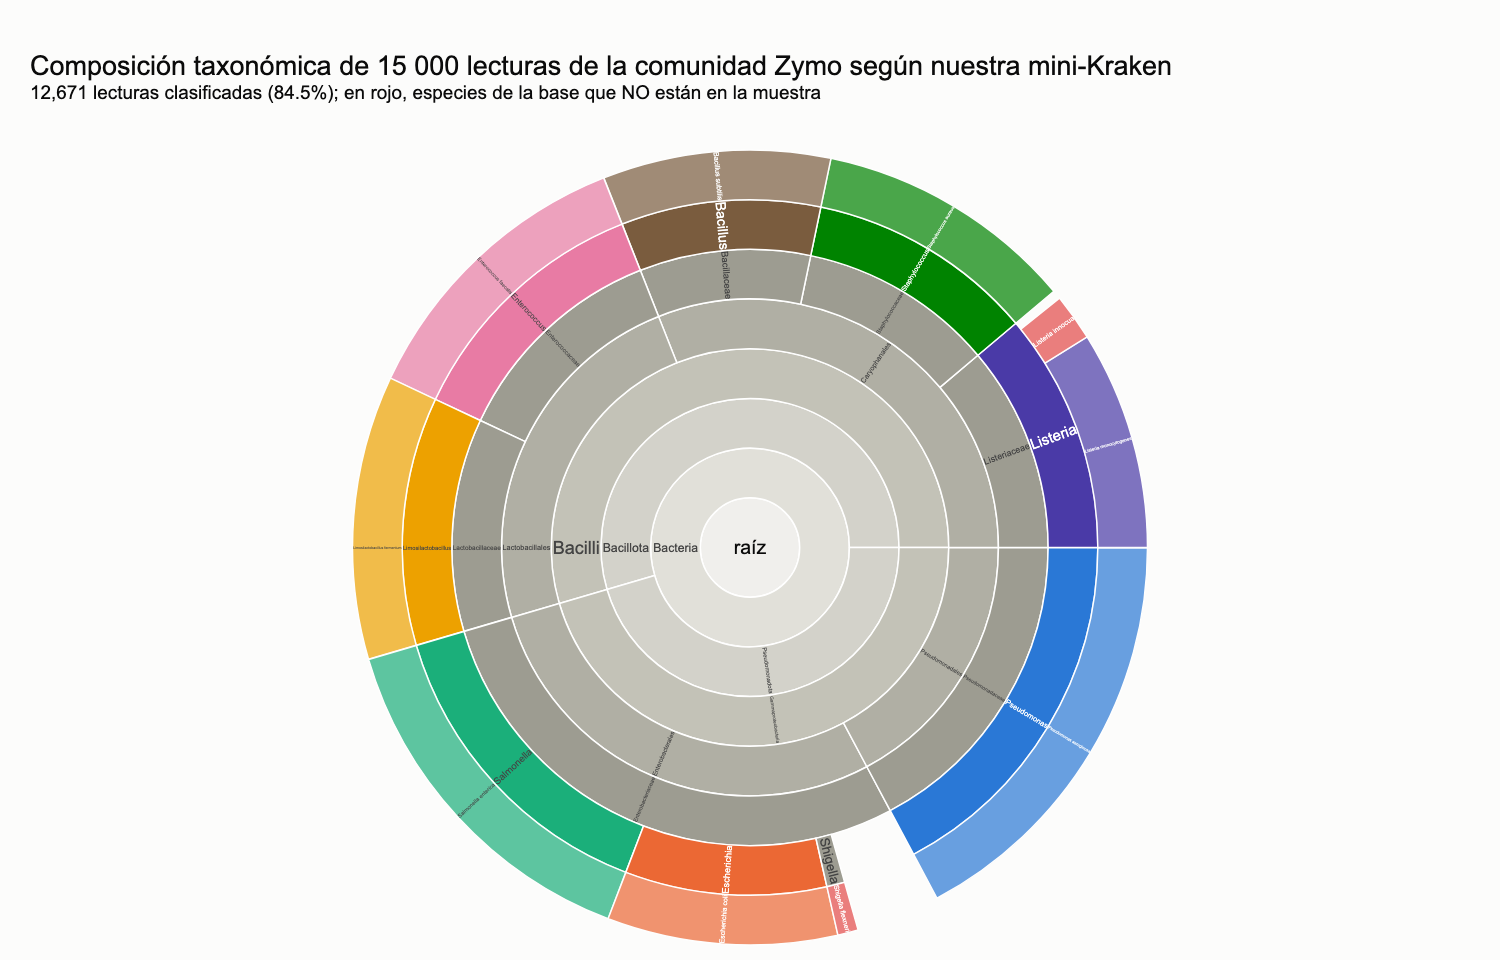

In [19]:
rep = report[report.taxid != 0].copy()
rep["label"] = rep.nombre.str.strip()
rep["parent"] = [str(tax_parent[t]) if tax_parent[t] else "" for t in rep.taxid]
n_class = int(rep.loc[rep.taxid == 1, "clado"].iloc[0])
# color: cada género con su color; rangos superiores en gris; especies ausentes de la muestra en rojo
genus_col = {}
for j, sp in enumerate(s_ for s_ in SPECIES if IN_MOCK[s_]):
    genus_col[tax_parent[sp]] = (ec.CATEGORICAL[:7] + ["#7a5c3e"])[j]          # sin el rojo (reservado)
def node_color(t):
    if t in IN_MOCK and not IN_MOCK[t]:
        return ec.RED
    for a in lineage(t, tax_parent)[::-1]:
        if a in genus_col:
            return genus_col[a]
    return ["#f0efec", "#e1e0d9", "#d3d2ca", "#c3c2b7", "#b0afa4", "#9d9c91"][min(len(lineage(t, tax_parent)) - 1, 5)]
node_colors = [node_color(t) for t in rep.taxid]
fig = go.Figure(go.Sunburst(
    ids=rep.taxid.astype(str), labels=rep.label, parents=rep.parent, values=rep.clado, branchvalues="total",
    customdata=np.c_[rep.directas, rep.clado / n_class * 100, rep.rango,
                     [("✔ en la comunidad" if IN_MOCK[t] else "✘ NO está en la comunidad") if t in IN_MOCK else ""
                      for t in rep.taxid]],
    hovertemplate=("<b>%{label}</b> (%{customdata[2]})<br>lecturas del clado: %{value:,}"
                   " = %{customdata[1]:.1f} % de las clasificadas<br>asignadas directamente a este nodo: %{customdata[0]:,}"
                   "<br>%{customdata[3]}<extra></extra>"),
    marker=dict(colors=node_colors, line=dict(color="white", width=1)),
    insidetextorientation="radial", maxdepth=8))
fig.update_layout(
    title=f"Composición taxonómica de 15 000 lecturas de la comunidad Zymo según nuestra mini-Kraken"
          f"<br><sup>{n_class:,} lecturas clasificadas ({n_class / len(reads):.1%}); en rojo, especies de la base que NO están en la muestra</sup>",
    height=640, margin=dict(t=100, l=10, r=10, b=10))
fig.show()

### 6.5 ¿Acertamos? Comparación con la composición esperada

La comunidad Zymo tiene un **12 % del ADN** de cada bacteria y un **2 %** de cada levadura. Como la fracción de lecturas
es proporcional a la fracción de ADN, esperamos:

* $\approx 4\,\%$ de lecturas sin clasificar (las levaduras, ausentes de nuestra base);
* $\approx 12\,\%$ de las lecturas en cada una de las 8 bacterias;
* **cero** lecturas en *S. flexneri* y *L. innocua*.

In [20]:
def species_counts(calls):
    """Lecturas asignadas a nivel de especie (lo que ve quien sólo lee la columna de especies)."""
    cc = Counter(c for c in calls if c is not None)
    return pd.Series({tax_name[sp]: cc.get(sp, 0) for sp in SPECIES})

sp_counts = species_counts(calls)
higher = sum(v for t, v in Counter(c for c in calls if c is not None).items() if t not in SPECIES)
comp = pd.DataFrame({"lecturas (especie)": sp_counts, "% del total": 100 * sp_counts / len(reads),
                     "esperado (%)": [12.0 if IN_MOCK[sp] else 0.0 for sp in SPECIES]})
print(comp.round(1).to_string())
print(f"\nasignadas a niveles superiores (género, familia…): {higher:,} ({higher / len(reads):.1%})")
print(f"sin clasificar: {n_uncl:,} ({n_uncl / len(reads):.1%}) frente al ≈ 4 % esperado (levaduras)")

                               lecturas (especie)  % del total  esperado (%)
Pseudomonas aeruginosa                       2178         14.5          12.0
Escherichia coli                             1186          7.9          12.0
Salmonella enterica                          1855         12.4          12.0
Shigella flexneri                             106          0.7           0.0
Limosilactobacillus fermentum                1462          9.7          12.0
Enterococcus faecalis                        1520         10.1          12.0
Staphylococcus aureus                        1341          8.9          12.0
Listeria monocytogenes                       1126          7.5          12.0
Listeria innocua                              242          1.6           0.0
Bacillus subtilis                            1173          7.8          12.0

asignadas a niveles superiores (género, familia…): 482 (3.2%)
sin clasificar: 2,329 (15.5%) frente al ≈ 4 % esperado (levaduras)


> 🔎 **Qué observamos.** Tres lecciones, todas reales:
>
> 1. **Sin clasificar ≈ 15 %, no 4 %.** Las levaduras explican unos 4 puntos; el resto son lecturas de las cepas de
>    Zymo que **no tienen ni un solo 31-mer idéntico** a nuestras cepas de RefSeq: genes accesorios, islas genómicas,
>    fagos y plásmidos propios de cada cepa. Es la caja de la sección 5 hecha número: *la base de datos es el
>    experimento*.
> 2. **Aparecen dos especies que no están**: *S. flexneri* recibe un centenar de lecturas y *L. innocua* un par de
>    centenares. No son contaminaciones: son lecturas de *E. coli* y *L. monocytogenes* de la muestra que, por ser
>    cepas distintas de las de referencia, tienen más 31-mers exactos en el genoma del pariente que en el de «su»
>    especie. En el LCR de la paciente, un informe que dijera «*L. innocua* 1,6 %» sería un error con consecuencias.
> 3. **Las abundancias a nivel de especie están sesgadas**: *E. coli* aparece muy por debajo del 12 %, porque cientos de
>    sus lecturas se quedaron en *Enterobacteriaceae* (los $k$-mers que comparte con *Shigella*). Lo corregiremos con
>    Bracken en la sección 7.

Veamos por dentro una de esas lecturas de *L. monocytogenes* que acabó en *L. innocua*:

In [21]:
innocua = [sp for sp in SPECIES if tax_name[sp] == "Listeria innocua"][0]
mono = [sp for sp in SPECIES if tax_name[sp] == "Listeria monocytogenes"][0]
ex_i = max((i for i, c in enumerate(calls) if c == innocua), key=lambda i: votes[i].get(mono, 0))
w_ex = votes[ex_i]
print(f"Lectura #{ex_i}: {nk[ex_i]} 31-mers, {sum(w_ex.values())} con coincidencia")
for t, v in sorted(w_ex.items(), key=lambda x: -x[1]):
    print(f"   w[{tax_name[t]:24s}] = {v}")
_, sc_ex = rtl_classify(w_ex, tax_parent)
for h, s in sorted(sc_ex.items(), key=lambda x: -x[1]):
    print(f"RTL({tax_name[h]}) = {s}")
for thr in (0.0, 0.1, 0.3, 0.5):
    t_ = confident_call(calls[ex_i], w_ex, nk[ex_i], tax_parent, thr)
    print(f"umbral {thr:.1f} → {tax_name[t_] if t_ else 'sin clasificar'}")

Lectura #5363: 121 31-mers, 90 con coincidencia
   w[Listeria innocua        ] = 35
   w[Listeria monocytogenes  ] = 31
   w[Listeria                ] = 24
RTL(Listeria innocua) = 59
RTL(Listeria monocytogenes) = 55
umbral 0.0 → Listeria innocua
umbral 0.1 → Listeria innocua
umbral 0.3 → Listeria
umbral 0.5 → Listeria


> 🔎 **Qué observamos.** La lectura tiene votos para las **dos** *Listeria*: los caminos compiten, y gana *L. innocua*
> por unos pocos $k$-mers. Con un umbral de confianza moderado, la asignación sube a **género *Listeria***, que es una
> respuesta menos precisa pero **correcta**. Veamos qué hacen distintos umbrales con todas las lecturas a la vez.

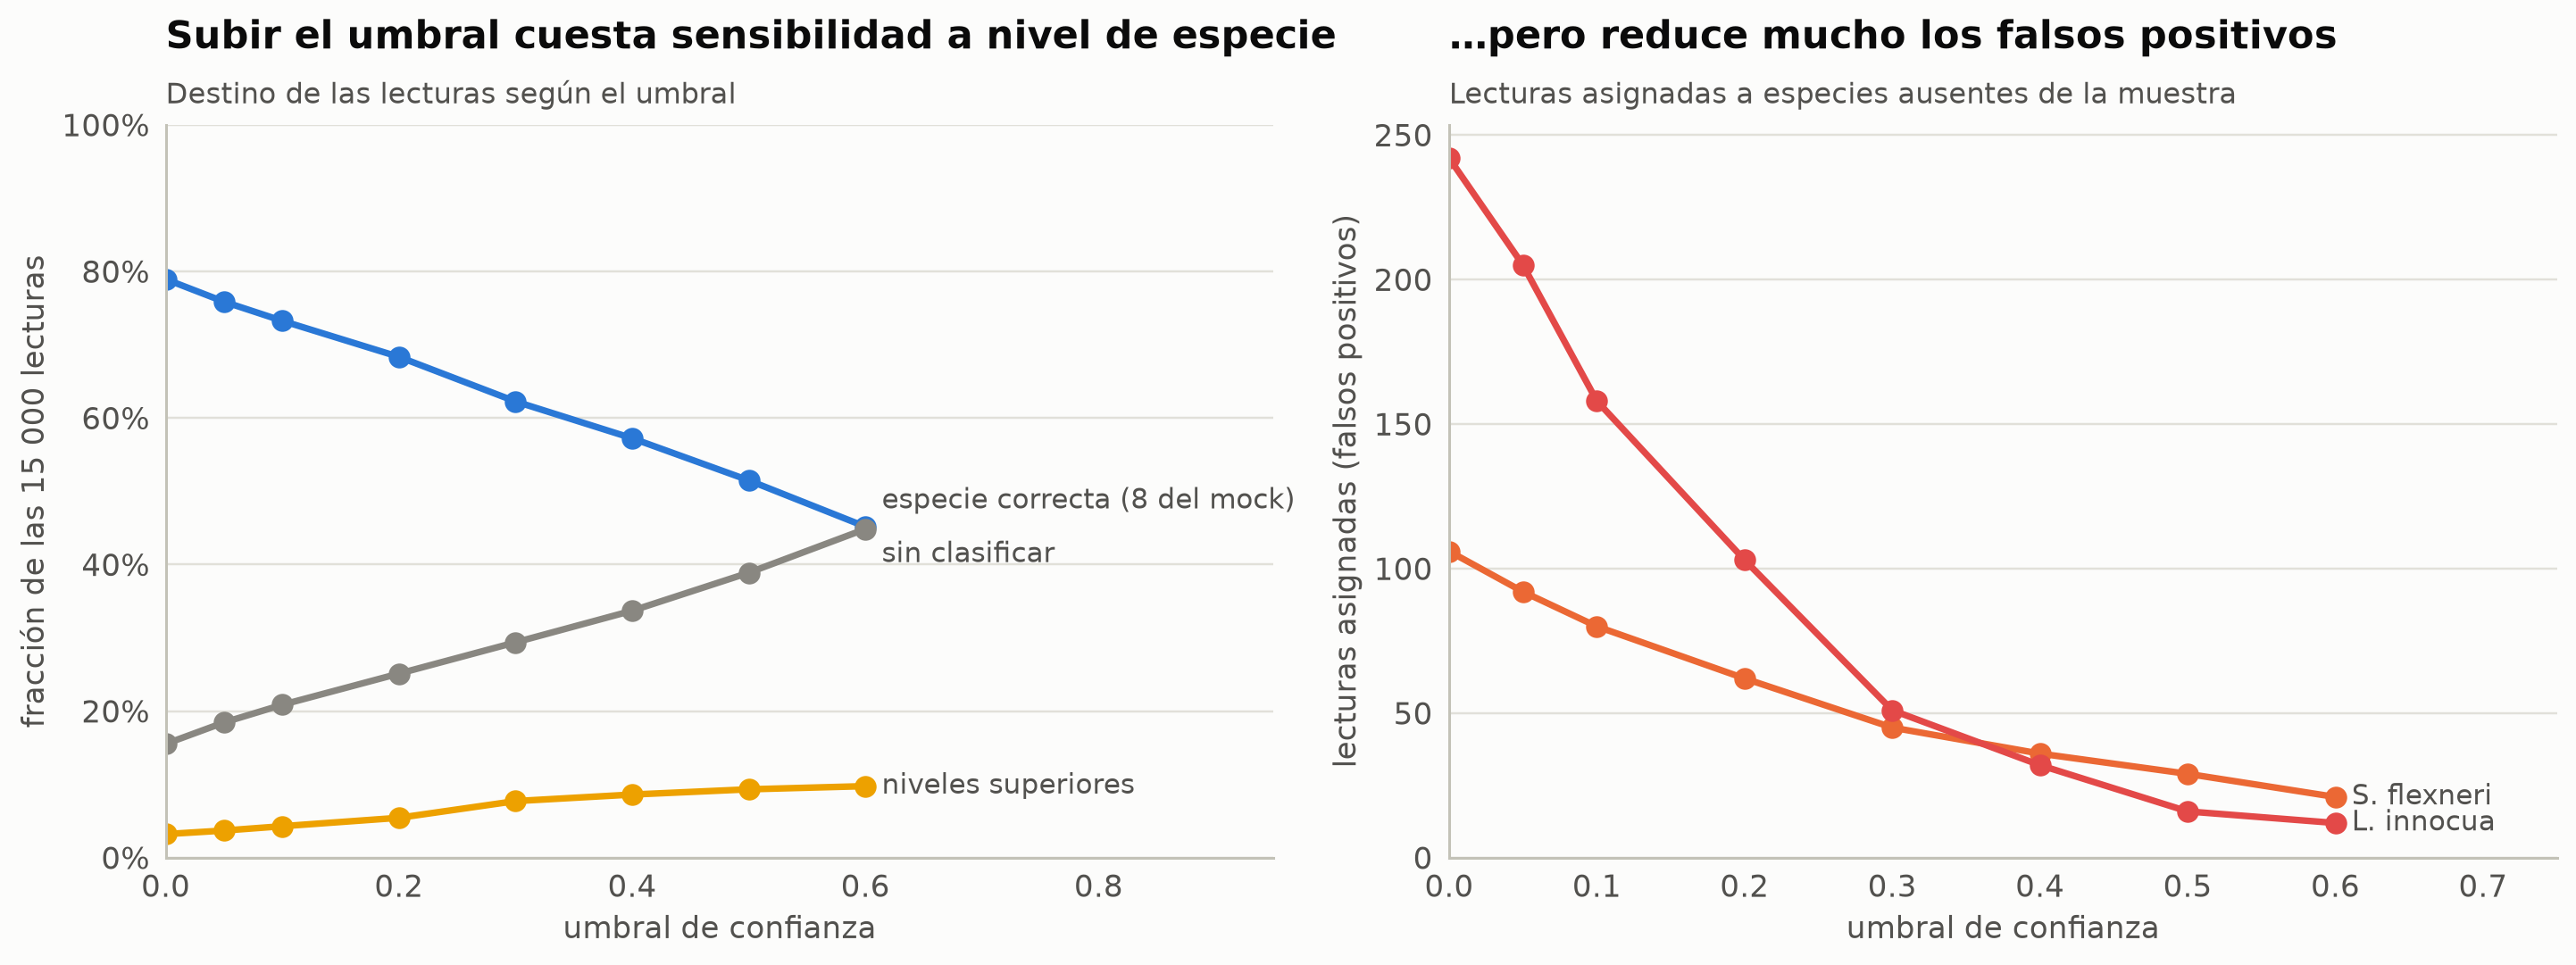

 umbral  especie correcta (8 del mock)  S. flexneri  L. innocua  niveles superiores  sin clasificar
   0.00                          0.789          106         242               0.032           0.155
   0.05                          0.759           92         205               0.037           0.185
   0.10                          0.733           80         158               0.043           0.209
   0.20                          0.683           62         103               0.054           0.251
   0.30                          0.623           45          51               0.077           0.294
   0.40                          0.572           36          32               0.086           0.337
   0.50                          0.515           29          16               0.093           0.389
   0.60                          0.452           21          12               0.098           0.448


In [22]:
thr_list = [0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
sweep = []
for thr in thr_list:
    cc = [confident_call(c, w, n, tax_parent, thr) if c is not None else None for c, w, n in zip(calls, votes, nk)]
    cnt = Counter(cc)
    sweep.append({"umbral": thr,
                  "especie correcta (8 del mock)": sum(cnt[sp] for sp in SPECIES if IN_MOCK[sp]) / len(reads),
                  "S. flexneri": cnt[SPECIES[3]], "L. innocua": cnt[innocua],
                  "niveles superiores": sum(v for t, v in cnt.items() if t is not None and t not in SPECIES) / len(reads),
                  "sin clasificar": cnt[None] / len(reads)})
sweep = pd.DataFrame(sweep)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))
for col, c_ in [("especie correcta (8 del mock)", ec.BLUE), ("niveles superiores", ec.CATEGORICAL[3]),
                ("sin clasificar", ec.MUTED)]:
    ax1.plot(sweep.umbral, sweep[col], "o-", color=c_, lw=2.4)
    dy = {"especie correcta (8 del mock)": 0.035, "sin clasificar": -0.035}.get(col, 0)
    ec.label_end(ax1, sweep.umbral.iloc[-1], sweep[col].iloc[-1] + dy, col)
ax1.set_xlim(0, 0.95); ax1.set_ylim(0, 1); ax1.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1))
ax1.set_xlabel("umbral de confianza"); ax1.set_ylabel("fracción de las 15 000 lecturas")
ec.title(ax1, "Subir el umbral cuesta sensibilidad a nivel de especie", "Destino de las lecturas según el umbral")
for col, c_ in [("S. flexneri", ec.ORANGE), ("L. innocua", ec.RED)]:
    ax2.plot(sweep.umbral, sweep[col], "o-", color=c_, lw=2.4)
    ec.label_end(ax2, sweep.umbral.iloc[-1], sweep[col].iloc[-1], col)
ax2.set_xlim(0, 0.75); ax2.set_ylim(0, None)
ax2.set_xlabel("umbral de confianza"); ax2.set_ylabel("lecturas asignadas (falsos positivos)")
ec.title(ax2, "…pero reduce mucho los falsos positivos", "Lecturas asignadas a especies ausentes de la muestra")
plt.show()
print(sweep.round(3).to_string(index=False))

> 🔎 **Qué observamos.** Es el compromiso clásico sensibilidad–especificidad. Con umbral 0 cada lectura llega tan
> abajo como puede, falsos positivos incluidos. Con umbral 0,3 las lecturas de *L. innocua* caen de 242 a 51 y las de
> *S. flexneri* de 106 a 45, mientras la fracción asignada a la especie correcta baja de 79 % a 62 %: los falsos
> positivos caen mucho más deprisa que la sensibilidad. Un laboratorio clínico elegiría el umbral con una
> comunidad simulada como ésta, **antes** de ver la muestra de la paciente, y además exigiría un mínimo de lecturas
> (y, si es posible, que se distribuyan por todo el genoma) para declarar una especie presente.

### 6.6 Nuestra mini-Kraken frente a Kraken 2

¿Se parece nuestro clasificador de juguete al de verdad? Construimos una base de Kraken 2 con **los mismos 10
genomas** (`kraken2-build` con las cabeceras `>acc|kraken:taxid|NNN` y la taxonomía del NCBI) y clasificamos las mismas
15 000 lecturas. Kraken 2 usa $k=35$, minimizadores de $\ell=31$ y la tabla compacta; nosotros, 31-mers completos.
Por defecto el cuaderno lee el informe guardado; en Colab puede poner `RUN_KRAKEN2 = True` para rehacerlo todo
(instala Kraken 2, descarga la taxonomía del NCBI, unos 65 MB, y construye la base en uno o dos minutos).

In [23]:
RUN_KRAKEN2 = False          # ← póngalo en True en Colab para ejecutar Kraken 2 de verdad (≈ 3 min)

k2_text = None
if RUN_KRAKEN2 and IN_COLAB:
    if shutil.which("kraken2") is None:
        subprocess.run("apt-get -qq install -y kraken2 > /dev/null", shell=True, check=True)
    os.makedirs("k2db/taxonomy", exist_ok=True)
    subprocess.run("wget -q -O - https://ftp.ncbi.nlm.nih.gov/pub/taxonomy/taxdump.tar.gz | "
                   "tar -xz -C k2db/taxonomy nodes.dmp names.dmp", shell=True, check=True)
    with open("k2_library.fa", "w") as out:                      # cabeceras con el taxid de cada cepa
        for sp, g in zip(SPECIES, GENOMES):
            seq = "".join("ACGTN"[b] for b in genomes[sp].tolist())
            out.write(f">{g[0]}|kraken:taxid|{g[1]}\n{seq}\n")
    open("zymo_15k.fastq.gz", "wb").write(fq_gz)
    for cmd in ["kraken2-build --add-to-library k2_library.fa --db k2db --no-masking",
                "kraken2-build --build --db k2db --threads 2",
                "kraken2 --db k2db --report zymo.k2report --output /dev/null zymo_15k.fastq.gz"]:
        print("$", cmd)
        subprocess.run(cmd + " > /dev/null 2> k2.log", shell=True, check=True)
    k2_text = open("zymo.k2report").read()
if k2_text is None:
    k2_text = course_bytes("143_kraken2_zymo_even_15k.k2report").decode()
    print("Usando el informe de Kraken 2 v2.17 guardado en el curso (misma base de 10 genomas, mismas lecturas).")

k2 = pd.read_csv(io.StringIO(k2_text), sep="\t", header=None,
                 names=["pct", "clade", "direct", "rank", "taxid", "name"])
k2_species = k2[k2["rank"] == "S"].set_index("taxid")["clade"]
cmp = pd.DataFrame({"mini-Kraken (k = 31)": [sp_counts[tax_name[sp]] for sp in SPECIES],
                    "Kraken 2 (k = 35, ℓ = 31)": [int(k2_species.get(sp, 0)) for sp in SPECIES]},
                   index=[tax_name[sp] for sp in SPECIES])
cmp.loc["Enterobacteriaceae (directas)"] = [Counter(calls)[543], int(k2.loc[k2.taxid == 543, "direct"].iloc[0])]
cmp.loc["sin clasificar"] = [n_uncl, int(k2.loc[k2.taxid == 0, "clade"].iloc[0])]
print(cmp.to_string())

Usando el informe de Kraken 2 v2.17 guardado en el curso (misma base de 10 genomas, mismas lecturas).
                               mini-Kraken (k = 31)  Kraken 2 (k = 35, ℓ = 31)
Pseudomonas aeruginosa                         2178                       2176
Escherichia coli                               1186                       1175
Salmonella enterica                            1855                       1859
Shigella flexneri                               106                        105
Limosilactobacillus fermentum                  1462                       1464
Enterococcus faecalis                          1520                       1516
Staphylococcus aureus                          1341                       1344
Listeria monocytogenes                         1126                       1156
Listeria innocua                                242                        246
Bacillus subtilis                              1173                       1248
Enterobacteriaceae (directas)

> 🔎 **Qué observamos.** Las dos columnas coinciden casi lectura a lectura: las mismas especies, los mismos falsos
> positivos (*S. flexneri* ≈ 100, *L. innocua* ≈ 240), casi el mismo porcentaje sin clasificar (14,8 % frente a
> 15,5 %). Kraken 2 clasifica algo más porque consulta **minimizadores**: basta con que coincidan 31 bases (el
> minimizador) aunque el 35-mer completo no coincida, y su tabla compacta admite alguna falsa coincidencia; eso le da
> un poco más de sensibilidad ante diferencias de cepa (por ejemplo, en *B. subtilis*). Nuestra
> implementación de 40 líneas captura, pues, **la lógica completa** de Kraken; lo que Kraken 2 añade es ingeniería para
> hacerlo con bases de cientos de gigabases.

## 7. De lecturas clasificadas a abundancias: Bracken

### 7.1 El sesgo: las especies con parientes pierden lecturas

Kraken asigna cada lectura al nodo **más específico que puede justificar**, y eso tiene un efecto indeseado sobre las
abundancias. Las especies con parientes cercanos en la base (muchos $k$-mers compartidos) dejan buena parte de sus
lecturas en el género o la familia, mientras que las especies «solitarias» retienen casi todas las suyas en la especie.
Contar sólo las lecturas asignadas a especie **subestima de forma sistemática** a las primeras: es lo que le pasó a
*E. coli* en la sección 6.

Piense en un censo en el que parte de los encuestados sólo escribe su provincia y no su ciudad. Si sabemos, por
experiencia previa, qué fracción de los habitantes de cada ciudad suele omitir la ciudad, podemos **repartir** los
formularios «sólo provincia» entre las ciudades de forma proporcional. Eso es Bracken (Lu *et al.*, 2017).

### 7.2 La regla de Bayes

Bracken empieza **simulando lecturas** de cada genoma de la base y clasificándolas con Kraken: así estima, para cada
especie $S_i$, la probabilidad $P(G\mid S_i)$ de que una lectura suya quede asignada a un nodo superior $G$. Con la
regla de Bayes, la probabilidad de que una lectura asignada a $G$ provenga de $S_i$ es

$$
P(S_i \mid G) = \frac{P(G \mid S_i)\, P(S_i)}{\sum_k P(G\mid S_k)\, P(S_k)}, \qquad
\hat{n}_i = K_i + n_G\, P(S_i\mid G) \qquad \text{(ecuación 14-bracken del libro)}
$$

| Símbolo | Significado |
|---|---|
| $P(G\mid S_i)$ | fracción de las lecturas de la especie $S_i$ que Kraken deja en el nodo superior $G$ (estimada por simulación) |
| $P(S_i)$ | abundancia relativa previa de $S_i$ dentro de $G$, estimada a partir de las lecturas asignadas a nivel de especie |
| $K_i$ | lecturas asignadas directamente a la especie $S_i$ |
| $n_G$ | lecturas asignadas al nodo $G$ (y no a sus descendientes) |
| $\hat{n}_i$ | estimación de Bracken del número de lecturas originadas en $S_i$ |

### 7.3 Ejemplo del libro: «Bracken en números»

Tres especies de un mismo género tienen **6000, 3000 y 1000** lecturas verdaderas. Kraken asigna a nivel de especie sólo
la fracción $P_{S\mid S} = (0{,}5;\ 0{,}8;\ 0{,}3)$ de las lecturas de cada una; el resto se queda en el género.

* Kraken deja $K = (3000;\ 2400;\ 300)$ lecturas a nivel de especie y $n_G = 3000 + 600 + 700 = 4300$ en el género.
* La probabilidad previa se estima con los conteos de especie: $P(S_i) = K_i/\sum K = (0{,}526;\ 0{,}421;\ 0{,}053)$.
* $P(G\mid S_i) = 1 - P_{S\mid S} = (0{,}5;\ 0{,}2;\ 0{,}7)$.
* Los productos son $(0{,}263;\ 0{,}084;\ 0{,}037)$, que normalizados dan $P(S_i\mid G) = (0{,}685;\ 0{,}219;\ 0{,}096)$.
* Las estimaciones finales son $\hat n = (3000 + 2945;\ 2400 + 942;\ 300 + 412) = (5945;\ 3342;\ 712)$, frente a los
  valores verdaderos $(6000;\ 3000;\ 1000)$.

In [24]:
true_n = np.array([6000, 3000, 1000])
p_ss = np.array([0.5, 0.8, 0.3])                    # P(asignada a especie | especie)
K_i = true_n * p_ss                                 # lecturas que Kraken deja en cada especie
n_G = (true_n * (1 - p_ss)).sum()                   # lecturas que se quedan en el género
P_S = K_i / K_i.sum()                               # previa estimada con los conteos (sesgados) de especie
P_G_S = 1 - p_ss
post = P_G_S * P_S / (P_G_S * P_S).sum()            # regla de Bayes
n_hat = K_i + n_G * post
print("K        =", K_i, "  n_G =", n_G)
print("P(S_i)   =", P_S.round(3))
print("productos=", (P_G_S * P_S).round(3))
print("P(S_i|G) =", post.round(3))
print("n̂        =", n_hat.round(0), " frente a la verdad", true_n)

K        = [3000. 2400.  300.]   n_G = 4300.0
P(S_i)   = [0.526 0.421 0.053]
productos= [0.263 0.084 0.037]
P(S_i|G) = [0.685 0.219 0.096]
n̂        = [5945. 3342.  712.]  frente a la verdad [6000 3000 1000]


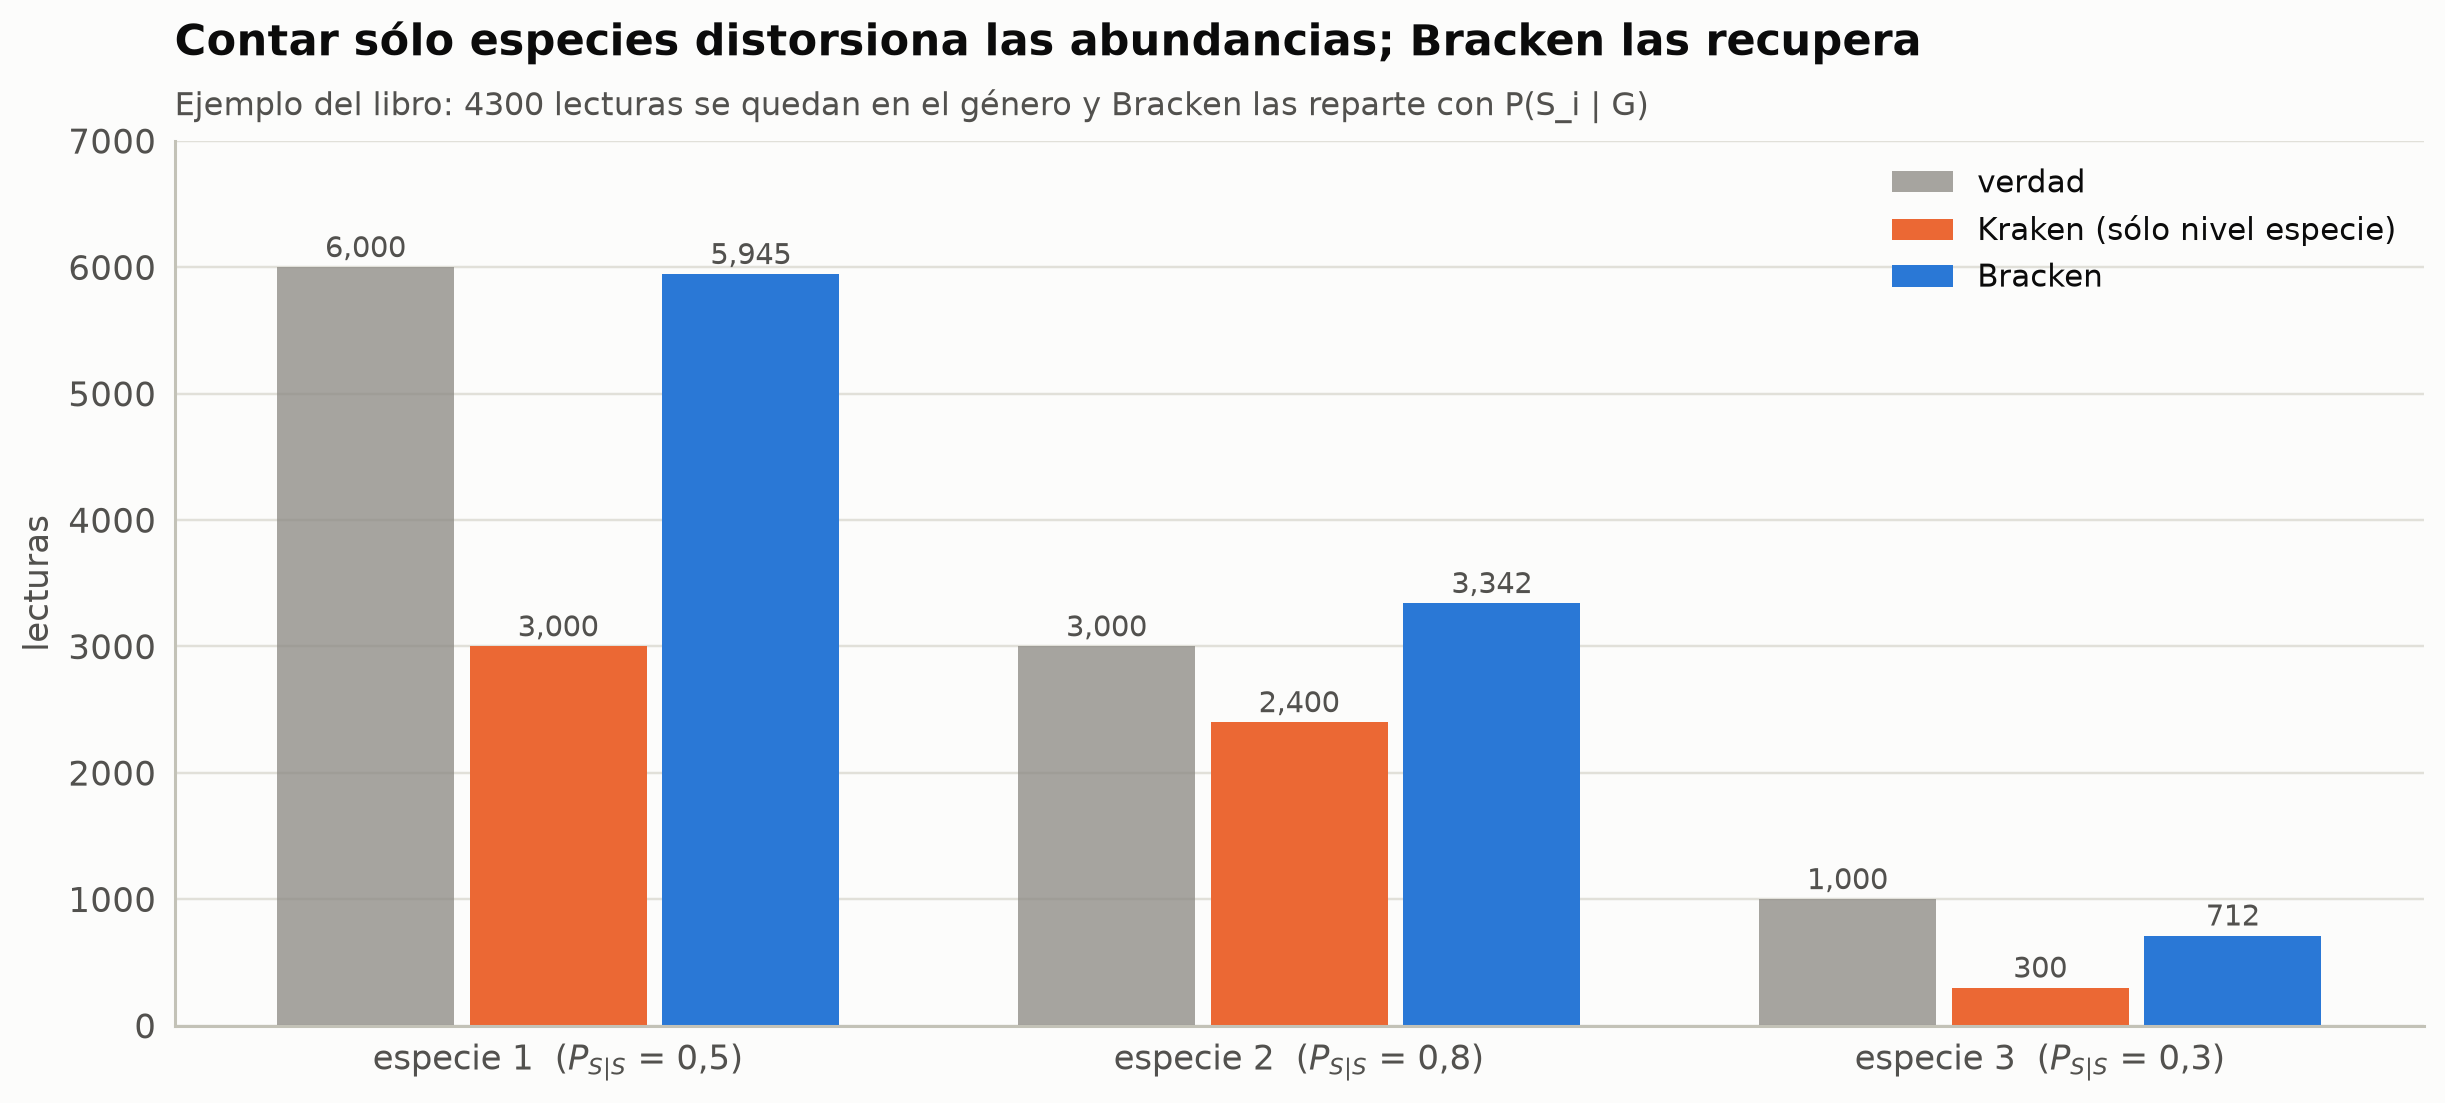

In [25]:
fig, ax = plt.subplots(figsize=(11, 4.9))
x = np.arange(3); wd = 0.26
for j, (vals, col, lab) in enumerate([(true_n, ec.MUTED, "verdad"), (K_i, ec.ORANGE, "Kraken (sólo nivel especie)"),
                                       (n_hat, ec.BLUE, "Bracken")]):
    b = ax.bar(x + (j - 1) * wd, vals, wd * 0.92, color=col, label=lab, alpha=0.75 if j == 0 else 1)
    for xx, v in zip(x + (j - 1) * wd, vals):
        ax.text(xx, v + 80, f"{v:,.0f}", ha="center", fontsize=9.5, color=ec.INK_2)
ax.set_xticks(x, [f"especie {i + 1}  ($P_{{S|S}}$ = {p:.1f})".replace(".", ",") for i, p in enumerate(p_ss)])
ax.set_ylim(0, 7000); ax.set_ylabel("lecturas")
ax.legend(loc="upper right", frameon=False)
ec.title(ax, "Contar sólo especies distorsiona las abundancias; Bracken las recupera",
         "Ejemplo del libro: 4300 lecturas se quedan en el género y Bracken las reparte con P(S_i | G)")
plt.show()

> 🔎 **Qué observamos.** Contar sólo el nivel de especie (naranja) casi iguala a las especies 1 y 2 (3000 frente a
> 2400, cuando la verdad es 6000 frente a 3000) y reduce la especie 3 a un 30 % de su valor. Bracken (azul) restablece las
> proporciones entre especies y, aproximadamente, las magnitudes. El **error residual** proviene de que la previa $P(S_i)$ se estima con los
> conteos sesgados de Kraken: la especie 3, que pierde el 70 % de sus lecturas, entra con una previa demasiado baja y
> recibe menos de lo que le toca (712 en lugar de 1000).

> ✅ **Compruebe su comprensión.** Si la previa fuera la verdadera, $P(S_i) = (0{,}6;\ 0{,}3;\ 0{,}1)$, ¿cuánto
> recibiría la especie 3? *(Productos $(0{,}30;\ 0{,}06;\ 0{,}07)$, $P(S_3\mid G) = 0{,}07/0{,}43 = 0{,}163$ y
> $\hat n_3 = 300 + 4300 \cdot 0{,}163 = 1000$: exacto. El ejercicio 3 explora cómo acercarse iterando.)*

### 7.4 Bracken con nuestros datos reales

Seguimos la receta de Bracken al pie de la letra: simulamos 1000 lecturas de 151 pb de **cada genoma de la base** (con
un 0,2 % de errores de secuenciación), las clasificamos con nuestra mini-Kraken y contamos a qué nodo va cada una.
Eso da la matriz $P(G\mid S_i)$.

In [26]:
def simulate_reads(g, n, L=151, err=0.002, rng=rng):
    """n lecturas de longitud L de un genoma codificado, hebra al azar y sustituciones con prob. err."""
    out = []
    for s in rng.integers(0, len(g) - L, n):
        r = g[s:s + L].copy()
        if rng.random() < 0.5:
            r = (3 - r)[::-1]                                      # hebra complementaria
        m = rng.random(L) < err
        r[m] = (r[m] + rng.integers(1, 4, m.sum())) % 4
        out.append(r)
    return out

def classify_encoded(x):
    """Igual que kmer_votes + RTL, para una lectura ya codificada."""
    codes = kmer_codes(x, K)
    idx = np.searchsorted(db_kmers, codes); idx[idx >= len(db_kmers)] = 0
    w = Counter(db_tax[idx[db_kmers[idx] == codes]].tolist())
    return rtl_classify(w, tax_parent)[0] if w else None

t0 = time.time()
rng_b = np.random.default_rng(2017)                               # año de Bracken
P_node = {}
for sp in SPECIES:
    cc = Counter(classify_encoded(r) for r in simulate_reads(genomes[sp], 1000, rng=rng_b))
    P_node[sp] = {t: v / 1000 for t, v in cc.items()}
print(f"Simulación de Bracken: 10 000 lecturas clasificadas en {time.time() - t0:.1f} s")
nodes_seen = sorted({t for d in P_node.values() for t in d if t is not None},
                    key=lambda t: (len(lineage(t, tax_parent)), tax_name[t]))
PGS = pd.DataFrame([[P_node[sp].get(t, 0) for t in nodes_seen] for sp in SPECIES],
                   index=[tax_name[sp] for sp in SPECIES], columns=[tax_name[t] for t in nodes_seen])
print(PGS.loc[:, PGS.max() >= 0.005].round(3).to_string())

Simulación de Bracken: 10 000 lecturas clasificadas en 1.9 s
                               Enterobacteriaceae  Listeria  Bacillus subtilis  Enterococcus faecalis  Escherichia coli  Limosilactobacillus fermentum  Listeria innocua  Listeria monocytogenes  Pseudomonas aeruginosa  Salmonella enterica  Shigella flexneri  Staphylococcus aureus
Pseudomonas aeruginosa                      0.000     0.000                0.0                    0.0             0.000                            0.0             0.000                   0.000                     1.0                0.000              0.000                  0.000
Escherichia coli                            0.231     0.000                0.0                    0.0             0.767                            0.0             0.000                   0.000                     0.0                0.000              0.000                  0.000
Salmonella enterica                         0.001     0.000                0.0                    0

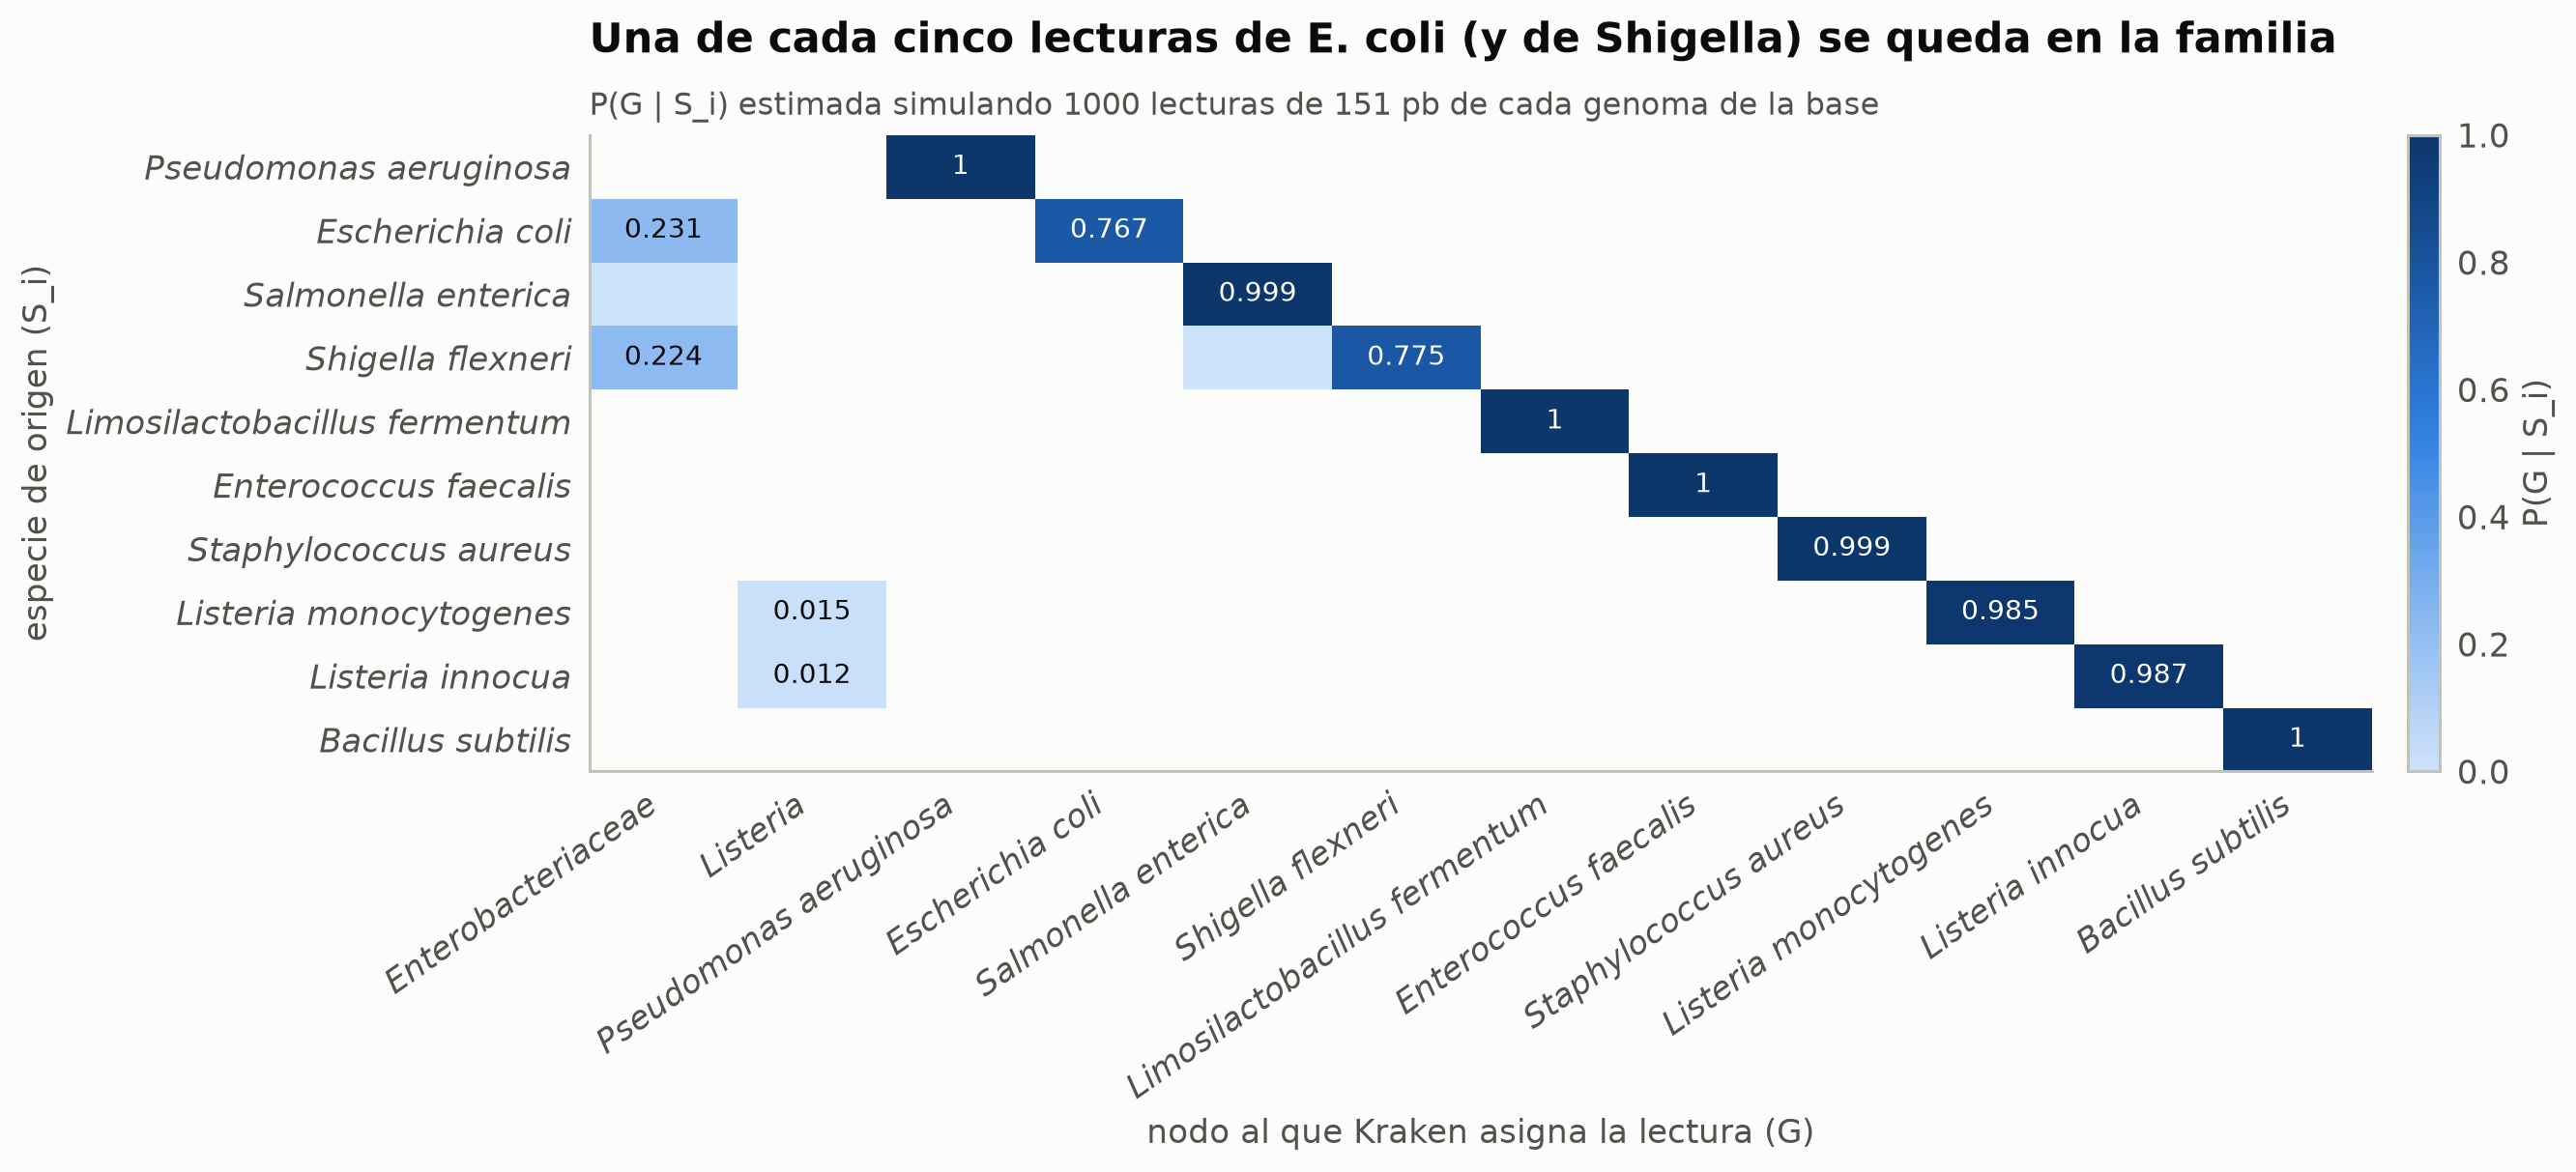

In [27]:
show = PGS.loc[:, PGS.max() >= 0.005]
sp_names = [tax_name[sp] for sp in SPECIES]
show = show[[c for c in show.columns if c not in sp_names] + [c for c in sp_names if c in show.columns]]
fig, ax = plt.subplots(figsize=(12, 5.4))
im = ax.imshow(np.where(show.values > 0, show.values, np.nan), cmap=ec.CMAP_SEQ, vmin=0, vmax=1, aspect="auto")
for i in range(show.shape[0]):
    for j in range(show.shape[1]):
        v = show.values[i, j]
        if v >= 0.005:
            ax.text(j, i, f"{v:.3f}".rstrip("0").rstrip(".") if v < 1 else "1", ha="center", va="center",
                    fontsize=9, color="white" if v > 0.55 else ec.INK)
ax.set_xticks(range(show.shape[1]), show.columns, rotation=35, ha="right", fontstyle="italic")
ax.set_yticks(range(show.shape[0]), show.index, fontstyle="italic")
ax.set_xlabel("nodo al que Kraken asigna la lectura (G)"); ax.set_ylabel("especie de origen (S_i)")
cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02); cb.set_label("P(G | S_i)")
ax.grid(False)
ec.title(ax, "Una de cada cinco lecturas de E. coli (y de Shigella) se queda en la familia",
         "P(G | S_i) estimada simulando 1000 lecturas de 151 pb de cada genoma de la base")
plt.show()

In [28]:
def bracken(calls, P_node, species):
    """Redistribuye las lecturas de nodos superiores con la ecuación 14-bracken. Devuelve (n̂, no asignables)."""
    direct = Counter(c for c in calls if c is not None)
    n_hat = {sp: float(direct.get(sp, 0)) for sp in species}
    lost = 0
    for G, n_G in direct.items():
        if G in species:
            continue
        under = [sp for sp in species if G in lineage(sp, tax_parent)]
        K_under = np.array([direct.get(sp, 0) for sp in under], float)
        prior = K_under / K_under.sum() if K_under.sum() > 0 else np.zeros(len(under))
        num = np.array([P_node[sp].get(G, 0) for sp in under]) * prior
        if num.sum() == 0:                           # ningún genoma simulado deja lecturas en G
            lost += n_G
            continue
        for sp, p in zip(under, num / num.sum()):
            n_hat[sp] += n_G * p
    return pd.Series({tax_name[sp]: v for sp, v in n_hat.items()}), lost

br, lost = bracken(calls, P_node, SPECIES)
entero = Counter(calls)[543]
print(f"Lecturas en Enterobacteriaceae: {entero}; lecturas no asignables a ninguna especie: {lost:.0f}")
res = pd.DataFrame({"Kraken (especie)": sp_counts, "Bracken": br.round(0)})
res["Kraken %"] = 100 * res["Kraken (especie)"] / res["Kraken (especie)"].sum()
res["Bracken %"] = 100 * res["Bracken"] / res["Bracken"].sum()
res["esperado %"] = [12.5 if IN_MOCK[sp] else 0 for sp in SPECIES]          # 12 % de 96 % bacteriano
print(res.round(1).to_string())

def bray_curtis(u, v):
    return np.abs(u - v).sum() / (u + v).sum()
bc_k = bray_curtis(res["Kraken %"].values, res["esperado %"].values)
bc_b = bray_curtis(res["Bracken %"].values, res["esperado %"].values)
print(f"\nBray-Curtis frente a lo esperado (Lección 14.2): Kraken {bc_k:.3f} · Bracken {bc_b:.3f}")

Lecturas en Enterobacteriaceae: 432; lecturas no asignables a ninguna especie: 2
                               Kraken (especie)  Bracken  Kraken %  Bracken %  esperado %
Pseudomonas aeruginosa                     2178   2178.0      17.9       17.2        12.5
Escherichia coli                           1186   1583.0       9.7       12.5        12.5
Salmonella enterica                        1855   1858.0      15.2       14.7        12.5
Shigella flexneri                           106    140.0       0.9        1.1         0.0
Limosilactobacillus fermentum              1462   1462.0      12.0       11.5        12.5
Enterococcus faecalis                      1520   1520.0      12.5       12.0        12.5
Staphylococcus aureus                      1341   1342.0      11.0       10.6        12.5
Listeria monocytogenes                     1126   1164.0       9.2        9.2        12.5
Listeria innocua                            242    250.0       2.0        2.0         0.0
Bacillus subtilis  

El gráfico interactivo compara las tres composiciones, **normalizadas sobre las lecturas bacterianas asignadas a
especie** (lo esperado es $12/96 = 12{,}5\,\%$ para cada bacteria de la comunidad, porque el 4 % de levaduras no está
en la base). Pase el cursor por las barras: verá las lecturas absolutas, la diferencia con lo esperado y qué parte de la
estimación de Bracken vino de lecturas redistribuidas desde nodos superiores.

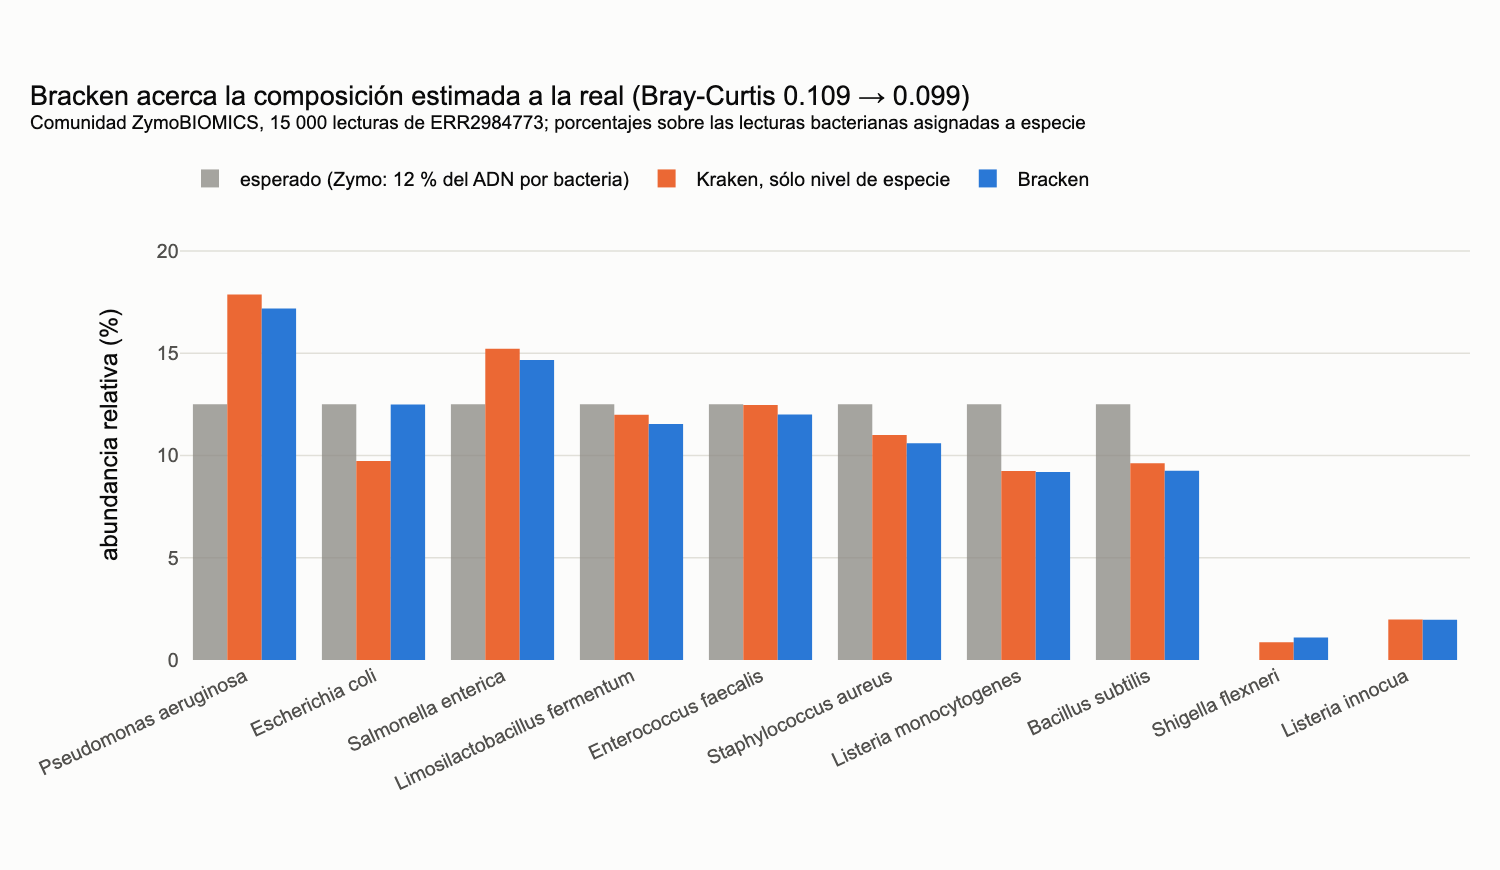

In [29]:
order_sp = res.sort_values("esperado %", ascending=False).index.tolist()
fig = go.Figure()
for col, lab, c_ in [("esperado %", "esperado (Zymo: 12 % del ADN por bacteria)", ec.MUTED),
                     ("Kraken %", "Kraken, sólo nivel de especie", ec.ORANGE), ("Bracken %", "Bracken", ec.BLUE)]:
    raw_col = {"esperado %": None, "Kraken %": "Kraken (especie)", "Bracken %": "Bracken"}[col]
    extra = [(res.loc[s, "Bracken"] - res.loc[s, "Kraken (especie)"]) for s in order_sp]
    fig.add_trace(go.Bar(
        x=order_sp, y=res.loc[order_sp, col], name=lab, marker_color=c_, opacity=0.75 if raw_col is None else 1,
        customdata=np.c_[[res.loc[s, raw_col] if raw_col else np.nan for s in order_sp],
                         res.loc[order_sp, col] - res.loc[order_sp, "esperado %"], extra],
        hovertemplate=("<b><i>%{x}</i></b><br>" + lab + ": %{y:.1f} %"
                       + ("" if raw_col is None else "<br>lecturas: %{customdata[0]:,.0f}")
                       + ("" if raw_col is None else "<br>diferencia con lo esperado: %{customdata[1]:+.1f} puntos")
                       + ("<br>lecturas recuperadas de nodos superiores: %{customdata[2]:,.0f}" if col == "Bracken %" else "")
                       + "<extra></extra>")))
fig.update_layout(
    barmode="group",
    title=f"Bracken acerca la composición estimada a la real (Bray-Curtis {bc_k:.3f} → {bc_b:.3f})"
          "<br><sup>Comunidad ZymoBIOMICS, 15 000 lecturas de ERR2984773; porcentajes sobre las lecturas bacterianas asignadas a especie</sup>",
    yaxis=dict(title="abundancia relativa (%)", range=[0, 22]), xaxis=dict(tickangle=-25),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), height=580, margin=dict(t=140, b=140, l=120, r=20))
fig.show()

> 🔎 **Qué observamos.** Casi todas las lecturas de *Enterobacteriaceae* vuelven a *E. coli*, porque es la especie
> con mayor $P(G\mid S_i) \cdot P(S_i)$ en la familia, y su abundancia sube hacia lo esperado. La distancia de
> Bray-Curtis a la composición teórica baja. Pero Bracken **no hace milagros**: no puede quitar las lecturas de *S.
> flexneri* y *L. innocua* (ya estaban asignadas a especie, y la corrección sólo mueve lecturas **hacia abajo**), y no
> corrige los sesgos que ocurren **antes** de la clasificación: el sesgo de extracción de ADN (las Gram positivas de
> pared gruesa se lisan peor), el sesgo de GC de la PCR de la biblioteca y las lecturas de cepa que no están en la
> base. Por eso las 8 bacterias no quedan exactamente en 12,5 %.

> ✅ **Compruebe su comprensión.** ¿Por qué Bracken reparte las lecturas de *Enterobacteriaceae* casi sólo entre *E.
> coli* y *S. flexneri*, y casi nada a *Salmonella*, aunque *Salmonella* tenga más lecturas a nivel de especie?
> *(Porque $P(\textit{Enterobacteriaceae}\mid \textit{S. enterica}) \approx 0$: las lecturas de Salmonella casi nunca
> se quedan en la familia. El producto $P(G\mid S_i)P(S_i)$ es el que manda, no la previa sola.)*

## 8. Perfilado con genes marcadores: MetaPhlAn

Una estrategia alternativa se concentra sólo en las **lecturas informativas**. MetaPhlAn usa **marcadores específicos
de clado**: genes presentes en todos los genomas de un clado y en ninguno fuera de él. La abundancia de cada clado se
estima con la cobertura media robusta de sus marcadores, normalizada por longitud; como son de copia única, el
resultado se aproxima a una abundancia de **células**, no de ADN. La cuarta versión (Blanco-Míguez *et al.*, 2023)
construyó sus marcadores a partir de alrededor de un millón de genomas de referencia y MAGs, agrupados en unos 27 000
*bins* genómicos a nivel de especie (SGBs), miles de ellos sin nombre: especies conocidas sólo por su genoma.

La diferencia entre abundancia de ADN y de células no es un detalle. Un genoma el doble de grande aporta el doble de
ADN por célula. Si $\alpha_i$ es la fracción de ADN y $G_i$ el tamaño del genoma, la fracción de **células** es

$$
\phi_i = \frac{\alpha_i / G_i}{\sum_j \alpha_j / G_j}.
$$

En la comunidad Zymo todas las bacterias tienen el 12 % del ADN, pero *P. aeruginosa* (6,3 Mb) aporta un tercio de
las células que *L. fermentum* (2,1 Mb) por cada nanogramo.

In [30]:
mock_sp = [sp for sp in SPECIES if IN_MOCK[sp]]
Gs = np.array([len(genomes[sp]) for sp in mock_sp])
alpha_dna = np.full(len(mock_sp), 0.12)
phi = (alpha_dna / Gs) / (alpha_dna / Gs).sum()
cells = pd.DataFrame({"genoma (Mb)": Gs / 1e6, "% ADN (entre bacterias)": 100 * alpha_dna / alpha_dna.sum(),
                      "% células (φ)": 100 * phi}, index=[tax_name[s] for s in mock_sp]).round(1)
print(cells.sort_values("% células (φ)").to_string())

                               genoma (Mb)  % ADN (entre bacterias)  % células (φ)
Pseudomonas aeruginosa                 6.3                     12.5            6.9
Salmonella enterica                    4.9                     12.5            9.0
Escherichia coli                       4.6                     12.5            9.4
Bacillus subtilis                      4.2                     12.5           10.3
Enterococcus faecalis                  3.2                     12.5           13.5
Listeria monocytogenes                 2.9                     12.5           14.8
Staphylococcus aureus                  2.8                     12.5           15.4
Limosilactobacillus fermentum          2.1                     12.5           20.7


> 🔎 **Qué observamos.** Con la misma fracción de ADN, la fracción de células va de ≈ 7 % (*P. aeruginosa*) a ≈ 21 %
> (*L. fermentum*). Kraken + Bracken estiman fracciones de **lecturas** (≈ ADN); MetaPhlAn estima fracciones de
> **células**. Antes de comparar dos perfiles de artículos distintos, compruebe cuál de las dos cosas reportan.

```bash
kraken2 --db k2_standard --threads 8 --paired \
  --confidence 0.1 --report m1.k2report --output m1.kraken2 \
  m1_R1.fastq.gz m1_R2.fastq.gz
bracken -d k2_standard -i m1.k2report -o m1.bracken \
  -r 150 -l S -t 10
metaphlan m1_R1.fastq.gz,m1_R2.fastq.gz --input_type fastq \
  --nproc 8 -o m1_metaphlan.txt
```

En `bracken`, `-r 150` es la longitud de lectura con la que se simuló $P(G\mid S_i)$, `-l S` el nivel al que se
redistribuye (especie) y `-t 10` el mínimo de lecturas para considerar una especie.

## 9. Ensamblaje metagenómico

Clasificar lecturas contra una referencia sólo encuentra **lo ya conocido**. Para descubrir genomas nuevos hay que
ensamblarlos. El ensamblaje metagenómico hereda todas las ideas del ensamblaje de un genoma aislado (grafos de de
Bruijn, resolución de repeticiones; capítulo 8), pero **rompe dos de sus supuestos**:

1. **La cobertura no es uniforme.** Varía en órdenes de magnitud entre organismos, de modo que no puede usarse un único
   umbral de cobertura para distinguir errores de secuencia real, ni la cobertura para detectar repeticiones.
2. **Conviven cepas muy parecidas** de una misma especie, cuyas pequeñas diferencias aparecen en el grafo como
   «burbujas» que se confunden con errores de secuenciación.

El primer punto se ve de inmediato en un **espectro de $k$-mers** (Lección 8.1). Simulemos lecturas de fragmentos reales
de 200 kb de tres genomas de nuestra base, con coberturas muy distintas (5×, 20× y 80×), y contemos sus 21-mers.

In [31]:
def kmer_occurrences(g_seg, cov, L=150, k=21, err=0.005, rng=rng):
    """Códigos de todos los k-mers leídos en lecturas simuladas (sin almacenar lecturas).
    Un k-mer de una lectura queda intacto con prob. (1-err)^k; si no, se convierte en un k-mer único (error)."""
    gk = kmer_codes(g_seg, k)
    n_reads = int(cov * len(g_seg) / L)
    starts = rng.integers(0, len(gk) - (L - k + 1), n_reads)
    occ = gk[starts[:, None] + np.arange(L - k + 1)].ravel()
    bad = rng.random(occ.size) > (1 - err) ** k
    occ[bad] = rng.integers(0, 2 ** 62, bad.sum(), dtype=np.uint64) | np.uint64(1 << 63)   # k-mers erróneos
    return occ

mix = [("Limosilactobacillus fermentum", 5), ("Staphylococcus aureus", 20), ("Pseudomonas aeruginosa", 80)]
name2sp = {tax_name[sp]: sp for sp in SPECIES}
rng_a = np.random.default_rng(15)
occ_all, spectra = [], {}
for nm, cov in mix:
    g = genomes[name2sp[nm]][500_000:700_000]
    occ = kmer_occurrences(g, cov, rng=rng_a)
    occ_all.append(occ)
    spectra[nm] = np.bincount(np.unique(occ, return_counts=True)[1])
mixed = np.bincount(np.unique(np.concatenate(occ_all), return_counts=True)[1])
print("k-mers distintos en la mezcla:", f"{np.sum(mixed):,}")

k-mers distintos en la mezcla: 2,410,966


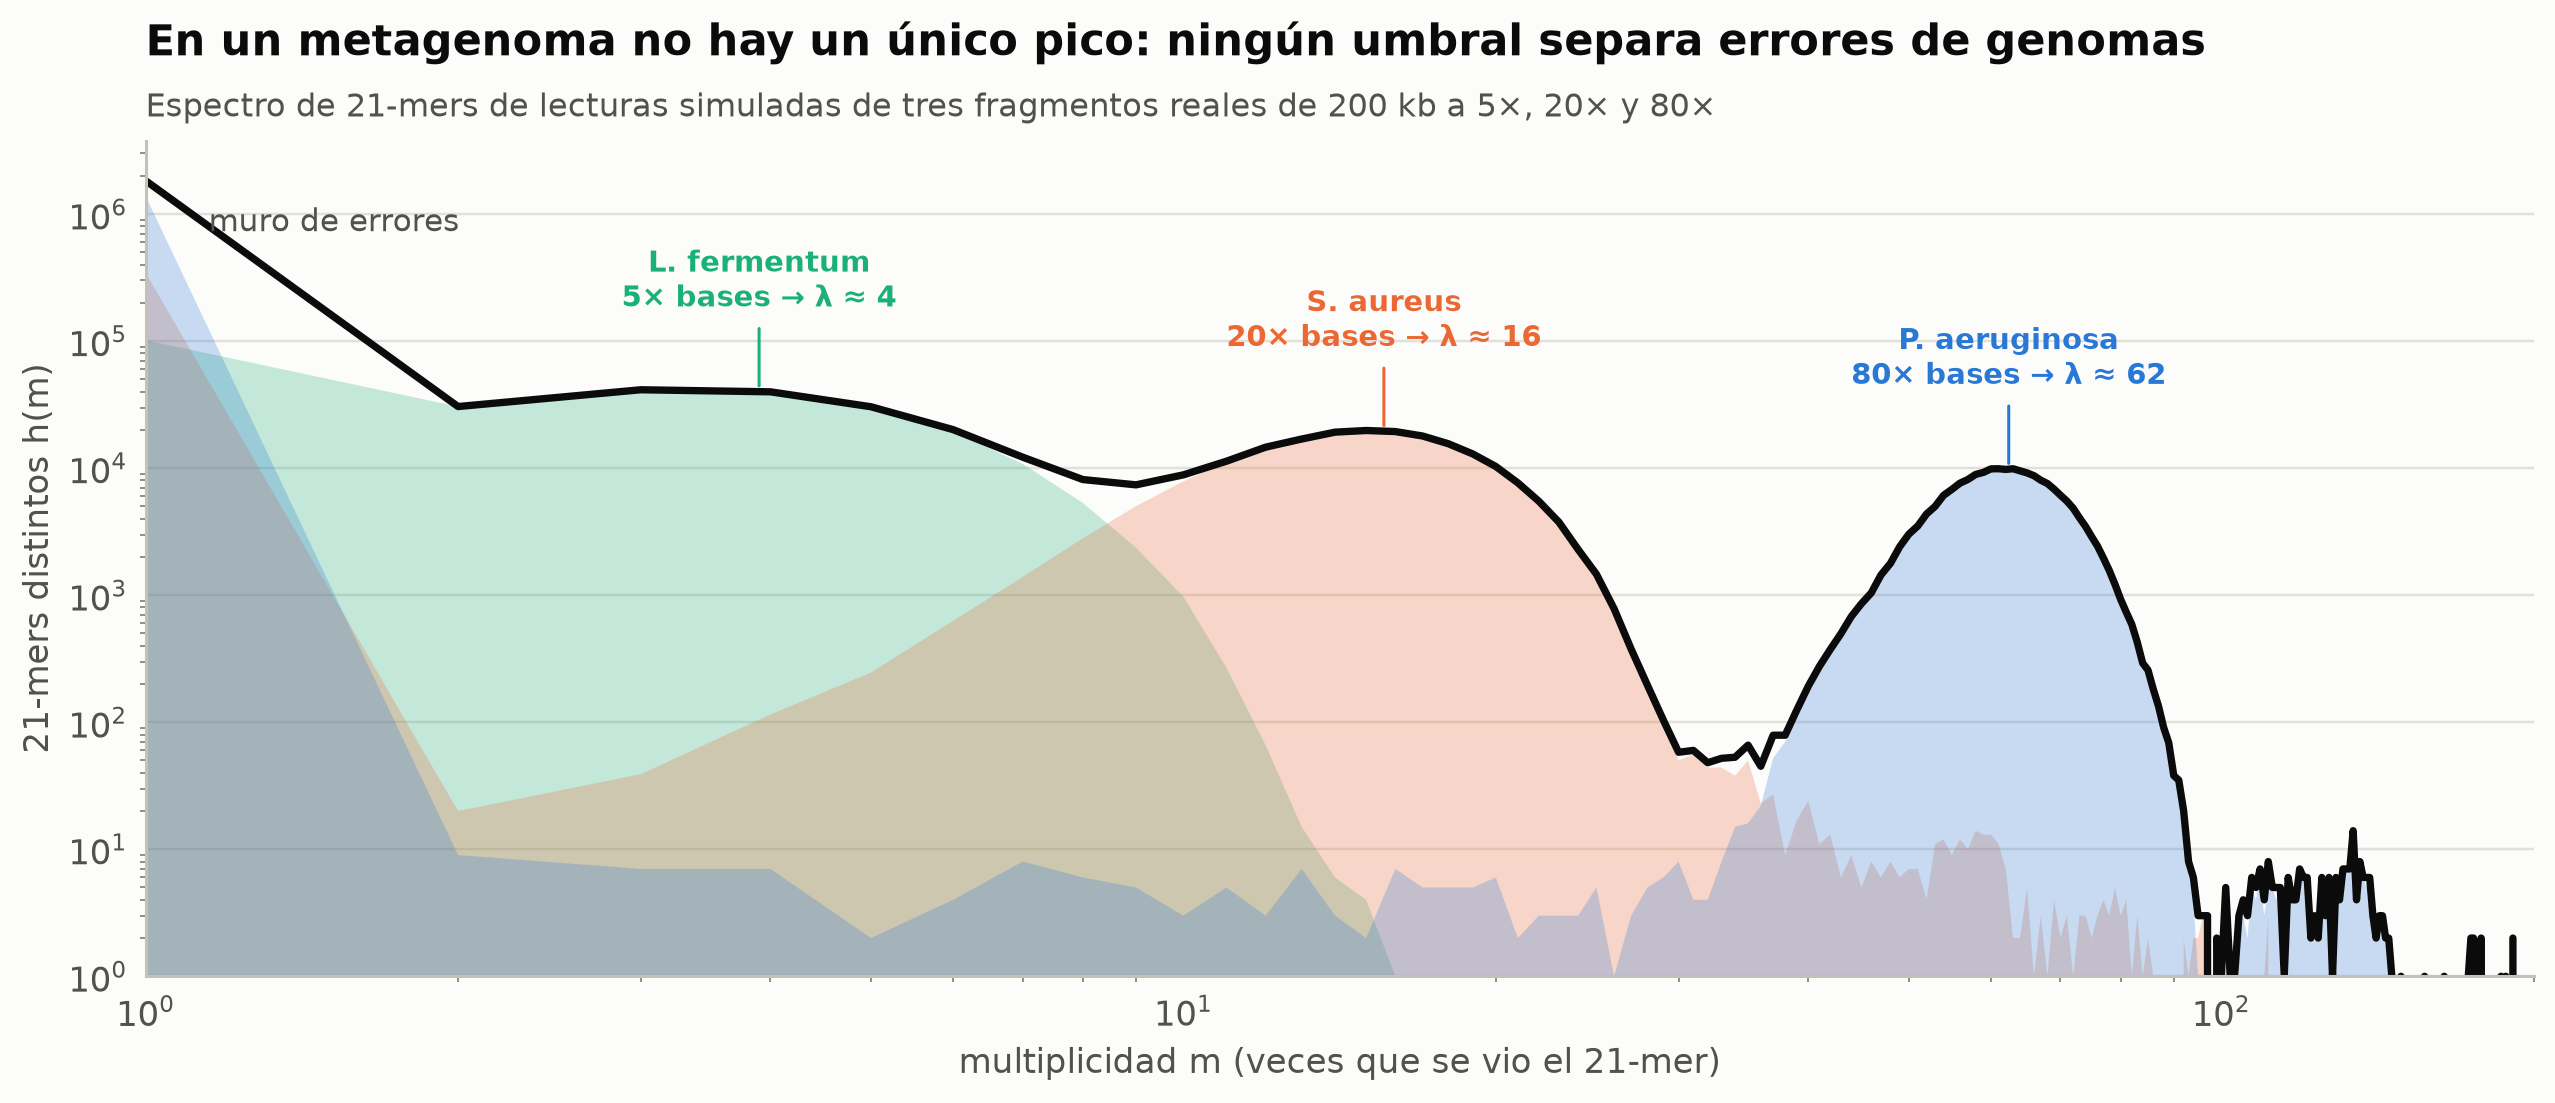

In [32]:
fig, ax = plt.subplots(figsize=(11.5, 4.9))
m = np.arange(len(mixed))
ax.plot(m[1:], mixed[1:], color=ec.INK, lw=2.4, label="metagenoma (suma)")
for (nm, cov), col in zip(mix, [ec.CATEGORICAL[2], ec.ORANGE, ec.BLUE]):
    s = spectra[nm]
    ax.fill_between(np.arange(1, len(s)), s[1:], color=col, alpha=0.25, lw=0)
    peak = 5 + np.argmax(s[5:]) if len(s) > 6 else 1
    lam = cov * (150 - 21 + 1) / 150 * (1 - 0.005) ** 21
    ax.annotate(f"{nm.split()[0][0]}. {nm.split()[1]}\n{cov}× bases → λ ≈ {lam:.0f}", (lam, s[int(round(lam))]),
                xytext=(0, 28), textcoords="offset points", ha="center", fontsize=9.5, color=col, fontweight="bold",
                arrowprops=dict(arrowstyle="-", color=col, lw=1))
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(1, 200); ax.set_ylim(1, None)
ax.set_xlabel("multiplicidad m (veces que se vio el 21-mer)"); ax.set_ylabel("21-mers distintos h(m)")
ax.text(1.15, mixed[1] * 0.4, "muro de errores", fontsize=10, color=ec.INK_2)
ec.title(ax, "En un metagenoma no hay un único pico: ningún umbral separa errores de genomas",
         "Espectro de 21-mers de lecturas simuladas de tres fragmentos reales de 200 kb a 5×, 20× y 80×")
plt.show()

> 🔎 **Qué observamos.** En un genoma aislado (Lección 8.1) el espectro tiene un **valle** claro entre los errores y el
> pico de copia única, y cortar en el valle limpia el grafo. Aquí el pico del organismo raro (λ ≈ 4) **se funde con el
> muro de errores**: cualquier umbral que elimine los errores elimina también a *L. fermentum*. Y el pico de *P.
> aeruginosa* está donde, en un aislado, esperaríamos **repeticiones** de copia 4 del organismo de 20×.

Los ensambladores metagenómicos responden a esto de dos maneras:

* **metaSPAdes** (Nurk *et al.*, 2017) adapta SPAdes: usa **umbrales de cobertura locales** en lugar de globales y,
  ante variantes de cepa, construye primero un **consenso** de la especie (colapsando las burbujas) y luego usa ese
  esqueleto para resolver repeticiones.
* **MEGAHIT** (Li *et al.*, 2015) prioriza la eficiencia: representa el grafo de de Bruijn en forma **sucinta** (una
  estructura de datos comprimida) y recorre iterativamente varios valores de $k$, de pequeños a grandes, lo que le
  permite ensamblar metagenomas de suelo con cientos de gigabases en un solo servidor.

Ninguno resuelve bien las cepas muy cercanas: en la evaluación CAMI, los ensambladores reconstruyeron bien los genomas
sin parientes cercanos en la muestra, pero su rendimiento cayó sustancialmente con cepas estrechamente emparentadas
(Sczyrba *et al.*, 2017).

```bash
megahit -1 m1_R1.fq.gz -2 m1_R2.fq.gz -o asm_m1 -t 16
bowtie2-build asm_m1/final.contigs.fa idx_m1
bowtie2 -x idx_m1 -1 m1_R1.fq.gz -2 m1_R2.fq.gz -p 16 \
  | samtools sort -o m1.bam
jgi_summarize_bam_contig_depths --outputDepth prof.txt m1.bam
metabat2 -i asm_m1/final.contigs.fa -a prof.txt -o bins/bin
checkm lineage_wf -x fa -t 16 bins/ checkm_out/
```

Las líneas 2–4 calculan la **cobertura de cada contig** mapeando las lecturas de vuelta: es la segunda señal del
*binning*, que vemos a continuación.

## 10. *Binning*: agrupar contigs en genomas

### 10.1 Dos señales que cada contig hereda de su genoma

El ensamblaje produce decenas de miles de contigs **sin etiqueta de origen**. El *binning* los agrupa en conjuntos
(*bins*) que idealmente corresponden cada uno a un genoma. Vuelva a la biblioteca triturada: tras pegar tiras en
páginas, agrupamos las páginas por el **tipo de letra** (algo que cada libro tiene de forma homogénea) y por el
**desgaste** del papel (las páginas de un mismo libro envejecieron juntas). Las dos señales del *binning* son:

1. **Composición.** Cada genoma tiene un contenido de GC y, más finamente, una **frecuencia de tetranucleótidos**
   (TNF) característicos y bastante estables a lo largo del genoma, por el sesgo de uso de codones y de la maquinaria
   de replicación y reparación.
2. **Cobertura.** Todos los contigs de un genoma tienen aproximadamente la **misma profundidad** y, si se secuencian
   varias muestras, su cobertura sube y baja de forma concertada; el perfil de coberturas en $M$ muestras es una firma
   muy discriminante.

**¿Por qué 136 tetranucleótidos?** Hay $4^4 = 256$ palabras de 4 letras. Como un contig puede venir de cualquiera de
las dos hebras, se une cada palabra con su reverso complementario. Las **palíndromas** (iguales a su reverso
complementario, como `ACGT` o `GATC`) son $4^2 = 16$, porque las dos primeras letras determinan las dos últimas; las
otras $256 - 16 = 240$ forman $120$ parejas. En total, $120 + 16 = 136$ frecuencias.

In [33]:
tetra = ["".join(p) for p in __import__("itertools").product("ACGT", repeat=4)]
rc4 = lambda s: s.translate(str.maketrans("ACGT", "TGCA"))[::-1]
canon4 = sorted({min(t, rc4(t)) for t in tetra})
pal = [t for t in tetra if t == rc4(t)]
print(f"256 tetranucleótidos · {len(pal)} palíndromos (p. ej. {', '.join(pal[:4])}…) · {len(canon4)} canónicos = (256 − 16)/2 + 16")
TET_IDX = np.array([canon4.index(min(t, rc4(t))) for t in tetra])   # código 0..255 → índice canónico 0..135

256 tetranucleótidos · 16 palíndromos (p. ej. AATT, ACGT, AGCT, ATAT…) · 136 canónicos = (256 − 16)/2 + 16


### 10.2 La simulación del libro: GC y cobertura

El libro ilustra el principio con **260 contigs simulados de cinco genomas** con GC de 33, 42, 51, 58 y 67 % y
coberturas de 8, 22, 60, 15 y 140×. La longitud de cada contig es log-normal (mediana 15 kb, entre 2,5 y 300 kb); su GC
se aleja del de su genoma con una desviación que **crece al acortarse el contig** (el GC de una secuencia corta es una
estimación ruidosa), y su cobertura sigue una gamma cuya dispersión también disminuye con la longitud. Reproducimos
exactamente la figura del libro restaurando el estado del generador aleatorio que usó (guardado en
`data/143_rng_libro.json`).

In [34]:
state = json.loads(course_bytes("143_rng_libro.json").decode())
rng_book = np.random.default_rng()
rng_book.bit_generator.state = state
book_genomes = [(0.33, 8), (0.42, 22), (0.51, 60), (0.58, 15), (0.67, 140)]     # (GC, cobertura) de cada genoma
rows = []
for gi, (gc, cov) in enumerate(book_genomes):
    ncont = rng_book.integers(35, 70)
    lens_c = np.clip(rng_book.lognormal(math.log(15000), 0.8, ncont), 2500, 300000)
    for Lc in lens_c:
        gcc = rng_book.normal(gc, 0.6 * math.sqrt(0.25 / Lc) * 20 + 0.004)            # GC: ruido ∝ 1/√L
        cc = rng_book.gamma(shape=cov * Lc / 20000 + 5, scale=1) * cov / (cov * Lc / 20000 + 5)
        rows.append((gi, 100 * gcc, cc, Lc / 1000))
bins_book = pd.DataFrame(rows, columns=["genome", "gc", "cov", "len_kb"])
print(f"contigs = {len(bins_book)} · por genoma = {bins_book.genome.value_counts().sort_index().tolist()}")
BOOK_COLS = [ec.BLUE, ec.ORANGE, ec.AQUA, ec.VIOLET, ec.MAGENTA]

contigs = 260 · por genoma = [49, 44, 59, 59, 49]


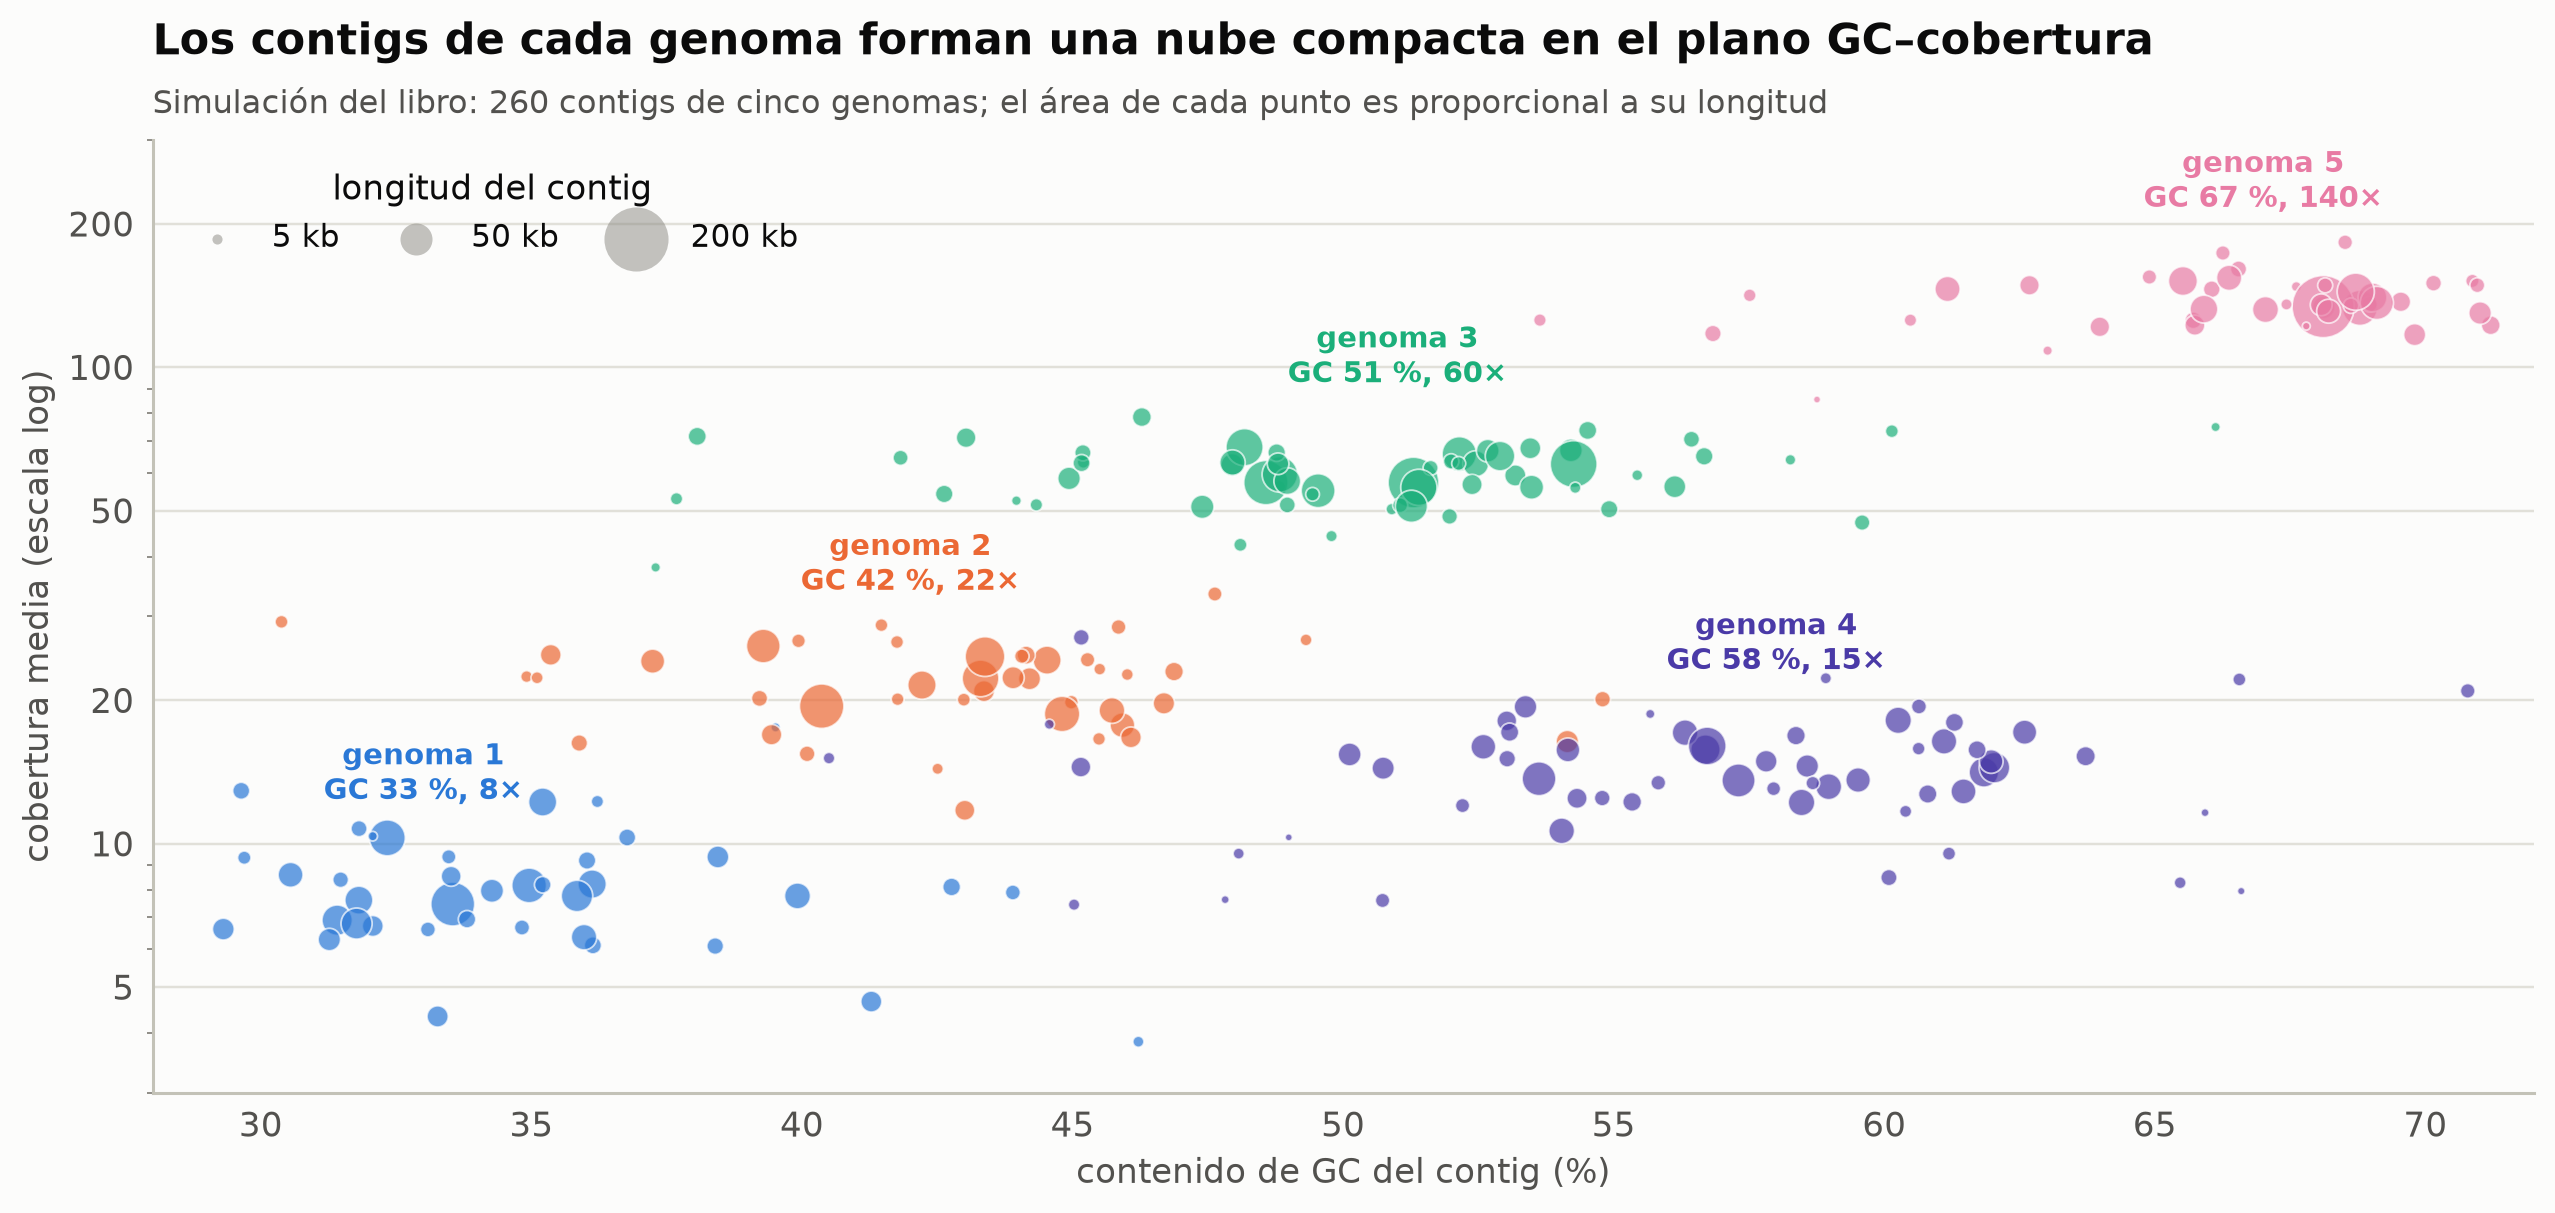

In [35]:
fig, ax = plt.subplots(figsize=(11.5, 5.4))
for gi, (gc, cov) in enumerate(book_genomes):
    d = bins_book[bins_book.genome == gi]
    ax.scatter(d.gc, d["cov"], s=d.len_kb * 2.2, color=BOOK_COLS[gi], alpha=0.7, ec="white", lw=0.6)
    ax.text(100 * gc, cov * 1.55, f"genoma {gi + 1}\nGC {100 * gc:.0f} %, {cov}×", ha="center", fontsize=9.5,
            color=BOOK_COLS[gi], fontweight="bold")
ax.set_yscale("log"); ax.set_xlim(28, 72); ax.set_ylim(3, 300)
ax.set_yticks([5, 10, 20, 50, 100, 200], ["5", "10", "20", "50", "100", "200"])
ax.set_xlabel("contenido de GC del contig (%)"); ax.set_ylabel("cobertura media (escala log)")
for s_, lab in [(5, "5 kb"), (50, "50 kb"), (200, "200 kb")]:
    ax.scatter([], [], s=s_ * 2.2, color=ec.MUTED, alpha=0.5, label=lab)
ax.legend(title="longitud del contig", loc="upper left", ncol=3, frameon=False, borderpad=0.6, columnspacing=1.5)
ec.title(ax, "Los contigs de cada genoma forman una nube compacta en el plano GC–cobertura",
         "Simulación del libro: 260 contigs de cinco genomas; el área de cada punto es proporcional a su longitud")
plt.show()

> 🔎 **Qué observamos.** Los contigs **cortos** (puntos pequeños) se dispersan más, porque su GC es una estimación
> ruidosa del de su genoma; por eso los *binners* descartan contigs por debajo de unos pocos kilobases. Los genomas 3 y
> 4 (aqua y violeta, GC 51 y 58 %) tienen composiciones cercanas y sus nubes se tocan en el eje horizontal: **sólo se
> separan gracias a la cobertura** (60× frente a 15×).

Explore la misma simulación en la versión interactiva: cada punto muestra su longitud, su GC y su cobertura, y cuánto
se aleja del GC de su genoma.

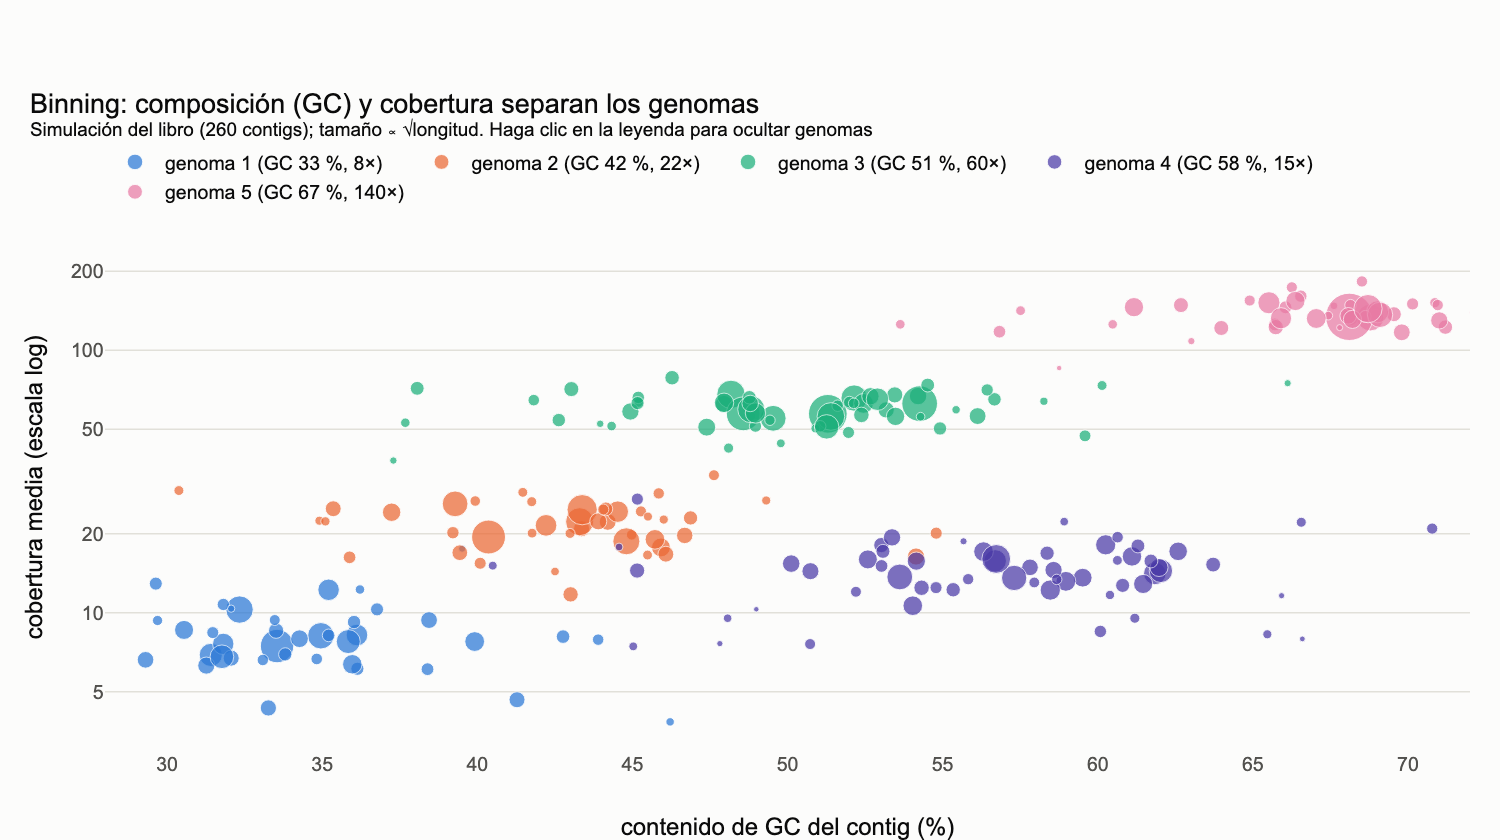

In [36]:
fig = go.Figure()
for gi, (gc, cov) in enumerate(book_genomes):
    d = bins_book[bins_book.genome == gi]
    fig.add_trace(go.Scatter(
        x=d.gc, y=d["cov"], mode="markers", name=f"genoma {gi + 1} (GC {100 * gc:.0f} %, {cov}×)",
        marker=dict(size=np.sqrt(d.len_kb) * 2.3, color=BOOK_COLS[gi], opacity=0.72, line=dict(color="white", width=0.6)),
        customdata=np.c_[d.len_kb, d.gc - 100 * gc, d["cov"] / cov],
        hovertemplate=("<b>genoma " + str(gi + 1) + "</b><br>longitud: %{customdata[0]:.1f} kb"
                       "<br>GC: %{x:.2f} % (%{customdata[1]:+.2f} puntos respecto a su genoma)"
                       "<br>cobertura: %{y:.1f}× (%{customdata[2]:.2f} veces la de su genoma)"
                       "<br><i>los contigs cortos se alejan más del centro de su nube</i><extra></extra>")))
fig.update_layout(
    title="Binning: composición (GC) y cobertura separan los genomas"
          "<br><sup>Simulación del libro (260 contigs); tamaño ∝ √longitud. Haga clic en la leyenda para ocultar genomas</sup>",
    xaxis=dict(title="contenido de GC del contig (%)", range=[28, 72]),
    yaxis=dict(title="cobertura media (escala log)", type="log", range=[math.log10(3), math.log10(300)],
               tickvals=[5, 10, 20, 50, 100, 200]),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), height=560, margin=dict(t=150, l=70, r=20, b=60))
fig.show()

### 10.3 Un *binner* mínimo: $k$-medias en el plano GC–cobertura

MetaBAT 2 (Kang *et al.*, 2019) combina ambas señales en una **distancia entre pares de contigs** (una probabilidad de
que dos contigs procedan de genomas distintos, calculada con la TNF y con la cobertura), construye un **grafo** con los
contigs como nodos y las afinidades como aristas y lo particiona con un algoritmo de **propagación de etiquetas**. Su
versión 2 adapta automáticamente los umbrales al conjunto de datos. El producto final son los **genomas ensamblados a
partir de metagenomas (MAGs)**.

Para ver la idea en movimiento usaremos el agrupamiento más simple posible, **$k$-medias**, sobre dos coordenadas
estandarizadas: GC y $\log_{10}$ de la cobertura (la cobertura se compara en escala logarítmica porque sus diferencias
son multiplicativas). Cada iteración alterna dos pasos: (1) asignar cada contig al centro más cercano; (2) mover cada
centro a la media (ponderada por longitud) de sus contigs.

In [37]:
Xb = np.c_[bins_book.gc, np.log10(bins_book["cov"])]
mu_b, sd_b = Xb.mean(0), Xb.std(0)
Zb = (Xb - mu_b) / sd_b
wb = bins_book.len_kb.values

def kmeans_history(Z, k, w, n_iter=12, seed=0):
    """k-medias ponderado; devuelve la lista de (centros, asignaciones) de cada paso."""
    r = np.random.default_rng(seed)
    C = Z[r.choice(len(Z), k, replace=False)]
    hist = []
    for _ in range(n_iter):
        lab = np.argmin(((Z[:, None, :] - C[None]) ** 2).sum(-1), axis=1)
        hist.append((C.copy(), lab.copy()))
        C = np.array([np.average(Z[lab == j], axis=0, weights=w[lab == j]) if np.any(lab == j) else C[j] for j in range(k)])
    hist.append((C.copy(), lab.copy()))
    return hist

hist_b = kmeans_history(Zb, 5, wb, seed=6)
final_lab = hist_b[-1][1]
ct = pd.crosstab(bins_book.genome + 1, final_lab, rownames=["genoma"], colnames=["bin"])
print(ct.to_string())
print(f"contigs en un bin donde su genoma es mayoría: {ct.values.max(0).sum() / ct.values.sum():.1%}")
short_bad = bins_book.len_kb[final_lab != pd.Series(final_lab).groupby(bins_book.genome).transform(lambda x: x.mode()[0]).values]
print(f"longitud mediana de los contigs mal agrupados: {short_bad.median():.1f} kb (todos: {bins_book.len_kb.median():.1f} kb)")

bin      0   1   2   3   4
genoma                    
1        0  48   0   1   0
2        2   1   0  41   0
3        0   0   2   2  55
4       54   1   0   4   0
5        0   0  46   0   3
contigs en un bin donde su genoma es mayoría: 93.8%
longitud mediana de los contigs mal agrupados: 6.6 kb (todos: 15.3 kb)


![k-medias sobre GC y log-cobertura: los cinco centros (cruces) parten de contigs al azar y en pocas iteraciones se instalan en las cinco nubes de la simulación del libro](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-14-metagenomica/14.3_kmedias_binning.gif)

*k-medias sobre GC y log-cobertura: los cinco centros (cruces) parten de contigs al azar y en pocas iteraciones se instalan en las cinco nubes de la simulación del libro*

In [38]:
fig, ax = plt.subplots(figsize=(10.5, 5.6))
frames_km = [(i, step) for i in range(len(hist_b)) for step in (0, 1)]
BIN_COLS = [ec.CATEGORICAL[i] for i in (7, 3, 5, 1, 6)]

def update(f):
    ax.clear()
    i, step = frames_km[min(f, len(frames_km) - 1)]
    C, lab = hist_b[i]
    if step == 1 and i + 1 < len(hist_b):
        C = hist_b[i + 1][0]                                        # paso 2: los centros se mueven
    Cx = C * sd_b + mu_b
    ax.scatter(bins_book.gc, bins_book["cov"], s=wb * 1.6, c=[BIN_COLS[l] for l in lab], alpha=0.65, ec="white", lw=0.5)
    ax.scatter(Cx[:, 0], 10 ** Cx[:, 1], marker="X", s=260, c=BIN_COLS, ec=ec.INK, lw=1.5, zorder=5)
    ax.set_yscale("log"); ax.set_xlim(28, 72); ax.set_ylim(3, 300)
    ax.set_yticks([5, 10, 20, 50, 100, 200], ["5", "10", "20", "50", "100", "200"])
    ax.set_xlabel("contenido de GC del contig (%)"); ax.set_ylabel("cobertura media (escala log)")
    what = "asignar cada contig al centro más cercano" if step == 0 else "mover cada centro a la media de sus contigs"
    head = f"k-medias, iteración {i + 1}: {what}" if i + 1 < len(hist_b) else "k-medias convergió: cinco bins, uno por nube"
    ec.title(ax, head,
             "Simulación del libro (260 contigs); color = bin actual, cruces = centros")
    return []

ec.animate(fig, update, frames=len(frames_km) + 4, interval=450, name="14.3_kmedias_binning")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Los centros empiezan donde caen los contigs elegidos al azar (aquí, dos de ellos en la misma
> nube y ninguno en otra) y en unas pocas iteraciones se reparten entre las cinco nubes. Alrededor del 94 % de los
> contigs acaba en el *bin* de su genoma; los que se equivocan son sobre todo **contigs cortos**, cuyo GC se aleja del
> de su genoma: la misma razón por la que los *binners* reales los descartan. $k$-medias necesita que le digamos **cuántos** genomas hay
> ($k = 5$), algo que en una muestra real no sabemos; MetaBAT 2 no lo necesita, porque la propagación de etiquetas en
> el grafo decide el número de *bins*.

### 10.4 Con genomas reales: la composición es una firma

La simulación del libro usa sólo el GC. Veamos si la **TNF real** distingue genomas reales. Cortamos los 10 genomas de
nuestra base en «contigs» con las mismas longitudes log-normales del libro (≥ 2,5 kb), calculamos para cada uno las 136
frecuencias de tetranucleótidos y el GC, y les asignamos una cobertura simulada con el mismo modelo gamma, como si
fueran una comunidad con abundancias desiguales (la cobertura de cada genoma se indica en la leyenda).

In [39]:
rng_c = np.random.default_rng(1435)
sim_cov = dict(zip(SPECIES, [40, 12, 25, 5, 70, 18, 9, 30, 3, 55]))     # cobertura simulada de cada genoma
contig_rows, tnf_rows = [], []
for sp in SPECIES:
    g = genomes[sp]
    codes4 = (g[:-3].astype(np.int64) * 64 + g[1:-2] * 16 + g[2:-1] * 4 + g[3:])      # tetranucleótido en cada posición
    valid = np.all(np.lib.stride_tricks.sliding_window_view(g, 4) < 4, axis=1)
    pos0 = 0
    while pos0 < len(g) - 2500:
        Lc = int(np.clip(rng_c.lognormal(math.log(15000), 0.8), 2500, 300000))
        Lc = min(Lc, len(g) - pos0)
        cod = codes4[pos0:pos0 + Lc - 3][valid[pos0:pos0 + Lc - 3]]
        tnf = np.bincount(TET_IDX[cod], minlength=136).astype(float)
        cov = sim_cov[sp]
        cc = rng_c.gamma(shape=cov * Lc / 20000 + 5, scale=1) * cov / (cov * Lc / 20000 + 5)
        contig_rows.append((sp, pos0, Lc, 100 * np.isin(g[pos0:pos0 + Lc], (1, 2)).mean(), cc))
        tnf_rows.append(tnf / tnf.sum())
        pos0 += Lc
contigs = pd.DataFrame(contig_rows, columns=["species", "start", "length", "gc", "cov"])
contigs["name"] = contigs.species.map(tax_name)
TNF = np.array(tnf_rows)
print(f"{len(contigs):,} contigs de {contigs.length.min() / 1e3:.1f}–{contigs.length.max() / 1e3:.0f} kb · TNF: {TNF.shape}")

# PCA de la TNF (centrada), con NumPy
TNF_c = TNF - TNF.mean(0)
U, S_, Vt = np.linalg.svd(TNF_c, full_matrices=False)
pcs = TNF_c @ Vt[:10].T
var_exp = S_ ** 2 / (S_ ** 2).sum()
print(f"varianza explicada por PC1, PC2: {var_exp[0]:.1%}, {var_exp[1]:.1%}")

1,861 contigs de 2.5–257 kb · TNF: (1861, 136)
varianza explicada por PC1, PC2: 80.3%, 4.9%


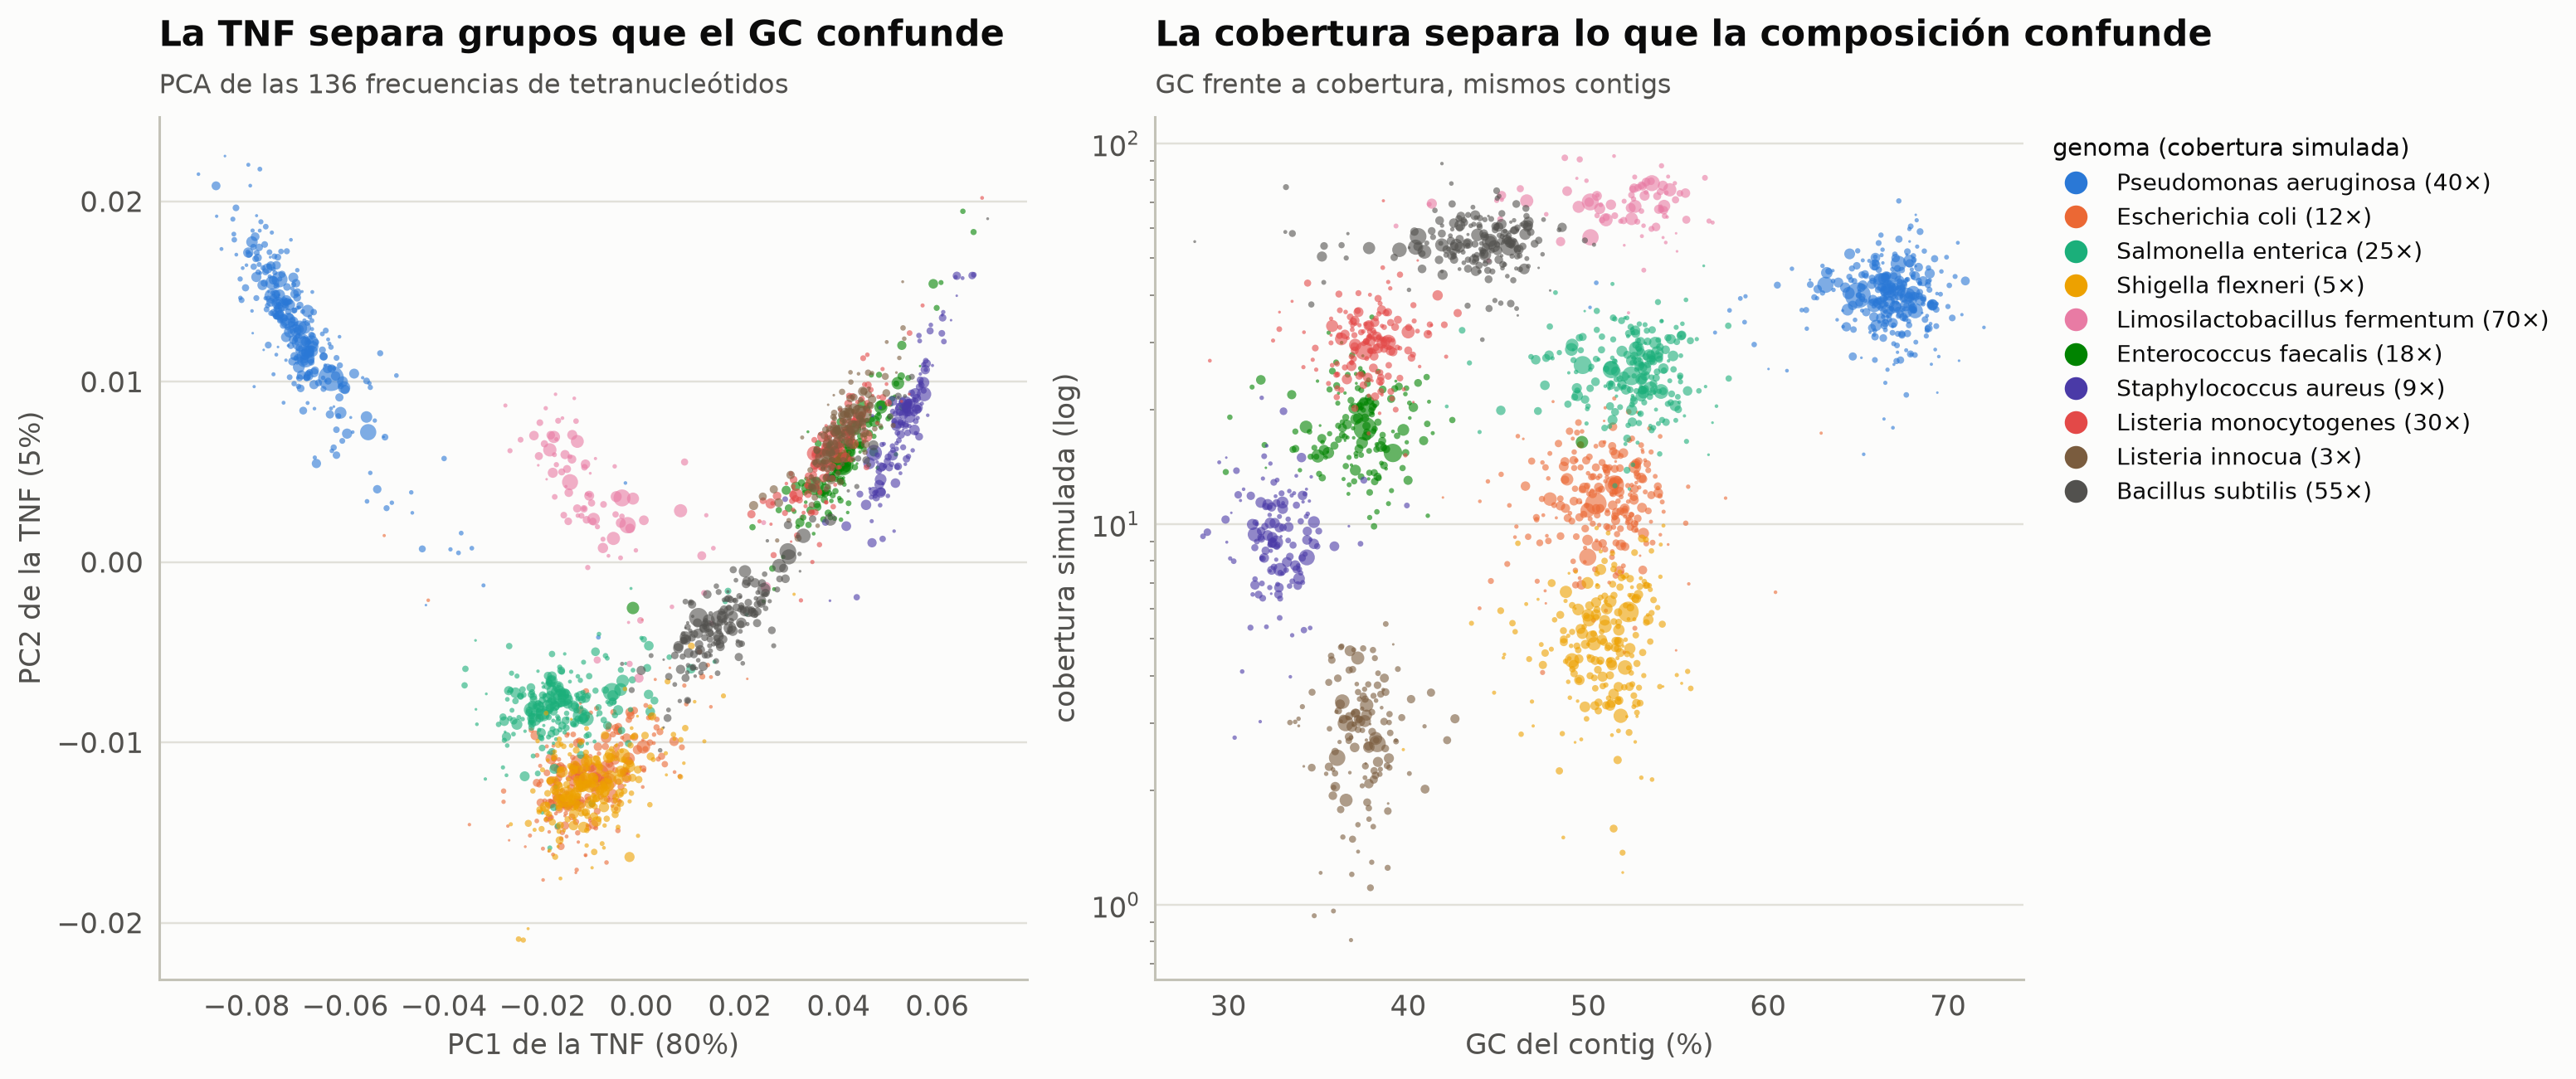

In [40]:
SP_COLS = dict(zip(SPECIES, ec.CATEGORICAL + ["#7a5c3e", ec.INK_2]))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.8))
for sp in SPECIES:
    d = contigs.species == sp
    ax1.scatter(pcs[d, 0], pcs[d, 1], s=contigs.length[d] / 2500, color=SP_COLS[sp], alpha=0.6, ec="none")
    ax2.scatter(contigs.gc[d], contigs["cov"][d], s=contigs.length[d] / 2500, color=SP_COLS[sp], alpha=0.6, ec="none",
                label=f"{tax_name[sp]} ({sim_cov[sp]}×)")

ax1.set_xlabel(f"PC1 de la TNF ({var_exp[0]:.0%})"); ax1.set_ylabel(f"PC2 de la TNF ({var_exp[1]:.0%})")
ec.title(ax1, "La TNF separa grupos que el GC confunde", "PCA de las 136 frecuencias de tetranucleótidos")
ax2.set_yscale("log"); ax2.set_xlabel("GC del contig (%)"); ax2.set_ylabel("cobertura simulada (log)")
ec.title(ax2, "La cobertura separa lo que la composición confunde", "GC frente a cobertura, mismos contigs")
from matplotlib.lines import Line2D
ax2.legend(handles=[Line2D([], [], marker="o", ls="", ms=8, color=SP_COLS[sp], label=f"{tax_name[sp]} ({sim_cov[sp]}×)")
                    for sp in SPECIES], fontsize=9, loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False,
           title="genoma (cobertura simulada)", title_fontsize=9.5, alignment="left")
plt.show()

> 🔎 **Qué observamos.** La PC1 de la TNF (80 % de la varianza) es, esencialmente, el GC. La PC2 añade información que
> el GC no tiene: *L. fermentum* tiene un GC parecido al de las enterobacterias (≈ 51 %) y, sin embargo, su TNF la
> separa claramente de ellas (rosa, arriba en el centro). Pero *E. coli* y *S. flexneri* se superponen por completo, y
> los Firmicutes de bajo GC (*Listeria*, *Enterococcus*, *Staphylococcus*) quedan muy próximos en este plano: la
> composición **no distingue especies hermanas** y le cuesta separar linajes de composición parecida. A la derecha, la cobertura sí separa a *L. monocytogenes* (30×) de *L. innocua* (3×) y a *E.
> coli* (12×) de *S. flexneri* (5×)… aunque sólo porque en esta comunidad simulada sus abundancias difieren.

Ahora agrupamos con $k$-medias ($k = 10$) de dos maneras: sólo con la composición (10 primeras PCs de la TNF) y con
composición + $\log$ cobertura. Medimos la calidad con el **índice de Rand ajustado** (ARI: 1 = agrupamiento perfecto,
0 = al azar).

In [41]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

truth = contigs.species.map({sp: i for i, sp in enumerate(SPECIES)}).values
Zc = (pcs - pcs.mean(0)) / pcs[:, 0].std()                        # misma escala para todas las PCs (la de PC1)
logc = np.log10(contigs["cov"].values)[:, None]
Zcov = (logc - logc.mean()) / logc.std()
feats = {"sólo composición (TNF)": Zc, "composición + cobertura": np.c_[Zc, 2 * Zcov]}
labels_km = {}
for nm, F in feats.items():
    km = KMeans(n_clusters=10, n_init=10, random_state=0).fit(F, sample_weight=contigs.length.values)
    labels_km[nm] = km.labels_
    print(f"{nm:28s} ARI = {adjusted_rand_score(truth, km.labels_):.3f}")
contigs["bin"] = labels_km["composición + cobertura"]

sólo composición (TNF)       ARI = 0.530


composición + cobertura      ARI = 0.836


> 🔎 **Qué observamos.** Con sólo la composición, los contigs de las especies hermanas caen en el mismo *bin* y el
> algoritmo, obligado a formar 10 grupos, parte en dos algún genoma grande. Al añadir la cobertura el ARI sube. En la
> práctica, la señal de cobertura más potente es el **perfil en varias muestras**: dos genomas pueden tener la misma
> cobertura en una muestra, pero es muy improbable que sus coberturas suban y bajen igual en 20 muestras.

## 11. ¿Es bueno un MAG? CheckM y MIMAG

### 11.1 Completitud y contaminación con genes de copia única

Un *bin* puede estar **incompleto** (le faltan contigs que quedaron en otro *bin* o no se ensamblaron) o
**contaminado** (contiene contigs de otro organismo). Sin un genoma de referencia, ¿cómo saberlo? Parks *et al.* (2015)
propusieron en CheckM usar **genes marcadores de copia única**: genes que, en los genomas completos de un linaje,
aparecen exactamente una vez. Es como revisar un mazo de cartas: si faltan 9 de las 52, el mazo está incompleto; si el
as de picas aparece dos veces, alguien mezcló cartas de otro mazo. En su forma más simple, con un conjunto
$\mathcal{M}$ de marcadores y $c_g$ copias del marcador $g$ en el *bin*,

$$
\text{completitud} = \frac{\#\{g\in\mathcal{M}: c_g \ge 1\}}{|\mathcal{M}|}, \qquad
\text{contaminación} = \frac{\sum_{g\in\mathcal{M}} \max(c_g - 1,\, 0)}{|\mathcal{M}|}
\qquad \text{(ecuación 14-checkm del libro)}
$$

| Símbolo | Significado |
|---|---|
| $\mathcal{M}$ | conjunto de genes marcadores de copia única del linaje al que pertenece el *bin* |
| $\lvert\mathcal{M}\rvert$ | número de marcadores |
| $c_g$ | número de copias del marcador $g$ encontradas en el *bin* |

CheckM refina esta idea de dos maneras: primero ubica el *bin* en un árbol de referencia para elegir marcadores
**específicos de su linaje** (más numerosos y fiables que los universales), y agrupa los marcadores que suelen estar
juntos en el cromosoma en **conjuntos colocalizados**, para no contar varias veces la ausencia de un mismo fragmento.

### 11.2 Las categorías MIMAG

Con estas medidas, Bowers *et al.* (2017) definieron el estándar **MIMAG**, que establece la información mínima que debe
acompañar a un MAG publicado y sus categorías de calidad:

| Borrador | Completitud | Contaminación | Requisitos adicionales |
|---|---|---|---|
| Alta calidad | $> 90\,\%$ | $< 5\,\%$ | ARNr 23S, 16S y 5S, y $\ge 18$ ARNt |
| Calidad media | $\ge 50\,\%$ | $< 10\,\%$ | — |
| Baja calidad | $< 50\,\%$ | $< 10\,\%$ | — |

### 11.3 Ejemplo del libro: «Clasificar un MAG»

Un *bin* contiene **95 de los 104** marcadores de copia única de su linaje, y **6** de ellos aparecen dos veces. Su
completitud es $95/104 = 91{,}3\,\%$ y su contaminación $6/104 = 5{,}8\,\%$. Aunque supera el 90 % de completitud, la
contaminación excede el 5 %: es un borrador de **calidad media**. Además, los genes de ARNr 16S rara vez se ensamblan
bien en metagenomas (las copias casi idénticas del operón colapsan en el grafo), de modo que muchos MAGs con completitud
y contaminación excelentes no alcanzan la categoría alta por ese requisito.

In [42]:
def checkm_simple(copies):
    """Completitud y contaminación (ecuación 14-checkm) a partir de las copias c_g de cada marcador."""
    copies = np.asarray(copies)
    return (copies >= 1).mean(), np.maximum(copies - 1, 0).sum() / len(copies)

def mimag(completeness, contamination, has_rrna_trna=False):
    """Categoría MIMAG de un borrador de MAG."""
    if contamination >= 0.10:
        return "no cumple (contaminación ≥ 10 %)"
    if completeness > 0.90 and contamination < 0.05:
        return "alta calidad" if has_rrna_trna else "calidad media (le faltan ARNr/ARNt para 'alta')"
    return "calidad media" if completeness >= 0.50 else "baja calidad"

copies_book = np.r_[np.full(89, 1), np.full(6, 2), np.full(9, 0)]      # 95 presentes (6 duplicados) de 104
comp_b, cont_b = checkm_simple(copies_book)
print(f"|M| = {len(copies_book)} · presentes = {(copies_book >= 1).sum()} · duplicados = {(copies_book == 2).sum()}")
print(f"completitud = {comp_b:.1%} · contaminación = {cont_b:.1%} → {mimag(comp_b, cont_b, has_rrna_trna=True)}")

|M| = 104 · presentes = 95 · duplicados = 6
completitud = 91.3% · contaminación = 5.8% → calidad media


### 11.4 Evaluar nuestros *bins*

Apliquemos la misma cuenta a los 10 *bins* de la sección 10.4. Como no anotamos genes, **simulamos** un conjunto de
$|\mathcal{M}| = 104$ marcadores de copia única: en cada genoma colocamos una copia de cada marcador en una posición al
azar. Un marcador está en un *bin* si el contig que lo contiene cayó en ese *bin*; $c_g$ cuenta de cuántos genomas
distintos proviene el marcador $g$ presente en el *bin*. Así, un *bin* que mezcla contigs de dos genomas acumula
marcadores duplicados, exactamente como en CheckM.

In [43]:
rng_m = np.random.default_rng(104)
N_MARK = 104
marker_rows = []
for sp in SPECIES:
    d = contigs[contigs.species == sp]
    ends = (d.start + d.length).values
    for g_idx, p in enumerate(rng_m.integers(0, len(genomes[sp]), N_MARK)):
        ci = d.index[np.searchsorted(ends, p, side="right")] if p < ends[-1] else None
        marker_rows.append((sp, g_idx, ci))
markers = pd.DataFrame(marker_rows, columns=["species", "marker", "contig"]).dropna()
markers["bin"] = contigs.loc[markers.contig.astype(int), "bin"].values

bin_rows = []
for b, d in contigs.groupby("bin"):
    m = markers[markers.bin == b]
    copies = np.zeros(N_MARK, int)
    for g_idx, n in m.groupby("marker").species.nunique().items():
        copies[g_idx] = n
    comp, cont = checkm_simple(copies)
    by_len = d.groupby("name").length.sum().sort_values(ascending=False)
    bin_rows.append({"bin": b, "especie dominante": by_len.index[0], "contigs": len(d),
                     "tamaño (Mb)": d.length.sum() / 1e6, "pureza": by_len.iloc[0] / by_len.sum(),
                     "completitud": comp, "contaminación": cont, "MIMAG": mimag(comp, cont)})
bins_eval = pd.DataFrame(bin_rows).sort_values("completitud", ascending=False)
print(bins_eval.round(3).to_string(index=False))

 bin             especie dominante  contigs  tamaño (Mb)  pureza  completitud  contaminación                                           MIMAG
   5              Listeria innocua      156        3.175   0.944        1.000          0.077                                   calidad media
   6             Bacillus subtilis      198        4.295   0.973        1.000          0.087                                   calidad media
   3        Pseudomonas aeruginosa      288        6.214   0.999        0.990          0.000 calidad media (le faltan ARNr/ARNt para 'alta')
   1           Salmonella enterica      229        4.846   0.970        0.981          0.019 calidad media (le faltan ARNr/ARNt para 'alta')
   4         Staphylococcus aureus      131        2.727   0.979        0.933          0.019 calidad media (le faltan ARNr/ARNt para 'alta')
   0        Listeria monocytogenes      170        3.067   0.895        0.923          0.096                                   calidad media
   7         

El plano completitud–contaminación es la forma estándar de presentar un conjunto de MAGs. Cada punto es un *bin*
(el tamaño es proporcional a su longitud total); las zonas sombreadas son las categorías MIMAG y la estrella es el MAG
del ejemplo del libro. Pase el cursor para ver la especie dominante, la pureza y la categoría.

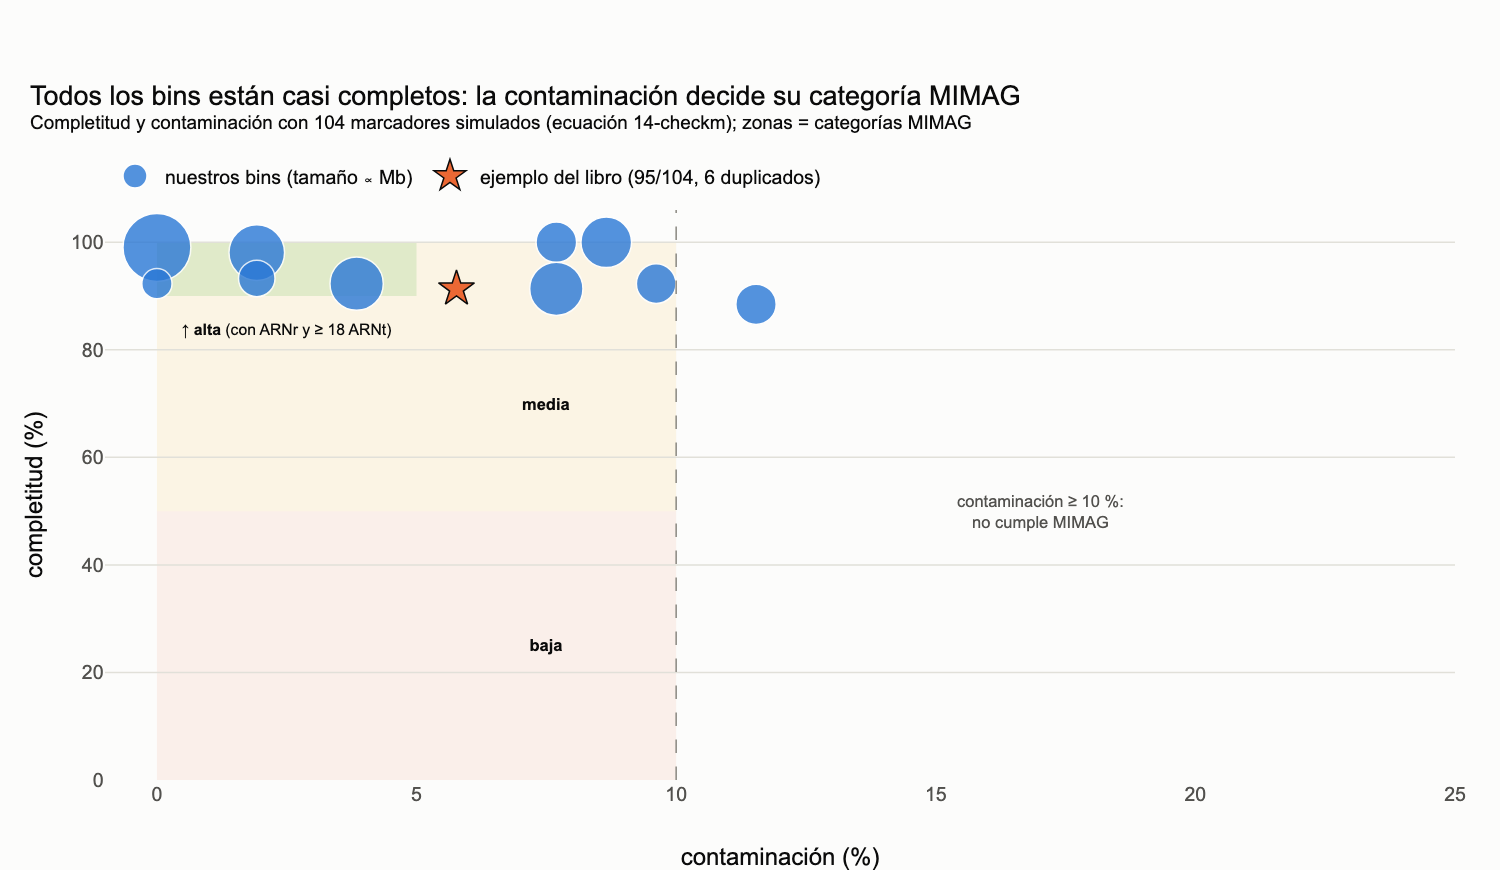

In [44]:
fig = go.Figure()
zones = [(0, 5, 90, 100, "rgba(12,163,12,0.12)", "alta (con ARNr y ARNt)"),
         (0, 10, 50, 100, "rgba(250,178,25,0.10)", "media"),
         (0, 10, 0, 50, "rgba(236,131,90,0.10)", "baja")]
for x0, x1, y0, y1, colr, lab in zones:
    fig.add_shape(type="rect", x0=x0, x1=x1, y0=y0, y1=y1, fillcolor=colr, line=dict(width=0), layer="below")
fig.add_annotation(x=2.5, y=84, text="↑ <b>alta</b> (con ARNr y ≥ 18 ARNt)", showarrow=False, font=dict(size=10.5))
fig.add_annotation(x=7.5, y=70, text="<b>media</b>", showarrow=False, font=dict(size=11))
fig.add_annotation(x=7.5, y=25, text="<b>baja</b>", showarrow=False, font=dict(size=11))
fig.add_annotation(x=17, y=50, text="contaminación ≥ 10 %:<br>no cumple MIMAG", showarrow=False,
                   font=dict(size=11, color=ec.INK_2))
fig.add_vline(x=10, line=dict(color=ec.MUTED, dash="dash", width=1))
be = bins_eval
fig.add_trace(go.Scatter(
    x=100 * be["contaminación"], y=100 * be.completitud, mode="markers", name="nuestros bins (tamaño ∝ Mb)",
    marker=dict(size=8 + 6 * be["tamaño (Mb)"], color=ec.BLUE, opacity=0.8, line=dict(color="white", width=1)),
    customdata=np.c_[be["especie dominante"], be.contigs, be["tamaño (Mb)"], 100 * be.pureza, be.MIMAG],
    hovertemplate=("<b>bin dominado por <i>%{customdata[0]}</i></b><br>%{customdata[1]} contigs, %{customdata[2]:.2f} Mb"
                   "<br>pureza (fracción de bases de la especie dominante): %{customdata[3]:.1f} %"
                   "<br>completitud = %{y:.1f} % · contaminación = %{x:.1f} %<br>MIMAG: %{customdata[4]}<extra></extra>")))
fig.add_trace(go.Scatter(
    x=[100 * cont_b], y=[100 * comp_b], mode="markers", name="ejemplo del libro (95/104, 6 duplicados)",
    marker=dict(symbol="star", size=18, color=ec.ORANGE, line=dict(color=ec.INK, width=1)),
    hovertemplate=("<b>ejemplo del libro</b><br>completitud 95/104 = %{y:.1f} %<br>contaminación 6/104 = %{x:.1f} %"
                   "<br>> 90 % pero contaminación > 5 % → calidad media<extra></extra>")))
fig.update_layout(
    title="Todos los bins están casi completos: la contaminación decide su categoría MIMAG"
          "<br><sup>Completitud y contaminación con 104 marcadores simulados (ecuación 14-checkm); zonas = categorías MIMAG</sup>",
    xaxis=dict(title="contaminación (%)", range=[-1, max(25, 100 * be["contaminación"].max() + 5)]),
    yaxis=dict(title="completitud (%)", range=[0, 106]),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), height=580, margin=dict(t=140, l=70, r=30, b=60))
fig.show()

> 🔎 **Qué observamos.** Todos los *bins* recuperan casi completo su genoma dominante (completitud ≥ 88 %), pero su
> contaminación varía mucho. Los *bins* más limpios son los de genomas de composición única (*P. aeruginosa*, *L.
> fermentum*). Los más contaminados son los de los Firmicutes de bajo GC (*Listeria*, *Enterococcus*, *Bacillus*), que
> se intercambian contigs porque su TNF es parecida y sus coberturas simuladas no son lo bastante distintas; el de
> *E. faecalis* supera el 10 % y no cumple MIMAG. *E. coli* y *S. flexneri* se separaron sólo gracias a la cobertura
> (12× frente a 5×): con coberturas iguales se fusionarían en un *bin* con cerca del 100 % de contaminación. Y ninguno
> alcanza «alta calidad» sin comprobar los ARNr y ARNt. Es la lección de CAMI: el *binning* funciona bien con genomas
> sin parientes cercanos y sufre con cepas o especies hermanas.

> ✅ **Compruebe su comprensión.** Un *bin* tiene completitud 100 % y contaminación 95 %. ¿Qué le dice eso?
> *(Que casi todos los marcadores aparecen dos veces: probablemente son **dos genomas completos** fusionados en un solo
> bin. La contaminación de CheckM puede superar el 100 %.)*

## 12. Más allá de «quién está»: perfilado funcional y resistoma

La gran ventaja del *shotgun* sobre el 16S es que secuencia **genes**. Además de «quién está», podemos preguntar **qué
puede hacer la comunidad**. La idea del perfilado funcional es la misma que la del taxonómico, cambiando el catálogo:
en lugar de genomas, una base de **familias de genes** (KEGG, UniRef, eggNOG), y en lugar de contar lecturas por
especie, contarlas por familia, **normalizando por longitud** (un gen el doble de largo recibe el doble de lecturas) y
por el número de **equivalentes genómicos** de la muestra (cuántas «células promedio» se secuenciaron):

$$
\text{copias por célula}_f = \frac{n_f / L_f}{\overline{n_{\text{UCS}} / L_{\text{UCS}}}}
$$

donde $n_f$ son las lecturas asignadas a la familia $f$, $L_f$ su longitud, y el denominador es la misma cantidad
promediada sobre genes universales de copia única (UCS), que hay exactamente una vez por célula (los mismos marcadores
de CheckM).

**Ejemplo con números.** En un metagenoma, los genes universales de copia única (≈ 1 kb) reciben en promedio 200
lecturas: $200/1 = 200$ lecturas por kb por célula. Un gen de β-lactamasa de 0,86 kb recibe 43 lecturas: $43/0{,}86 =
50$ lecturas por kb, es decir, $50/200 = 0{,}25$ **copias por célula**: una de cada cuatro células de la comunidad
porta el gen.

Una de las aplicaciones más relevantes es la vigilancia de la resistencia a antibióticos. Wright (2007) llamó
**resistoma** al conjunto de todos los genes que contribuyen a la resistencia a antibióticos en una comunidad, incluidos
los de bacterias no patógenas y los genes «precursores» que podrían evolucionar hacia la resistencia. Las bacterias
ambientales y comensales son un reservorio del que, por transferencia horizontal, los patógenos pueden adquirir
resistencias. Para inventariarlo, las lecturas o los contigs se comparan con bases curadas como **CARD**, que asocia
cada gen a su mecanismo, a la familia de antibióticos afectada y a modelos de detección con umbrales calibrados; su
herramienta RGI permite además predecir resistomas a partir de metagenomas (Alcock *et al.*, 2023).

In [45]:
genes = pd.DataFrame({"familia": ["UCS (media de genes de copia única)", "β-lactamasa (blaTEM)", "tetraciclina (tetM)",
                                  "vancomicina (vanA)"],
                      "longitud_kb": [1.0, 0.86, 1.92, 1.03], "lecturas": [200, 43, 96, 2]})
genes["lecturas/kb"] = genes.lecturas / genes.longitud_kb
genes["copias por célula"] = genes["lecturas/kb"] / genes.loc[0, "lecturas/kb"]
print(genes.round(3).to_string(index=False))

                            familia  longitud_kb  lecturas  lecturas/kb  copias por célula
UCS (media de genes de copia única)         1.00       200      200.000               1.00
               β-lactamasa (blaTEM)         0.86        43       50.000               0.25
                tetraciclina (tetM)         1.92        96       50.000               0.25
                 vancomicina (vanA)         1.03         2        1.942               0.01


> 🔎 **Qué observamos.** Normalizar por longitud y por equivalentes genómicos convierte conteos de lecturas en una
> cantidad biológica interpretable (copias por célula) y comparable entre muestras con distinta profundidad. Un gen como
> *vanA*, con 0,01 copias por célula, está en una de cada cien células: ¿presencia real o contaminación? Se aplican
> las mismas precauciones que a las especies raras de la sección 6.

> 🔬 **Profundización: CAMI, evaluar sin saber la verdad.** ¿Cómo saber qué herramienta funciona mejor si en una muestra
> real nunca conocemos la composición verdadera? La iniciativa CAMI (*Critical Assessment of Metagenome
> Interpretation*) construyó metagenomas sintéticos a partir de cientos de genomas recién secuenciados, que las
> herramientas no podían conocer, con abundancias y cepas controladas, y pidió a los desarrolladores que los analizaran
> a ciegas (Sczyrba *et al.*, 2017). Además de la dificultad de ensamblar cepas cercanas, el estudio mostró que el
> rendimiento de los clasificadores y perfiladores caía mucho en los rangos taxonómicos bajos para organismos sin
> parientes cercanos en las bases, y que la elección de parámetros cambiaba sustancialmente los resultados. Nuestra
> comunidad Zymo es la versión de laboratorio de la misma idea.

> 💡 **Idea clave.** El perfilado por referencia responde rápido «quién está», pero sólo entre lo ya conocido; el
> ensamblaje y el *binning* descubren lo desconocido, pero sólo entre lo abundante.

## 13. Ejercicios

**Ejercicio 1 — Profundidad para un organismo raro (ejercicio del libro).** Un metagenoma de heces tiene
$3\times10^7$ pares de lecturas de 150 pb, de las cuales el 40 % son humanas. ¿Qué abundancia relativa mínima debe tener
una bacteria de 3 Mb para alcanzar una cobertura de 10? Exprésela como fracción del ADN total y del ADN microbiano.

**Ejercicio 2 — La regla RTL y la confianza (ejercicio del libro).** Con `book_w`, `rtl_classify` y `confident_call`,
compruebe las puntuaciones RTL del árbol del libro y encuentre el umbral a partir del cual la lectura **deja de
asignarse al género** *Escherichia*. ¿Y a partir de cuál deja de asignarse a la familia?

**Ejercicio 3 — Bracken iterado.** En el ejemplo «Bracken en números», la previa $P(S_i)$ se estima con los conteos
sesgados. Itere: use las estimaciones $\hat n$ de una ronda como previa de la siguiente (normalizadas) y repita 50
veces. ¿A qué valores converge $\hat n$? ¿Por qué? *(Pista: es un algoritmo EM.)*

**Ejercicio 4 — Quitar un pariente de la base.** Reconstruya la tabla de LCA **sin** *L. innocua* (basta con borrar su
bit de cada máscara y recalcular `mask2lca`; los $k$-mers que sólo estaban en *L. innocua* desaparecen) y vuelva a
clasificar las lecturas. ¿A dónde van las ≈ 240 lecturas que antes eran *L. innocua*? ¿Qué implica esto para un
laboratorio que usa una base sin parientes no patógenos?

**Ejercicio 5 — Clasificar otro MAG.** Un *bin* contiene 70 de los 104 marcadores y 12 de ellos aparecen dos veces.
Calcule su completitud y contaminación y su categoría MIMAG. ¿Qué haría con él?

In [46]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
R_ex, ell_ex, G_ex, c_ex = 2 * 3e7, 150, 3e6, 10
alpha_total = c_ex * G_ex / (R_ex * ell_ex)                  # despejando α de c = Rℓα/G
print(f"α mínimo (fracción del ADN total) = {alpha_total:.4f} = {alpha_total:.2%}")
print(f"como fracción del ADN microbiano (60 % del total): {alpha_total / 0.6:.2%}")
print("Con 6×10^7 lecturas, una bacteria de 3 Mb necesita ≈ 0,33 % del ADN total (≈ 0,56 % del microbiano) para 10×.")

α mínimo (fracción del ADN total) = 0.0033 = 0.33%
como fracción del ADN microbiano (60 % del total): 0.56%
Con 6×10^7 lecturas, una bacteria de 3 Mb necesita ≈ 0,33 % del ADN total (≈ 0,56 % del microbiano) para 10×.


In [47]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
call_ex, sc_ex2 = rtl_classify(book_w, book_parent)
print("RTL:", sc_ex2, "→", call_ex)
g_conf = subtree_count("Escherichia", book_w, book_parent) / N_KMERS_BOOK
f_conf = subtree_count("Enterobacteriaceae", book_w, book_parent) / N_KMERS_BOOK
print(f"conf(género) = 56/116 = {g_conf:.4f}: con umbral > {g_conf:.4f} la lectura deja el género")
print(f"conf(familia) = 75/116 = {f_conf:.4f}: con umbral > {f_conf:.4f} deja la familia")
for thr in (g_conf - 1e-4, g_conf + 1e-4, f_conf + 1e-4):
    print(f"  umbral {thr:.4f} → {confident_call('E. coli', book_w, N_KMERS_BOOK, book_parent, thr)}")

RTL: {'E. coli': 67, 'E. albertii': 31, 'S. flexneri': 22, 'S. enterica': 17} → E. coli
conf(género) = 56/116 = 0.4828: con umbral > 0.4828 la lectura deja el género
conf(familia) = 75/116 = 0.6466: con umbral > 0.6466 deja la familia
  umbral 0.4827 → Escherichia
  umbral 0.4829 → Enterobacteriaceae
  umbral 0.6467 → Bacteria


In [48]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
prior = K_i / K_i.sum()
for it in range(50):
    post_it = P_G_S * prior / (P_G_S * prior).sum()
    n_it = K_i + n_G * post_it
    prior = n_it / n_it.sum()                                  # nueva previa = estimación actual
    if it in (0, 1, 4, 49):
        print(f"iteración {it + 1:2d}: n̂ = {n_it.round(0)}")
print("Converge a la verdad (6000, 3000, 1000): con la previa verdadera, la redistribución es exacta y ésta es un punto\n"
      "fijo del algoritmo (un EM para las proporciones de una mezcla). Bracken hace una sola ronda; el sesgo residual\n"
      "del ejemplo del libro es el precio de esa simplificación.")

iteración  1: n̂ = [5945. 3342.  712.]
iteración  2: n̂ = [6088. 3094.  818.]
iteración  5: n̂ = [6047. 3005.  948.]
iteración 50: n̂ = [6000. 3000. 1000.]
Converge a la verdad (6000, 3000, 1000): con la previa verdadera, la redistribución es exacta y ésta es un punto
fijo del algoritmo (un EM para las proporciones de una mezcla). Bracken hace una sola ronda; el sesgo residual
del ejemplo del libro es el precio de esa simplificación.


In [49]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
i_inn = SPECIES.index(innocua)
keep = [i for i in range(10) if i != i_inn]
new_mask = db_mask & np.uint16(~(1 << i_inn) & 0xFFFF)
m2l = {int(m): (lca_of([SPECIES[i] for i in keep if (int(m) >> i) & 1], tax_parent) if int(m) else -1)
       for m in np.unique(new_mask)}
uv, inv_ = np.unique(new_mask, return_inverse=True)
tax_noinn = np.array([m2l[int(m)] for m in uv])[inv_.ravel()]
def call_noinn(seq):
    codes = kmer_codes(encode(seq), K)
    idx = np.searchsorted(db_kmers, codes); idx[idx >= len(db_kmers)] = 0
    t = tax_noinn[idx[db_kmers[idx] == codes]]
    w = Counter(t[t > 0].tolist())
    return rtl_classify(w, tax_parent)[0] if w else None
moved = Counter(call_noinn(reads[i]) for i, c in enumerate(calls) if c == innocua)
print({(tax_name[t] if t else "sin clasificar"): v for t, v in moved.items()})
print(f"{moved[mono]} pasan a L. monocytogenes y {moved[None]} quedan sin clasificar (sus únicos 31-mers con coincidencia\n"
      "eran exclusivos de L. innocua). Sin el pariente en la base, la lectura va al pariente más cercano\n"
      "disponible. Aquí eso 'arregla' el falso positivo, pero en una muestra que SÍ tuviera L. innocua la base sin\n"
      "ella la reportaría como L. monocytogenes: un falso positivo del patógeno. Por eso las bases clínicas deben\n"
      "incluir los parientes no patógenos.")

{'sin clasificar': 97, 'Listeria monocytogenes': 145}
145 pasan a L. monocytogenes y 97 quedan sin clasificar (sus únicos 31-mers con coincidencia
eran exclusivos de L. innocua). Sin el pariente en la base, la lectura va al pariente más cercano
disponible. Aquí eso 'arregla' el falso positivo, pero en una muestra que SÍ tuviera L. innocua la base sin
ella la reportaría como L. monocytogenes: un falso positivo del patógeno. Por eso las bases clínicas deben
incluir los parientes no patógenos.


In [50]:
#@title 🔑 Solución — Ejercicio 5 { display-mode: "form" }
copies5 = np.r_[np.full(58, 1), np.full(12, 2), np.full(34, 0)]
c5, k5 = checkm_simple(copies5)
print(f"completitud = 70/104 = {c5:.1%} · contaminación = 12/104 = {k5:.1%} → {mimag(c5, k5)}")
print("Con > 10 % de contaminación no cumple MIMAG aunque su completitud sería 'media'. Conviene revisar sus contigs\n"
      "(¿coberturas o TNF discordantes?) y separar el genoma intruso antes de publicarlo.")

completitud = 70/104 = 67.3% · contaminación = 12/104 = 11.5% → no cumple (contaminación ≥ 10 %)
Con > 10 % de contaminación no cumple MIMAG aunque su completitud sería 'media'. Conviene revisar sus contigs
(¿coberturas o TNF discordantes?) y separar el genoma intruso antes de publicarlo.


## 📌 Resumen

* **Cobertura**: $c = R\ell\alpha/G$. Con $4\times10^7$ lecturas de 150 pb y un genoma de 4 Mb, el 1 % del ADN da 15×
  (casi todo cubierto) y el 0,1 % da 1,5× (22 % sin cubrir): detectar es mucho más barato que ensamblar.
* **$k$-mers exactos**: $\mathbb{E}[\text{espurias}] \approx B\cdot4^{-k}$ (93 para $k=15$, $2\times10^{-8}$ para $k=31$
  con $B = 10^{11}$); a cambio, un solo cambio destruye $k$ $k$-mers.
* **LCA y RTL**: cada $k$-mer lleva $\tau(\kappa) = \mathrm{LCA}$ de los genomas que lo contienen; la lectura va a la hoja
  de máxima $\mathrm{RTL}(h) = \sum_{t\in\mathrm{camino}(h)} w_t$ (67 frente a 31, 22 y 17 en el ejemplo del libro).
* **Kraken 2**: minimizadores ($\ell = 31$ dentro de $k = 35$) y tabla compacta; la confianza
  $\mathrm{conf}(t)$ sube la asignación por el árbol (0,34 especie, 0,48 género, 0,65 familia).
* **Caso real (Zymo, ERR2984773)**: nuestra mini-Kraken de 10 genomas RefSeq dejó ≈ 15 % sin clasificar (4 % de
  levaduras + ADN de cepa ausente de la base), asignó falsos positivos a *S. flexneri* (≈ 100) y *L. innocua* (≈ 240),
  y coincidió casi lectura a lectura con Kraken 2 real. Un umbral de confianza de 0,3 reduce esos falsos positivos a
  menos de la mitad (a una quinta parte en *L. innocua*) a costa de 17 puntos de sensibilidad a nivel de especie.
* **Bracken**: $P(S_i\mid G) \propto P(G\mid S_i)P(S_i)$, $\hat n_i = K_i + n_G P(S_i\mid G)$; en el ejemplo del libro,
  $(5945;\ 3342;\ 712)$ frente a $(6000;\ 3000;\ 1000)$. Con los datos reales, devuelve a *E. coli* sus lecturas de
  *Enterobacteriaceae* y acerca la composición a la esperada.
* **MetaPhlAn** estima fracciones de **células** con marcadores específicos de clado; Kraken + Bracken, de **ADN**.
* **Ensamblaje metagenómico**: sin un pico único de cobertura ni un umbral global; metaSPAdes (umbrales locales,
  consenso de cepas) y MEGAHIT (grafo sucinto, varios $k$).
* ***Binning***: composición (GC, 136 TNF) + cobertura; la TNF separa géneros, la cobertura (mejor en varias muestras)
  separa lo que la composición confunde.
* **CheckM y MIMAG**: completitud y contaminación con marcadores de copia única; 95/104 con 6 duplicados → 91,3 % y
  5,8 % → **calidad media**.
* **Perfil funcional y resistoma**: contar lecturas por familia de genes, normalizar por longitud y equivalentes
  genómicos; CARD/RGI para los genes de resistencia.

## 📚 Para profundizar

* Wood, D. E. & Salzberg, S. L. (2014). Kraken: ultrafast metagenomic sequence classification using exact alignments.
  *Genome Biology* 15: R46. doi:10.1186/gb-2014-15-3-r46
* Wood, D. E., Lu, J. & Langmead, B. (2019). Improved metagenomic analysis with Kraken 2. *Genome Biology* 20: 257.
  doi:10.1186/s13059-019-1891-0
* Lu, J., Breitwieser, F. P., Thielen, P. & Salzberg, S. L. (2017). Bracken: estimating species abundance in
  metagenomics data. *PeerJ Computer Science* 3: e104. doi:10.7717/peerj-cs.104
* Lu, J., Rincon, N., Wood, D. E., Breitwieser, F. P. *et al.* (2022). Metagenome analysis using the Kraken software
  suite. *Nature Protocols* 17(12): 2815–2839. doi:10.1038/s41596-022-00738-y
* Roberts, M., Hayes, W., Hunt, B. R., Mount, S. M. & Yorke, J. A. (2004). Reducing storage requirements for biological
  sequence comparison. *Bioinformatics* 20(18): 3363–3369. doi:10.1093/bioinformatics/bth408
* Blanco-Míguez, A. *et al.* (2023). Extending and improving metagenomic taxonomic profiling with uncharacterized
  species using MetaPhlAn 4. *Nature Biotechnology* 41(11): 1633–1644. doi:10.1038/s41587-023-01688-w
* Nurk, S., Meleshko, D., Korobeynikov, A. & Pevzner, P. A. (2017). metaSPAdes: a new versatile metagenomic assembler.
  *Genome Research* 27(5): 824–834. doi:10.1101/gr.213959.116
* Li, D., Liu, C.-M., Luo, R., Sadakane, K. & Lam, T.-W. (2015). MEGAHIT: an ultra-fast single-node solution for large
  and complex metagenomics assembly via succinct de Bruijn graph. *Bioinformatics* 31(10): 1674–1676.
  doi:10.1093/bioinformatics/btv033
* Kang, D. D. *et al.* (2019). MetaBAT 2: an adaptive binning algorithm for robust and efficient genome reconstruction
  from metagenome assemblies. *PeerJ* 7: e7359. doi:10.7717/peerj.7359
* Parks, D. H., Imelfort, M., Skennerton, C. T., Hugenholtz, P. & Tyson, G. W. (2015). CheckM: assessing the quality of
  microbial genomes recovered from isolates, single cells, and metagenomes. *Genome Research* 25(7): 1043–1055.
  doi:10.1101/gr.186072.114
* Bowers, R. M. *et al.* (2017). Minimum information about a single amplified genome (MISAG) and a
  metagenome-assembled genome (MIMAG) of bacteria and archaea. *Nature Biotechnology* 35(8): 725–731.
  doi:10.1038/nbt.3893
* Sczyrba, A. *et al.* (2017). Critical Assessment of Metagenome Interpretation — a benchmark of metagenomics software.
  *Nature Methods* 14(11): 1063–1071. doi:10.1038/nmeth.4458
* Wright, G. D. (2007). The antibiotic resistome: the nexus of chemical and genetic diversity. *Nature Reviews
  Microbiology* 5(3): 175–186. doi:10.1038/nrmicro1614
* Alcock, B. P. *et al.* (2023). CARD 2023: expanded curation, support for machine learning, and resistome prediction
  at the Comprehensive Antibiotic Resistance Database. *Nucleic Acids Research* 51(D1): D690–D699.
  doi:10.1093/nar/gkac920
* Nicholls, S. M., Quick, J. C., Tang, S. & Loman, N. J. (2019). Ultra-deep, long-read nanopore sequencing of mock
  microbial community standards. *GigaScience* 8(5): giz043. doi:10.1093/gigascience/giz043 (origen de las lecturas
  Illumina ERR2984773, BioProject PRJEB29504.)

---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)